# Learning Stable Control-oriented Deep Koopman Operators  


This tutorial demonstrates the use of [Deep Koopman Operators](https://www.nature.com/articles/s41467-018-07210-0) (DeepKO) with stability guarantees for system identificaiton of nonautonomous nonlinear dynamical systems in NeuroMANCER. 


## Koopman System Identification with Control Problem Setup

<img src="../figs/Koopman_model.png" width="500">  


System observables  $y_{k}$ and control inputs $u_k$ are encoded via encoder neural networks $f_y$ and $f_u$ to generate latent states $x_{k}$ (linear coordinates). This coordinate transformation now allos to apply linear Koopman operator $K$ to obtain latent states at the next time step $x_{k+1}$. After the rollout over given prediction horizon $N$ the generated latent trajectories $\{x_1, ..., x_N \}$ are proejcted back to the observable space via decoder neural network $f_y^{-1}$.
Now this Koopman encoder-decoder model can be trained as any other black-box nonlinear system identification problem with the loss $\mathcal{L}$ evaluated by comparing the  trajectory generated by the model with the training trajectory. 


### Koopman with Control References

[1] [H. Shi and M. Q. . -H. Meng, "Deep Koopman Operator With Control for Nonlinear Systems," in IEEE Robotics and Automation Letters, vol. 7, no. 3, pp. 7700-7707, July 2022, doi: 10.1109/LRA.2022.3184036.](https://ieeexplore.ieee.org/document/9799788)  
[2] [Eurika Kaiser and J Nathan Kutz and Steven L Brunton, Data-driven discovery of Koopman eigenfunctions for control, Mach. Learn.: Sci. Technol. 2021](https://iopscience.iop.org/article/10.1088/2632-2153/abf0f5)  
[3] [M. Korda and I. Mezić, "Optimal Construction of Koopman Eigenfunctions for Prediction and Control," in IEEE Transactions on Automatic Control, vol. 65, no. 12, pp. 5114-5129, Dec. 2020](https://ieeexplore.ieee.org/document/9022864)  
[4] [Yiqiang Han, Wenjian Hao, Umesh Vaidya, Deep Learning of Koopman Representation for Control, 2020
](https://arxiv.org/abs/2010.07546)  
[6] [Minghao Han, Jacob Euler-Rolle, Robert K. Katzschmann, DeSKO: Stability-Assured Robust Control with a Deep Stochastic Koopman Operator, ICLR 2022](https://openreview.net/forum?id=hniLRD_XCA)  
[6] https://github.com/HaojieSHI98/DeepKoopmanWithControl


### Generic Stable Layers References
[7]  [E. Skomski, S. Vasisht, C. Wight, A. Tuor, J. Drgoňa and D. Vrabie, "Constrained Block Nonlinear Neural Dynamical Models," 2021 American Control Conference (ACC), New Orleans, LA, USA, 2021, pp. 3993-4000](https://ieeexplore.ieee.org/document/9482930)   
[8] [J. Drgoňa, A. Tuor, S. Vasisht and D. Vrabie, "Dissipative Deep Neural Dynamical Systems," in IEEE Open Journal of Control Systems, 2022](https://ieeexplore.ieee.org/abstract/document/9809789)  
[9] [Jiong Zhang, Qi Lei, Inderjit S. Dhillon, Stabilizing Gradients for Deep Neural Networks via Efficient SVD Parameterization, InternationalConferenceonMachine Learning, 2018](https://arxiv.org/abs/1803.09327)



## NeuroMANCER and Dependencies

### Install (Colab only)
Skip this step when running locally.

In [376]:
import sys
print(sys.executable)

import neuromancer
print(neuromancer.__file__)

/Users/patrik/miniconda3/envs/kmpc/bin/python
/Users/patrik/miniconda3/envs/kmpc/lib/python3.11/site-packages/neuromancer/__init__.py


prostredie + neuromancer
c:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\koopman_py311\Scripts\python.exe

c:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\koopman_py311\Lib\site-packages\neuromancer\__init__.py

In [377]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle 
import scipy
import time as tim
import os
from scipy.io import loadmat

#from neuromancer.psl import plot
#from neuromancer import psl
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from neuromancer.system import Node, System
from neuromancer.slim import slim
from neuromancer.trainer import Trainer
from neuromancer.problem import Problem
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.modules import blocks
import joblib

from sklearn.preprocessing import StandardScaler, MinMaxScaler
torch.manual_seed(0)

## Generate trajectories from ODE system 

In this example we don't assume any prior knowledge on the system dynamics. We will only have access to limited measurements of the system states $x$ of an unknown [ordinary differential equations](https://en.wikipedia.org/wiki/Ordinary_differential_equation) (ODE).

Select the system_name from the available list of [nonautonomous ODE systems](https://github.com/pnnl/neuromancer/blob/master/src/neuromancer/psl/nonautonomous.py):
- TwoTank
- CSTR
- SwingEquation
- IverSimple

# Get and save data - (Already done)

## Create training data of sampled trajectories

We will obtain a dataset of sampled trajectories of the system dynamics in the form of input-state tuples: 
$$D = \big[(u^i_0, \hat{x}^i_0), ..., (u^i_N, \hat{x}^i_{N}) \big], \, \, i \in [1, ..., m]$$
where $N$ represents the prediction horizon, $m$ represents number of measured trajectories, and $i$ represents an index of the sampled trajectory.
Variables $x_k$ represent system states, and $u_k$ are exogenous inputs at time $k$.

In [378]:
%pwd
%ls

DK_pred_MPC.ipynb                     identification/
DeepKoopman_baseline.ipynb            nelin_model.ipynb
DeepKoopman_wC.ipynb                  results_strejc_to_zero.mat
arx_nonlin.ipynb                      steps/
cl_multiIC_using_control_functions.m  tbxmanager.m
closed loop experiments/              test_data.mat
closed loop simulations/              toolboxes/
data/                                 train_data.mat
figs/                                 trash/
functions/                            try.ipynb


In [379]:
import os
# os.chdir(r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026")
print(os.getcwd())

/Users/patrik/Documents/Skola/Pedagogika/Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu/code/LS2026


In [380]:
SEM2025_DIR = os.path

In [381]:
SEM2025_DIR

<module 'posixpath' (frozen)>

In [382]:
# import os

# # SEM2025_DIR = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026"

# os.chdir(SEM2025_DIR)
# print("SEM2025_DIR =", SEM2025_DIR)
# print("cwd =", os.getcwd())

In [383]:


# Load MATLAB data to match DeepKoopman_wC.ipynb
train_data = loadmat(os.path.join("data", "train_data.mat"))
test_data_mat = loadmat(os.path.join("data", "test_data.mat"))

In [384]:
# def get_data(train_sim, test_sim, nx, nu, nsteps, bs, scaler, scalerU):
#     dev_sim = train_sim

#     # Combine training and test data for reshaping
#     trainY = np.vstack((train_sim['Y'], test_sim['Y']))
#     trainU = np.vstack((train_sim['U'], test_sim['U']))

#     nsim = trainY.shape[0]
#     nbatch = nsim // nsteps
#     length = nbatch * nsteps

#     trainX = scaler.transform(trainY[:length]).reshape(nbatch, nsteps, nx)
#     trainU = scalerU.transform(trainU[:length]).reshape(nbatch, nsteps, nu)

#     train_dataset = DictDataset({
#         'Y': torch.tensor(trainX, dtype=torch.float32),
#         'Y0': torch.tensor(trainX[:, 0:1, :], dtype=torch.float32),
#         'U': torch.tensor(trainU, dtype=torch.float32)
#     }, name='train')

#     train_loader = DataLoader(train_dataset, batch_size=bs,
#                               collate_fn=train_dataset.collate_fn, shuffle=True)

#     # Dev set
#     nsim = dev_sim['Y'].shape[0]
#     nbatch = nsim // nsteps
#     length = nbatch * nsteps

#     devX = scaler.transform(dev_sim['Y'][:length]).reshape(nbatch, nsteps, nx)
#     devU = scalerU.transform(dev_sim['U'][:length]).reshape(nbatch, nsteps, nu)

#     dev_dataset = DictDataset({
#         'Y': torch.tensor(devX, dtype=torch.float32),
#         'Y0': torch.tensor(devX[:, 0:1, :], dtype=torch.float32),
#         'U': torch.tensor(devU, dtype=torch.float32)
#     }, name='dev')

#     dev_loader = DataLoader(dev_dataset, batch_size=bs,
#                             collate_fn=dev_dataset.collate_fn, shuffle=True)

#     # Test set (single trajectory)
#     nsim = test_sim['Y'].shape[0]
#     nbatch = nsim // nsteps
#     length = nbatch * nsteps

#     testX = scaler.transform(test_sim['Y'][:length]).reshape(1, nbatch * nsteps, nx)
#     testU = scalerU.transform(test_sim['U'][:length]).reshape(1, nbatch * nsteps, nu)

#     test_dataset = {
#         'Y': torch.tensor(testX, dtype=torch.float32),
#         'Y0': torch.tensor(testX[:, 0:1, :], dtype=torch.float32),
#         'U': torch.tensor(testU, dtype=torch.float32)
#     }

#     return train_loader, dev_loader, test_dataset

In [385]:
def get_data(train_sim, test_sim, nx, nu, nsteps, bs, scaler, scalerU):
    dev_sim = test_sim

    # TRAIN
    nsim = train_sim['Y'].shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    trainX = scaler.transform(train_sim['Y'][:length]).reshape(nbatch, nsteps, nx)
    trainU = scalerU.transform(train_sim['U'][:length]).reshape(nbatch, nsteps, nu)

    train_dataset = DictDataset({
        'Y': torch.tensor(trainX, dtype=torch.float32),
        'Y0': torch.tensor(trainX[:, 0:1, :], dtype=torch.float32),
        'U': torch.tensor(trainU, dtype=torch.float32)
    }, name='train')

    train_loader = DataLoader(
        train_dataset,
        batch_size=bs,
        collate_fn=train_dataset.collate_fn,
        shuffle=True
    )

    # DEV
    nsim = dev_sim['Y'].shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    devX = scaler.transform(dev_sim['Y'][:length]).reshape(nbatch, nsteps, nx)
    devU = scalerU.transform(dev_sim['U'][:length]).reshape(nbatch, nsteps, nu)

    dev_dataset = DictDataset({
        'Y': torch.tensor(devX, dtype=torch.float32),
        'Y0': torch.tensor(devX[:, 0:1, :], dtype=torch.float32),
        'U': torch.tensor(devU, dtype=torch.float32)
    }, name='dev')

    dev_loader = DataLoader(
        dev_dataset,
        batch_size=bs,
        collate_fn=dev_dataset.collate_fn,
        shuffle=False
    )

    # TEST
    nsim = test_sim['Y'].shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    testX = scaler.transform(test_sim['Y'][:length]).reshape(1, nbatch * nsteps, nx)
    testU = scalerU.transform(test_sim['U'][:length]).reshape(1, nbatch * nsteps, nu)

    test_dataset = {
        'Y': torch.tensor(testX, dtype=torch.float32),
        'Y0': torch.tensor(testX[:, 0:1, :], dtype=torch.float32),
        'U': torch.tensor(testU, dtype=torch.float32)
    }

    return train_loader, dev_loader, test_dataset

In [386]:
   # number of simulation steps in the dataset
nsteps = 80   # match DeepKoopman_wC.ipynb
bs = 100

# Match data combination used in DeepKoopman_wC.ipynb
Y_full = np.vstack((train_data['Ytrain'], test_data_mat['Ytest']))
U_full = np.vstack((train_data['Utrain'], test_data_mat['Utest']))

train_sim = {
    'Y': train_data['Ytrain'],
    'U': train_data['Utrain']
}

test_sim = {
    'Y': test_data_mat['Ytest'],
    'U': test_data_mat['Utest']
}
# train_sim = {
#     'Y': Y_full,
#     'U': U_full
# }

# test_sim = {
#     'Y': Y_full,
#     'U': U_full
# }

# Load existing scalers from sem2025/data
scaler = joblib.load(os.path.join('data', 'scaler.pkl'))
scalerU = joblib.load(os.path.join('data', 'scalerU.pkl'))

nx = train_sim['Y'].shape[1]
ny = train_sim['Y'].shape[1]
nu = train_sim['U'].shape[1]

train_loader, dev_loader, test_data = get_data(train_sim, test_sim, nx, nu, nsteps, bs, scaler, scalerU)

/Users/patrik/miniconda3/envs/kmpc/lib/python3.11/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Deep Koopman model in Neuromancer

Here we construct a discrete-time encoder-decoder Koopman model with control:   

<img src="../figs/Koopman_model.png" width="500">  


Encoder: $${x}_{k} = f_y(y_k) +f_u(u_k)$$ 
Koopman: $${x}_{k+1} = K(x_k)$$ 
Decoder: $$\hat{y}_{k+1} = f_y^{-1}(x_{k+1})$$  

**Encoder and Decoder networks** 

In [387]:
nx_koopman = 24
layers = [8,16,24]

In [388]:
# instantiate output encoder neural net f_y
f_y = blocks.MLP(
    ny,
    nx_koopman,
    bias=True,
    linear_map=torch.nn.Linear,
    nonlin=torch.nn.ReLU,
    hsizes=layers,
)
# initial condition encoder
encode_Y0 = Node(f_y, ['Y0'], ['x'], name='encoder_Y0')
# observed trajectory encoder
encode_Y = Node(f_y, ['Y'], ['x_latent'], name='encoder_Y')

In [389]:
# instantiate input encoder net f_u

f_u = torch.nn.Linear(nu, nx_koopman, bias=False)
# initial condition encoder
encode_U = Node(f_u, ['U'], ['u_latent'], name='encoder_U')

In [390]:
# instantiate state decoder neural net f_y_inv
f_y_inv = blocks.MLP(nx_koopman, ny, bias=True,
                linear_map=torch.nn.Linear,
                nonlin=torch.nn.ELU,
                hsizes=layers[::-1])
#f_y_inv = torch.nn.Linear(nx_koopman, ny, bias=False)
# predicted trajectory decoder
decode_y = Node(f_y_inv, ['x'], ['yhat'], name='decoder_y')

**Standard Koopman Operator** without stability guarantees is parametrized by linear layer of the latent size. 

**Stable Koopman Operator:**  For provably stable Koopman operator we can choose a range of linear algebra factorization that allow to constrain the eigenvalues of the resulting linear operator. 
In this example we use the following [Singular Value Decomposition (SVD)](https://en.wikipedia.org/wiki/Singular_value_decomposition) factorization of the operator given as:
$$K = U \Sigma V$$ 
$$\Sigma =  \text{diag}(\lambda_{\text{max}} - (\lambda_{\text{max}} - \lambda_{\text{min}}) \cdot \sigma(\Lambda)) $$
where $\sigma$ is logistic sigmoid activation function, $\cdot$ is a dot product, $\Lambda$ is a vector of eigenvalues of the linear operator, while $\lambda_{\text{max}}$ and $\lambda_{\text{min}}$ are constraints on maximum and minimum value of SVD factorized linear operator.

<img src="../figs/SVD_layer.png" width="300">  

In order for the SVD factorization to hold the left and right matrices $U$ and $V$, respectively, needs to be [orthogonal](https://en.wikipedia.org/wiki/Orthogonal_matrix).
This can be achieved either via [Householder reflectors](https://arxiv.org/abs/1803.09327), or via penalties in the loss function given as:  
$$\ell_{U} = || I - UU^T||_2 + || I - U^TU||_2  $$
$$\ell_{V} = || I - VV^T||_2 + || I - V^TV||_2  $$
$$\ell_{\text{stable}} = \ell_{U} + \ell_{V} $$

For more details on the SVD and other linear algebra factorizations of trainable linear layers see the references [[7]](https://ieeexplore.ieee.org/document/9482930) and [[8]](https://ieeexplore.ieee.org/abstract/document/9809789), with Pytorch implementations in the [slim submodule](https://github.com/pnnl/neuromancer/tree/master/src/neuromancer/slim) of the Neuromancer library. 

In [ ]:
# instantiate Koopman operator matrix
stable = False     # if True then provably stable Koopman operator
if stable:
    # SVD factorized Koopman operator with bounded eigenvalues: sigma_min <= \lambda_i <= sigma_max
    K = slim.linear.SVDLinear(nx_koopman, nx_koopman,
                          sigma_min=0.001, sigma_max=0.999, bias=False)
    # SVD penalty variable
    K_reg_error = variable(K.reg_error())
    # SVD penalty loss term
    K_reg_loss = 1.*(K_reg_error == 0.0)
    K_reg_loss.name = 'SVD_loss'
else:
    # linear Koopman operator without guaranteed stability
    K = torch.nn.Linear(nx_koopman, nx_koopman, bias=False)

In [392]:
class Koopman_control(nn.Module):
    """
    Baseline class for Koopman control model
    Implements discrete-time dynamical system:
        x_k+1 = K x_k + u_k
    with variables:
        x_k - latent states
        u_k - latent control inputs
    """

    def __init__(self, K):
        super().__init__()
        self.K = K

    def forward(self, x, u):
        """
        :param x: (torch.Tensor, shape=[batchsize, nx])
        :param u: (torch.Tensor, shape=[batchsize, nx])
        :return: (torch.Tensor, shape=[batchsize, nx])
        """
        x = self.K(x) + u
        return x

In [393]:
# symbolic Koopman model with control inputs
Koopman = Node(Koopman_control(K), ['x', 'u_latent'], ['x'], name='K')

# latent Koopmann rollout
dynamics_model = System([Koopman], name='Koopman', nsteps=nsteps)

In [394]:
# dynamics_model.show()

In [395]:
# put all nodes of the Koopman model together in a list of nodes
nodes = [encode_Y0, encode_Y, encode_U, dynamics_model, decode_y]

## Define Koopman system identification loss function terms

Here we define loss function terms to fit the encoded-decoder Koopman parameters $\theta$ from given time-series data.
The loss function terms follow the implementation as given in the reference [[2]](https://www.nature.com/articles/s41467-018-07210-0). 

**Output trajectory prediction loss:**  
$$\ell_y = \sum_{k=1}^{N} Q_y||y^i_{k+1} - \hat{y}^i_{k+1}||_2^2$$ 
**One step output prediction loss:**  
$$\ell_{y_1} = Q_{y_1}||y^i_2 - \hat{y}^i_2||_2^2$$ 

where $\hat{y}^i_{k+1} = \phi^{-1}_{\theta_3}(K^k_{\theta_2}(\phi_{\theta_1}(y^i_1))) $, 
and $N$ is defining length of the rollout (prediction) horizon.  

**Latent trajectory prediction loss:**  
$$\ell_{\text{lin}} = \sum_{k=1}^{N}  Q_x||\phi_{\theta_1}(y_{k+1}^i) - K^k\phi_{\theta_1}(y_1^i)||_2^2$$ 


In [396]:
# variables
Y = variable("Y")  # observed
yhat = variable('yhat')  # predicted output
x_latent = variable('x_latent')  # encoded output trajectory in the latent space
u_latent = variable('u_latent')  # encoded input trajectory in the latent space
x = variable('x')  # Koopman latent space trajectory

xu_latent = x_latent + u_latent  # latent state trajectory

# output trajectory tracking loss
y_loss = 10. * (yhat[:, 1:-1, :] == Y[:, 1:, :]) ^ 2
y_loss.name = "y_loss"

# one-step tracking loss
onestep_loss = 1.*(yhat[:, 1, :] == Y[:, 1, :])^2
onestep_loss.name = "onestep_loss"

# reconstruction loss
reconstruction_loss = 20.*(yhat[:, 0, :] == Y[:, 0, :])^2
reconstruction_loss.name = "reconstruction_loss"

# latent trajectory tracking loss
x_loss = 1. * (x[:, 1:-1, :] == xu_latent[:, 1:, :]) ^ 2
x_loss.name = "x_loss"

y_ss_val = torch.tensor([[[0.0]]], dtype=torch.float32)
u_ss_val = torch.tensor([[[0.0]]], dtype=torch.float32)

with torch.no_grad():
    pass

## Construct System ID learning problem

Given the training dataset $\hat{X} = [\hat{x}^i_0, ..., \hat{x}^i_{N}]$ we want to solve the following problem:
 
$$
\begin{align}
&\underset{\theta}{\text{minimize}}     && \sum_{i=1}^m \Big( \ell_{y} + \ell_{y_1}  +\ell_{\text{lin}} + \ell_{\text{recon}} + \ell_{\text{stable}} \Big) \\
&\text{subject to}    && \hat{y}^i_{k+1} = \phi^{-1}_{\theta_3}(K^k_{\theta_2}(\phi_{\theta_1}(y_1^i))) \\
\end{align}
$$  

In [397]:
# aggregate list of objective terms and constraints
objectives = [y_loss, x_loss, onestep_loss, reconstruction_loss]

if stable:
    objectives.append(K_reg_loss)

# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints=[])

# construct constrained optimization problem
problem = Problem(nodes, loss)

In [398]:
# plot computational graph
#problem.show()
print(problem.input_keys)
print(problem.output_keys)

['u_latent', 'x', 'yhat', 'U', 'Y', 'Y0', 'x_latent']
['loss', 'yhat', 'u_latent', 'x', 'C_ineq_violations', 'C_values', 'C_ineq_values', 'penalty_loss', 'C_eq_violations', 'C_eq_values', 'x_latent', 'C_violations', 'objective_loss']


In [399]:
problem(next(iter(train_loader)))

{'train_Y': tensor([[[-0.0796],
          [-0.0796],
          [-0.0178],
          ...,
          [ 0.2088],
          [ 0.2706],
          [ 0.2706]],
 
         [[ 0.7031],
          [ 0.6825],
          [ 0.6619],
          ...,
          [ 0.5795],
          [ 0.5589],
          [ 0.5383]],
 
         [[ 0.3118],
          [ 0.3118],
          [ 0.3735],
          ...,
          [ 1.2180],
          [ 1.2386],
          [ 1.2386]],
 
         ...,
 
         [[-0.3885],
          [-0.4709],
          [-0.4503],
          ...,
          [-0.3679],
          [-0.3885],
          [-0.3885]],
 
         [[ 0.3735],
          [ 0.2912],
          [ 0.3118],
          ...,
          [ 0.6619],
          [ 0.6825],
          [ 0.6825]],
 
         [[-1.6242],
          [-1.6242],
          [-1.6242],
          ...,
          [-0.7386],
          [-0.7386],
          [-0.7386]]]),
 'train_Y0': tensor([[[-0.0796]],
 
         [[ 0.7031]],
 
         [[ 0.3118]],
 
         [[ 1.2592]],
 
 

## Solve the problem

We fit the unknown NODE parameters $\theta$ using stochastic gradient descent.

In [400]:
optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)

trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    test_data,
    optimizer,
    patience=300,
    warmup=100,
    epochs=500,
    eval_metric="dev_loss",
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="dev_loss",
)


In [401]:
# %% train
start = tim.time()
best_model = trainer.train()
problem.load_state_dict(best_model)
end = tim.time()


epoch: 0  train_loss: 27.15561294555664
epoch: 1  train_loss: 26.865947723388672
epoch: 2  train_loss: 26.577434539794922
epoch: 3  train_loss: 26.29057502746582
epoch: 4  train_loss: 26.005273818969727
epoch: 5  train_loss: 25.721590042114258
epoch: 6  train_loss: 25.437227249145508
epoch: 7  train_loss: 25.150676727294922
epoch: 8  train_loss: 24.860923767089844
epoch: 9  train_loss: 24.567270278930664
epoch: 10  train_loss: 24.2692813873291
epoch: 11  train_loss: 23.966392517089844
epoch: 12  train_loss: 23.657663345336914
epoch: 13  train_loss: 23.342674255371094
epoch: 14  train_loss: 23.021766662597656
epoch: 15  train_loss: 22.69497299194336
epoch: 16  train_loss: 22.362340927124023
epoch: 17  train_loss: 22.024187088012695
epoch: 18  train_loss: 21.681474685668945
epoch: 19  train_loss: 21.334903717041016
epoch: 20  train_loss: 20.985755920410156
epoch: 21  train_loss: 20.636083602905273
epoch: 22  train_loss: 20.288169860839844
epoch: 23  train_loss: 19.94508934020996
epoch: 2

In [402]:
import os
import datetime
import torch

timestamp_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# save_dir = r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026\data"
os.makedirs("data", exist_ok=True)

save_path = os.path.join("data", "baseline.pth")
torch.save(best_model, save_path)

print("Saved to:", save_path)

Saved to: data/baseline.pth


In [403]:
# 1) current in-memory model already used for Pred
test_outputs_mem = problem.step(test_data)
pred_mem = test_outputs_mem['yhat'][:, 1:-1, :].detach().numpy()

# 2) load the saved file into a fresh model
problem_fresh = Problem(nodes, loss)
problem_fresh.load_state_dict(torch.load(save_path, map_location="cpu"), strict=False)

test_outputs_file = problem_fresh.step(test_data)
pred_file = test_outputs_file['yhat'][:, 1:-1, :].detach().numpy()

print("max abs diff:", np.max(np.abs(pred_mem - pred_file)))

max abs diff: 0.0


In [404]:
save_path

'data/baseline.pth'

In [405]:
#torch.save(best_model, "./data/model_baseline.pth")

In [406]:
# load problem
#problem.load_state_dict(torch.load('data/model_20241028_105952.pth'),strict=False)

In [407]:
# after training
problem.load_state_dict(best_model)

if stable:
    A = K.effective_W().detach().cpu().numpy()
else:
    A = K.weight.detach().cpu().numpy()

B = f_u.weight.detach().cpu().numpy()

def get_x(y_scaled):
    x = problem.nodes[0]({"Y0": torch.from_numpy(y_scaled).float()})
    return x["x"].detach().numpy().reshape(-1, 1)

def get_y(x_latent):
    y = problem.nodes[4]({"x": torch.from_numpy(x_latent.T).float()})
    return y["yhat"][0].detach().numpy().reshape(-1, 1)

In [408]:
# elapsed time
print(f"Elapsed time train: {end-start:.2f} sec")


Elapsed time train: 17.36 sec


## System Identification results

In [409]:
problem.nodes

ModuleList(
  (0): encoder_Y0(Y0) -> x
  (1): encoder_Y(Y) -> x_latent
  (2): encoder_U(U) -> u_latent
  (3): System(
    (nodes): ModuleList(
      (0): K(x, u_latent) -> x
    )
  )
  (4): decoder_y(x) -> yhat
)

In [410]:
# update the rollout length based on the test data
problem.nodes[3].nsteps = 800

In [411]:
# Test set results
start = tim.time()
test_outputs = problem.step(test_data)
end = tim.time()
print(f"Elapsed time test: {end-start:.2f} sec")

pred_traj = test_outputs['yhat'][:, 1:-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['Y'][:, 1:pred_traj.shape[1]+1, ].detach().numpy().reshape(-1, nx).T
input_traj = test_data['U'].detach().numpy().reshape(-1, nu).T
pred_x = test_outputs['x'][:, 1:-1, :].detach().numpy().reshape(-1, nx_koopman).T

Elapsed time test: 0.08 sec


In [412]:
pred_x.shape

(24, 799)

In [413]:
test_data['Y'][:, 1:pred_traj.shape[1]+1, ].shape

torch.Size([1, 799, 1])

In [414]:
np.mean((pred_traj - true_traj) ** 2)
#2*60; 40 0.06774564
#3*60 80 0.05942205
# 16 32 64 40 0.06478106
# 16 32 64 64 0.06103883
# 16 32 64 128 0.07568752
# 32 64 128 128 0.061701212

# 0.00673042


np.float32(0.056982055)

In [415]:
from scipy.signal import cont2discrete

# Given parameters
gain = 1.1237    # Example gain
tau = 68  # Example time constant
T = 1    # Sampling time (choose based on your application)

# Continuous-time state-space matrices
A = np.array([[-1/tau]])
B = np.array([[gain/tau]])
C = np.array([[1]])
D = np.array([[0]])

# Discretize using cont2discrete
system = (A, B, C, D)
discrete_system = cont2discrete(system, T, method='zoh')

# Extract discrete-time matrices
A_d, B_d, C_d, D_d, _ = discrete_system

print("Discrete A matrix:", A_d)
print("Discrete B matrix:", B_d)
print("Discrete C matrix:", C_d)
print("Discrete D matrix:", D_d)


Discrete A matrix: [[0.98540172]]
Discrete B matrix: [[0.01640409]]
Discrete C matrix: [[1]]
Discrete D matrix: [[0]]


In [416]:
input_traj[:,30]

array([-0.12874652], dtype=float32)

In [417]:
x0 = test_data['Y0'][0].detach().numpy()
input_traj = test_data['U'].detach().numpy()
y_strejc = np.zeros((nx, 900))
y_strejc[:, 0] = x0
for i in range(899):
    y_strejc[:,i+1] = A_d @ y_strejc[:,i] + B_d @ input_traj[:,i]

In [418]:
x_enc = problem.nodes[0]({"Y0": test_data['Y'][:, 1:pred_traj.shape[1]+1, ]})#({"Y0": torch.from_numpy(pred_traj.reshape(1,-1,1)).float()})
y_endec = problem.nodes[4](x_enc)
y_ed = y_endec['yhat'][0].detach().numpy()

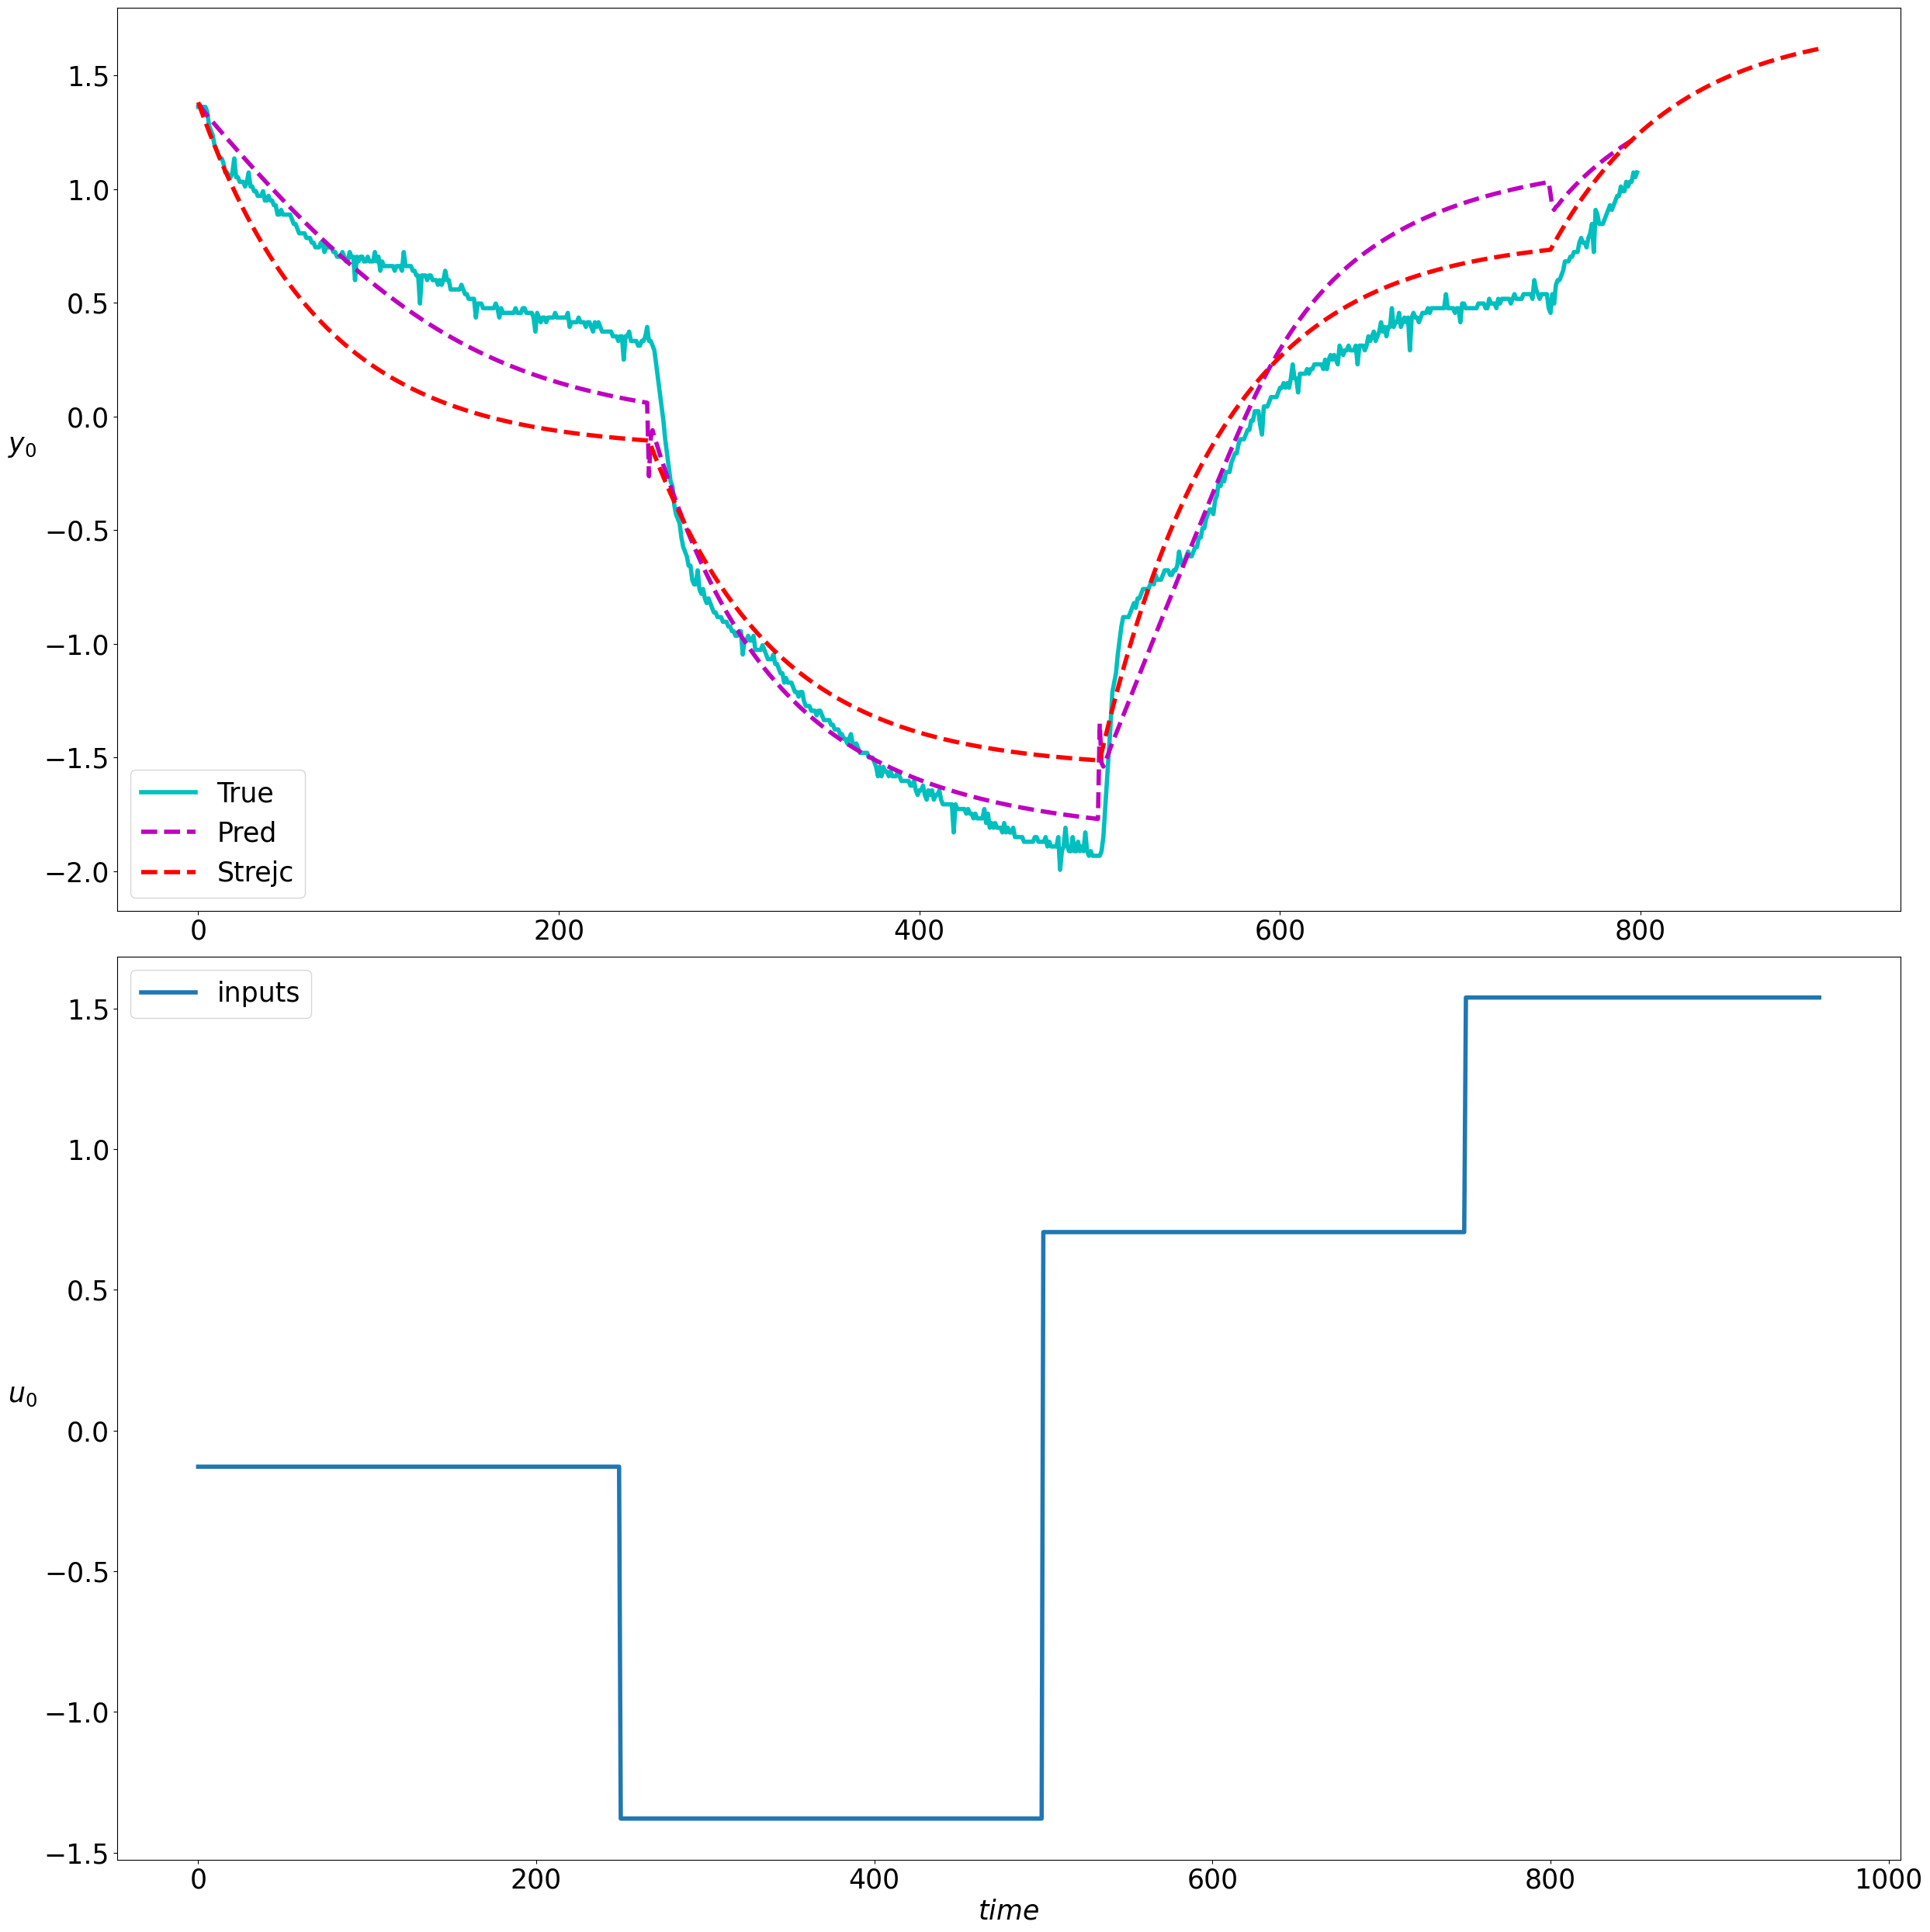

In [419]:
# plot trajectories
figsize = 25
fig, ax = plt.subplots(nx + nu, figsize=(figsize, figsize))
part = 3600

x_labels = [f'$y_{k}$' for k in range(len(true_traj))]
for row, (t1, t2, t3, t4, label) in enumerate(zip(true_traj, pred_traj, y_strejc, y_ed.T, x_labels)):
    axe = ax[row]
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1[:part], 'c', linewidth=4.0, label='True')
    axe.plot(t2[:part], 'm--', linewidth=4.0, label='Pred')
    axe.plot(t3[:part], 'r--', linewidth=4.0, label='Strejc')
    #axe.plot(t4[:part], 'r-', linewidth=4.0, label='endec')
    axe.tick_params(labelbottom=False, labelsize=figsize)
axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)

u_labels = [f'$u_{k}$' for k in range(len(input_traj))]
for row, (u, label) in enumerate(zip(input_traj, u_labels)):
    axe = ax[row+nx]
    axe.plot(u[:part], linewidth=4.0, label='inputs')
    axe.legend(fontsize=figsize)
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.tick_params(labelbottom=True, labelsize=figsize)

ax[-1].set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()

In [420]:
from scipy.io import savemat
import os

savemat(os.path.join(SEM2025_DIR, "data", "scalers_for_matlab.mat"), {
    "x_mean": scaler.mean_,
    "x_std": scaler.scale_,
    "u_mean": scalerU.mean_,
    "u_std": scalerU.scale_,
})

TypeError: expected str, bytes or os.PathLike object, not module

In [ ]:
import sys
sys.path.append(r"C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026\closed loop simulations")

# import baseline_inference
# print(baseline_inference.__file__)

x_mean = scaler.mean_[0]
x_std  = scaler.scale_[0]

u_mean = scalerU.mean_[0]
u_std  = scalerU.scale_[0]

y0 = 60
u0 = 50

# baseline_inference.init()
# baseline_inference.get_x((y0 - x_mean)/x_std)

u_scaled = (u0 - u_mean)/u_std
y1s = baseline_inference.y_plus(u_scaled)

y1 = float(y1s.item())*x_std + x_mean
print("y1 =", y1)

C:\Users\ivadu\Desktop\9.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\LS2026\closed loop simulations\baseline_inference.py
y1 = 59.69895527861773


In [ ]:
import os
import numpy as np
import torch
from neuromancer.modules import blocks

# ---------------------------
# 1) create baseline modules
# ---------------------------
nx_koopman_baseline = 240
ny = 1
nu = 1
layers_baseline = [80, 160, 240]

# f_y_baseline = blocks.MLP(
#     ny, nx_koopman_baseline,
#     bias=True,
#     linear_map=torch.nn.Linear,
#     nonlin=torch.nn.ReLU,
#     hsizes=layers_baseline,
# )

# f_u_baseline = torch.nn.Linear(nu, nx_koopman_baseline, bias=False)
# K_baseline = torch.nn.Linear(nx_koopman_baseline, nx_koopman_baseline, bias=False)
# f_y_inv_baseline = blocks.MLP(
#     nx_koopman_baseline, ny,
#     bias=True,
#     linear_map=torch.nn.Linear,
#     nonlin=torch.nn.ELU,
#     hsizes=layers_baseline[::-1],
# )

# # ---------------------------
# # 2) load checkpoint
# # ---------------------------
# baseline_ckpt_path = os.path.join("data", "model_baseline.pth")
# baseline_ckpt = torch.load(baseline_ckpt_path, map_location="cpu")

# if "state_dict" in baseline_ckpt:
#     baseline_ckpt = baseline_ckpt["state_dict"]

# print("Loaded checkpoint with", len(baseline_ckpt), "keys")

# ---------------------------
# 3) inspect matching keys
# ---------------------------
fy_dict = {
    k.replace("nodes.0.callable.", ""): v
    for k, v in baseline_ckpt.items()
    if k.startswith("nodes.0.callable.")
}
fu_dict = {
    k.replace("nodes.2.callable.", ""): v
    for k, v in baseline_ckpt.items()
    if k.startswith("nodes.2.callable.")
}
K_dict = {
    k.replace("nodes.3.nodes.0.callable.K.", ""): v
    for k, v in baseline_ckpt.items()
    if k.startswith("nodes.3.nodes.0.callable.K.")
}
fyinv_dict = {
    k.replace("nodes.4.callable.", ""): v
    for k, v in baseline_ckpt.items()
    if k.startswith("nodes.4.callable.")
}

print("f_y keys:", list(fy_dict.keys())[:10], " ... total:", len(fy_dict))
print("f_u keys:", list(fu_dict.keys())[:10], " ... total:", len(fu_dict))
print("K keys:", list(K_dict.keys())[:10], " ... total:", len(K_dict))
print("f_y_inv keys:", list(fyinv_dict.keys())[:10], " ... total:", len(fyinv_dict))

# ---------------------------
# 4) safe load with report
# ---------------------------
res_fy = f_y_baseline.load_state_dict(fy_dict, strict=False)
res_fu = f_u_baseline.load_state_dict(fu_dict, strict=False)
res_K = K_baseline.load_state_dict(K_dict, strict=False)
res_fyinv = f_y_inv_baseline.load_state_dict(fyinv_dict, strict=False)

print("\nf_y missing:", res_fy.missing_keys)
print("f_y unexpected:", res_fy.unexpected_keys)

print("\nf_u missing:", res_fu.missing_keys)
print("f_u unexpected:", res_fu.unexpected_keys)

print("\nK missing:", res_K.missing_keys)
print("K unexpected:", res_K.unexpected_keys)

print("\nf_y_inv missing:", res_fyinv.missing_keys)
print("f_y_inv unexpected:", res_fyinv.unexpected_keys)

f_y_baseline.eval()
f_u_baseline.eval()
K_baseline.eval()
f_y_inv_baseline.eval()

A_base = K_baseline.weight.detach().cpu().numpy()
B_base = f_u_baseline.weight.detach().cpu().numpy()

print("\nBaseline plant loaded.")
print("A_base shape:", A_base.shape)
print("B_base shape:", B_base.shape)

Loaded checkpoint with 26 keys
f_y keys: ['linear.0.weight', 'linear.0.bias', 'linear.1.weight', 'linear.1.bias', 'linear.2.weight', 'linear.2.bias', 'linear.3.weight', 'linear.3.bias']  ... total: 8
f_u keys: ['weight']  ... total: 1
K keys: ['weight']  ... total: 1
f_y_inv keys: ['linear.0.weight', 'linear.0.bias', 'linear.1.weight', 'linear.1.bias', 'linear.2.weight', 'linear.2.bias', 'linear.3.weight', 'linear.3.bias']  ... total: 8

f_y missing: []
f_y unexpected: []

f_u missing: []
f_u unexpected: []

K missing: []
K unexpected: []

f_y_inv missing: []
f_y_inv unexpected: []

Baseline plant loaded.
A_base shape: (240, 240)
B_base shape: (240, 1)


In [ ]:
def plant_reset(y0_scaled: float):
    y = torch.tensor([[y0_scaled]], dtype=torch.float32)
    with torch.no_grad():
        x0 = f_y_baseline(y).cpu().numpy().reshape(-1, 1)
    return x0


def plant_output_from_x(x_col: np.ndarray):
    x_t = torch.tensor(x_col.reshape(1, -1), dtype=torch.float32)
    with torch.no_grad():
        y = f_y_inv_baseline(x_t).cpu().numpy()[0, 0]
    return float(y)


def plant_step(x_col: np.ndarray, u_scaled: float):
    u = np.array([[u_scaled]], dtype=np.float32)
    x_next = A_base @ x_col + B_base @ u
    y_next = plant_output_from_x(x_next)
    return x_next, y_next

In [ ]:
if stable:
    A_ctrl = K.effective_W().detach().cpu().numpy()
else:
    A_ctrl = K.weight.detach().cpu().numpy()

B_ctrl = f_u.weight.detach().cpu().numpy()

print("Controller model:")
print("A_ctrl:", A_ctrl.shape)
print("B_ctrl:", B_ctrl.shape)

Controller model:
A_ctrl: (30, 30)
B_ctrl: (30, 1)


In [ ]:
from scipy.signal import cont2discrete

gain = 1.1237
tau = 68
T = 1.0

A_c = np.array([[-1/tau]])
B_c = np.array([[gain/tau]])
C_s = np.array([[1.0]])
D_s = np.array([[0.0]])

A_s, B_s, C_s, D_s, _ = cont2discrete((A_c, B_c, C_s, D_s), T, method='zoh')
A_s = np.array(A_s, dtype=float)
B_s = np.array(B_s, dtype=float)
C_s = np.array(C_s, dtype=float)

print("Strejc model:")
print("A_s:", A_s)
print("B_s:", B_s)

Strejc model:
A_s: [[0.98540172]]
B_s: [[0.01640409]]


In [ ]:
def mpc_control(A, B, C, x0, N=20, Qy=10.0, Qu=1.0, Qdu=0.5,
                umin=None, umax=None, ymin=None, ymax=None, u_prev=0.0):
    """
    Solve 1-input MPC:
        min sum Qy*y^2 + Qu*u^2 + Qdu*(u_k-u_{k-1})^2
    subject to x+ = A x + B u
               y = C x
               bounds on u and y
    all in scaled coordinates
    """
    nx = A.shape[0]
    U = cp.Variable((1, N))
    X = cp.Variable((nx, N + 1))

    constr = [X[:, [0]] == x0.reshape(-1, 1)]
    obj = 0

    for k in range(N):
        constr += [X[:, [k+1]] == A @ X[:, [k]] + B @ U[:, [k]]]
        yk = C @ X[:, [k]]

        if umin is not None:
            constr += [U[:, [k]] >= umin]
        if umax is not None:
            constr += [U[:, [k]] <= umax]
        if ymin is not None:
            constr += [yk >= ymin]
        if ymax is not None:
            constr += [yk <= ymax]

        obj += Qy * cp.sum_squares(yk)
        obj += Qu * cp.sum_squares(U[:, [k]])

        if k == 0:
            obj += Qdu * cp.sum_squares(U[:, [k]] - u_prev)
        else:
            obj += Qdu * cp.sum_squares(U[:, [k]] - U[:, [k-1]])

    prob = cp.Problem(cp.Minimize(obj), constr)
    prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)

    if U.value is None:
        return float(u_prev)

    return float(U.value[0, 0])

In [ ]:
# ===== controller matrices =====
# ===== controller matrices =====
if stable:
    A_ctrl = K.effective_W().detach().cpu().numpy()
else:
    A_ctrl = K.weight.detach().cpu().numpy()

B_ctrl = f_u.weight.detach().cpu().numpy()

def ctrl_encode_y(y_scaled: float):
    y_t = torch.tensor([[y_scaled]], dtype=torch.float32)
    with torch.no_grad():
        x_t = f_y(y_t).cpu().numpy().reshape(-1, 1)
    return x_t

def ctrl_decode_x(x_col: np.ndarray):
    x_t = torch.tensor(x_col.reshape(1, -1), dtype=torch.float32)
    with torch.no_grad():
        y_t = f_y_inv(x_t).cpu().numpy()[0, 0]
    return float(y_t)

def decoder_jacobian(decoder, x0_col):
    x = torch.tensor(x0_col.reshape(1, -1), dtype=torch.float32, requires_grad=True)
    y = decoder(x)                  # shape (1,1)
    y.backward(torch.ones_like(y))  # dy/dx
    J = x.grad.detach().cpu().numpy().copy()   # shape (1, nx)
    return J

# linearize decoder around scaled steady state y=0
x_ss_ctrl = ctrl_encode_y(0.0)
C_ctrl = decoder_jacobian(f_y_inv, x_ss_ctrl)

print("A_ctrl:", A_ctrl.shape)
print("B_ctrl:", B_ctrl.shape)
print("C_ctrl:", C_ctrl.shape)
print("x_ss_ctrl:", x_ss_ctrl.shape)

A_ctrl: (30, 30)
B_ctrl: (30, 1)
C_ctrl: (1, 30)
x_ss_ctrl: (30, 1)


In [ ]:
# ===== scaling =====
x_mean = float(scaler.mean_[0])
x_std  = float(scaler.scale_[0])
u_mean = float(scalerU.mean_[0])
u_std  = float(scalerU.scale_[0])

print("x_mean =", x_mean)
print("x_std  =", x_std)
print("u_mean =", u_mean)
print("u_std  =", u_std)

# ===== constraints in scaled domain =====
umin = (20.0 - u_mean) / u_std
umax = (100.0 - u_mean) / u_std
ymin = (0.0 - x_mean) / x_std
ymax = (70.0 - x_mean) / x_std

temps = [45, 50, 55, 58, 60, 62, 66, 68]
sim_length = 150

# nechávam tvoje váhy, iba opravujem simuláciu
Qy = 10.0
Qu = 1.0
Qdu = 0.5
N = 20
bias = 0.3160

all_results = {}

def ctrl_encode_y(y_scaled: float):
    y_t = torch.tensor([[y_scaled]], dtype=torch.float32)
    with torch.no_grad():
        x_t = f_y(y_t).cpu().numpy().reshape(-1, 1)
    return x_t


def ctrl_decode_x(x_col: np.ndarray):
    x_t = torch.tensor(x_col.reshape(1, -1), dtype=torch.float32)
    with torch.no_grad():
        y_t = f_y_inv(x_t).cpu().numpy()[0, 0]
    return float(y_t)


for T0 in temps:
    print(f"\n=== IC: {T0} °C ===")

    y0_scaled = (T0 - x_mean) / x_std

    # ---------- Koopman controller on baseline plant ----------
    xplant_k = plant_reset(y0_scaled)
    yk_scaled = y0_scaled
    yk_phys = T0

    # initial controller state WITH bias
    yk_meas_for_ctrl = yk_phys + bias
    yk_meas_scaled = (yk_meas_for_ctrl - x_mean) / x_std
    xest_k = ctrl_encode_y(yk_meas_scaled)

    y_store_k = [T0]
    u_store_k = []
    u_prev_k = 0.0

    for t in range(sim_length):

        uk_scaled = mpc_control(
            A_ctrl, B_ctrl, C_ctrl, xest_k,
            N=N, Qy=Qy, Qu=Qu, Qdu=Qdu,
            umin=umin, umax=umax, ymin=ymin, ymax=ymax,
            u_prev=u_prev_k
        )

        xplant_k, yk_scaled = plant_step(xplant_k, uk_scaled)

        uk_phys = uk_scaled * u_std + u_mean
        yk_phys = yk_scaled * x_std + x_mean

        # update controller state WITH bias
        yk_meas_for_ctrl = yk_phys + bias
        yk_meas_scaled = (yk_meas_for_ctrl - x_mean) / x_std
        xest_k = ctrl_encode_y(yk_meas_scaled)

        u_store_k.append(uk_phys)
        y_store_k.append(yk_phys)

        u_prev_k = uk_scaled

    # ---------- Strejc controller on baseline plant ----------
    xplant_s = plant_reset(y0_scaled)
    ys_scaled = y0_scaled
    ys_phys = T0

    # aj Strejc nech dostáva biased measurement, ak tak fungoval pôvodne
    ys_meas_for_ctrl = ys_phys + bias
    ys_meas_scaled = (ys_meas_for_ctrl - x_mean) / x_std
    xest_s = np.array([[ys_meas_scaled]])

    y_store_s = [T0]
    u_store_s = []
    u_prev_s = 0.0

    for t in range(sim_length):
        us_scaled = mpc_control(
            A_s, B_s, C_s, xest_s,
            N=N, Qy=Qy, Qu=Qu, Qdu=Qdu,
            umin=umin, umax=umax, ymin=ymin, ymax=ymax,
            u_prev=u_prev_s
        )

        xplant_s, ys_scaled = plant_step(xplant_s, us_scaled)

        us_phys = us_scaled * u_std + u_mean
        ys_phys = ys_scaled * x_std + x_mean

        ys_meas_for_ctrl = ys_phys + bias
        ys_meas_scaled = (ys_meas_for_ctrl - x_mean) / x_std
        xest_s = np.array([[ys_meas_scaled]])

        u_store_s.append(us_phys)
        y_store_s.append(ys_phys)

        u_prev_s = us_scaled

    all_results[T0] = {
        "y_koop": np.array(y_store_k),
        "u_koop": np.array(u_store_k),
        "y_strejc": np.array(y_store_s),
        "u_strejc": np.array(u_store_s),
    }

x_mean = 58.337700739046234
x_std  = 7.119317273516296
u_mean = 63.08828052906798
u_std  = 23.987293259622874

=== IC: 45 °C ===

=== IC: 50 °C ===

=== IC: 55 °C ===

=== IC: 58 °C ===

=== IC: 60 °C ===

=== IC: 62 °C ===

=== IC: 66 °C ===

=== IC: 68 °C ===


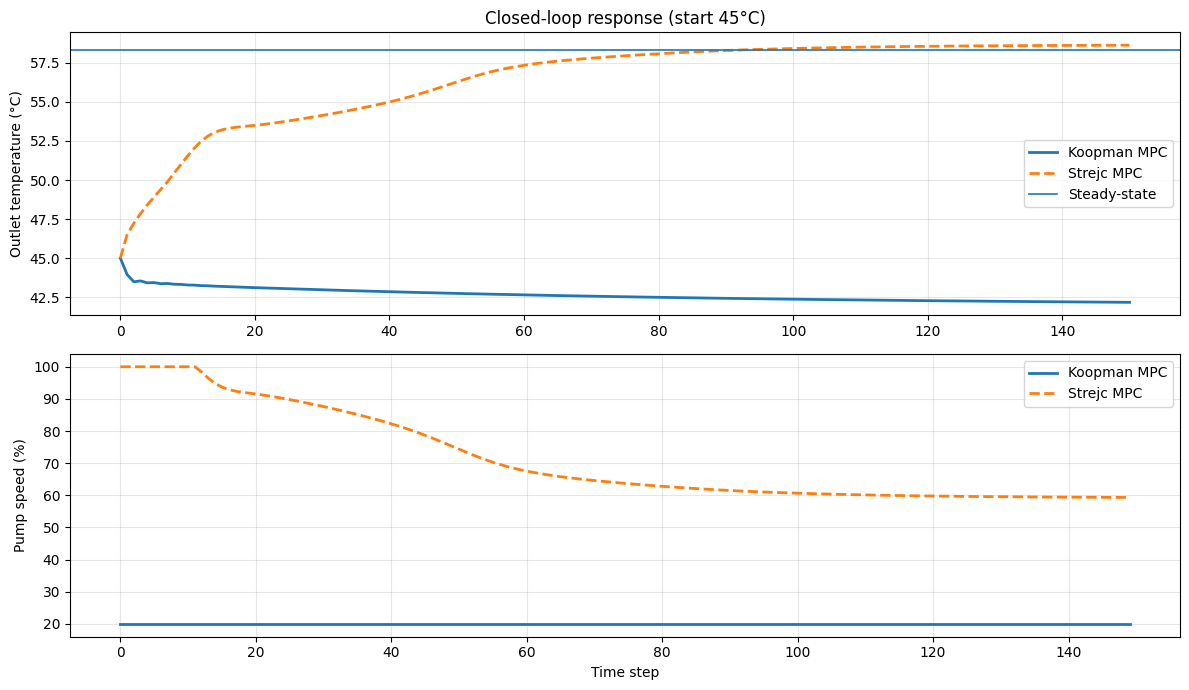

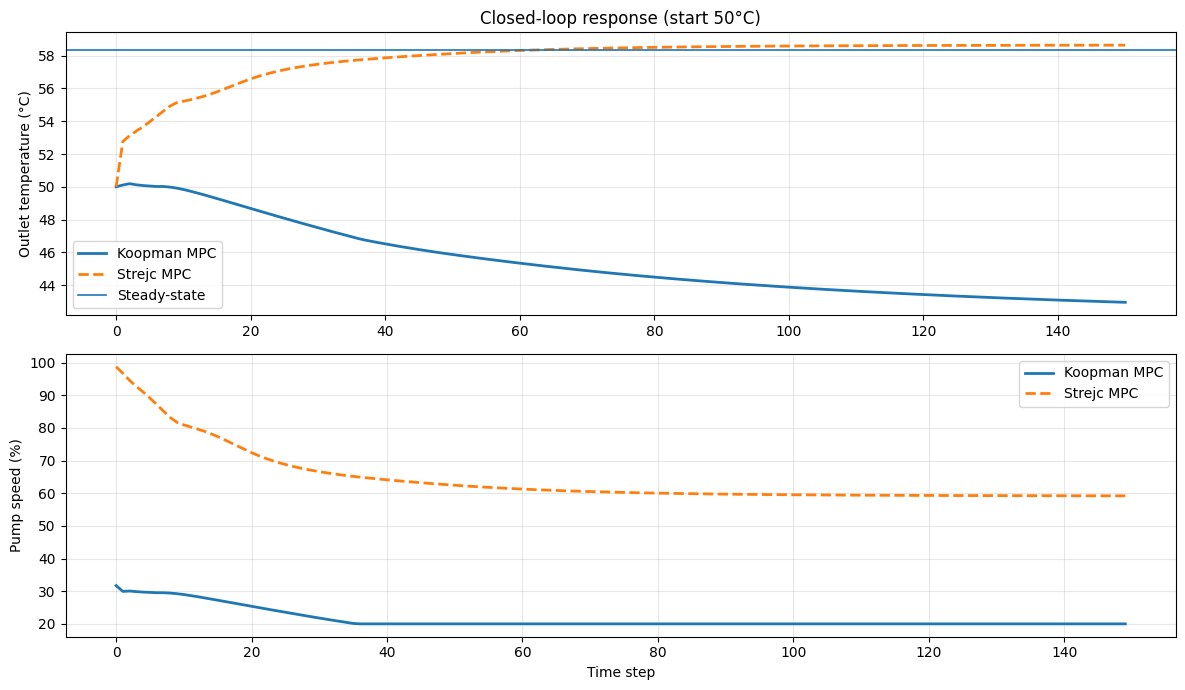

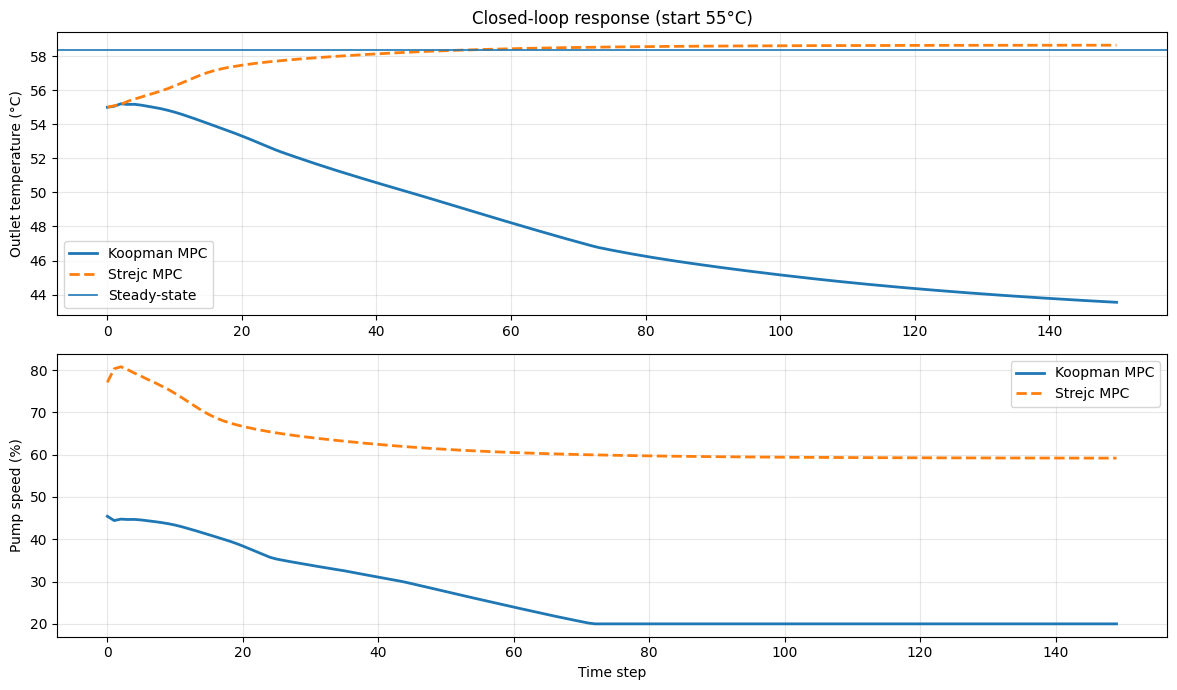

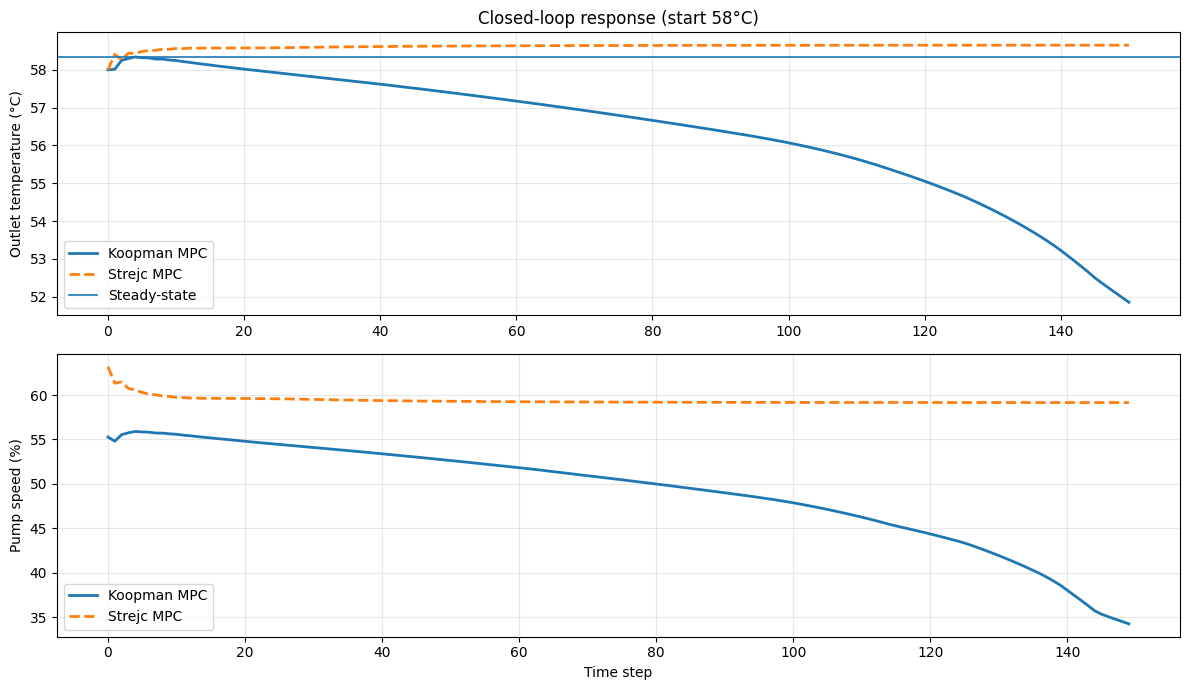

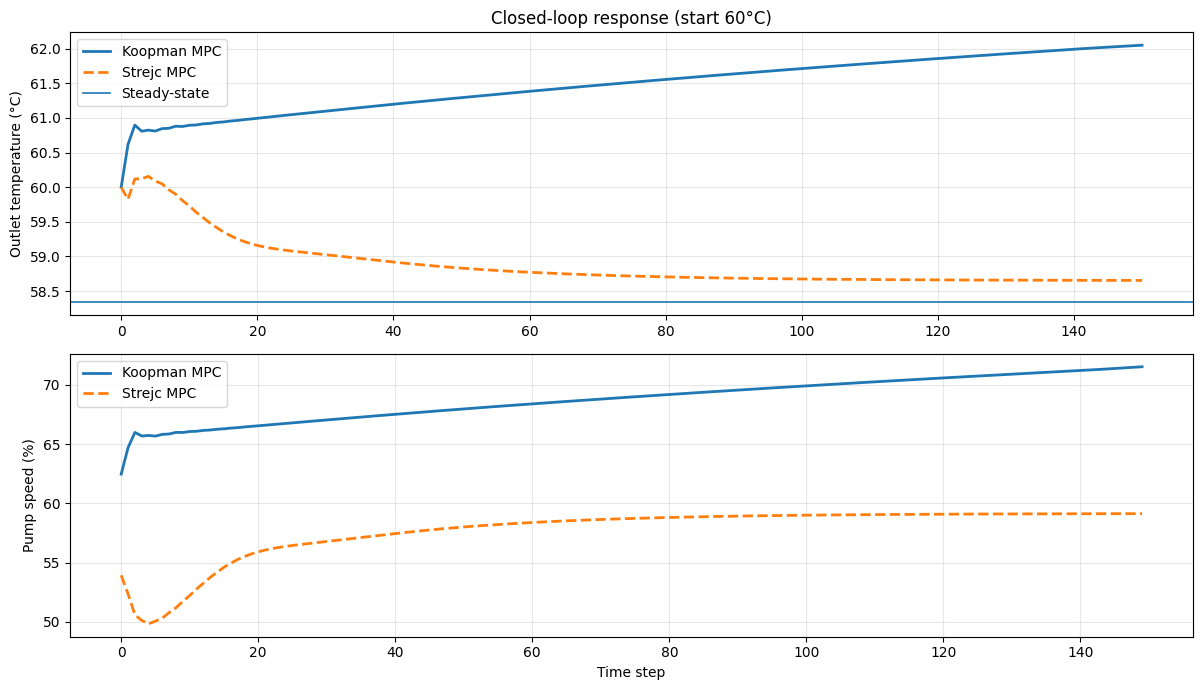

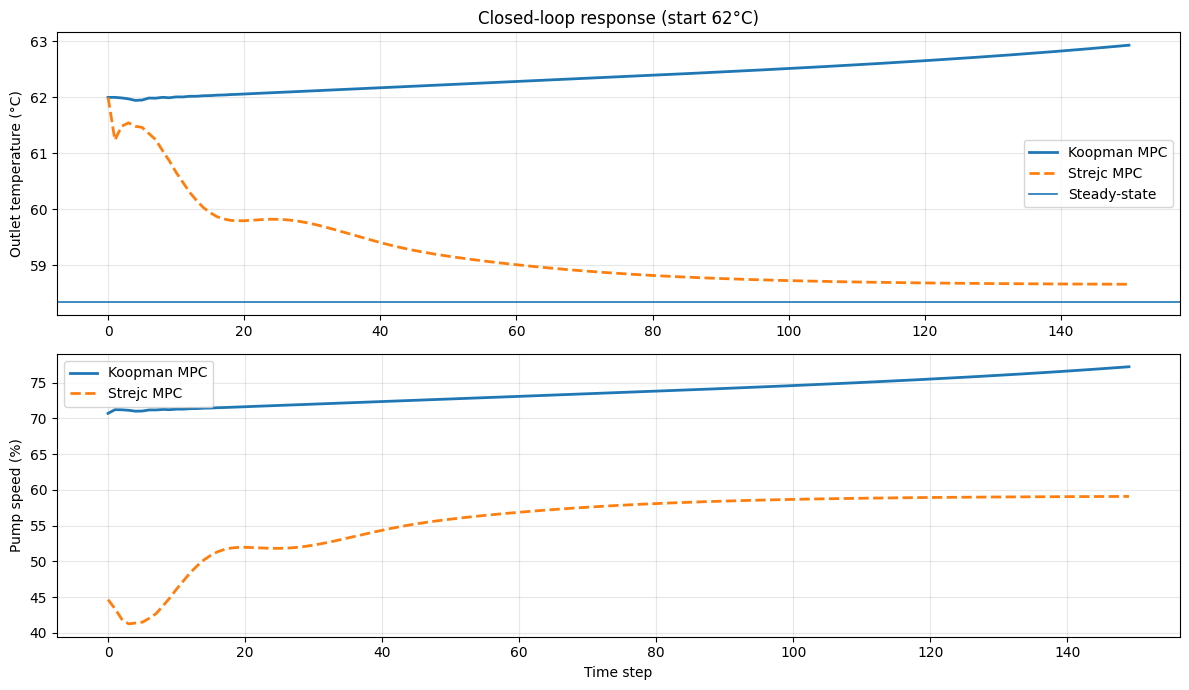

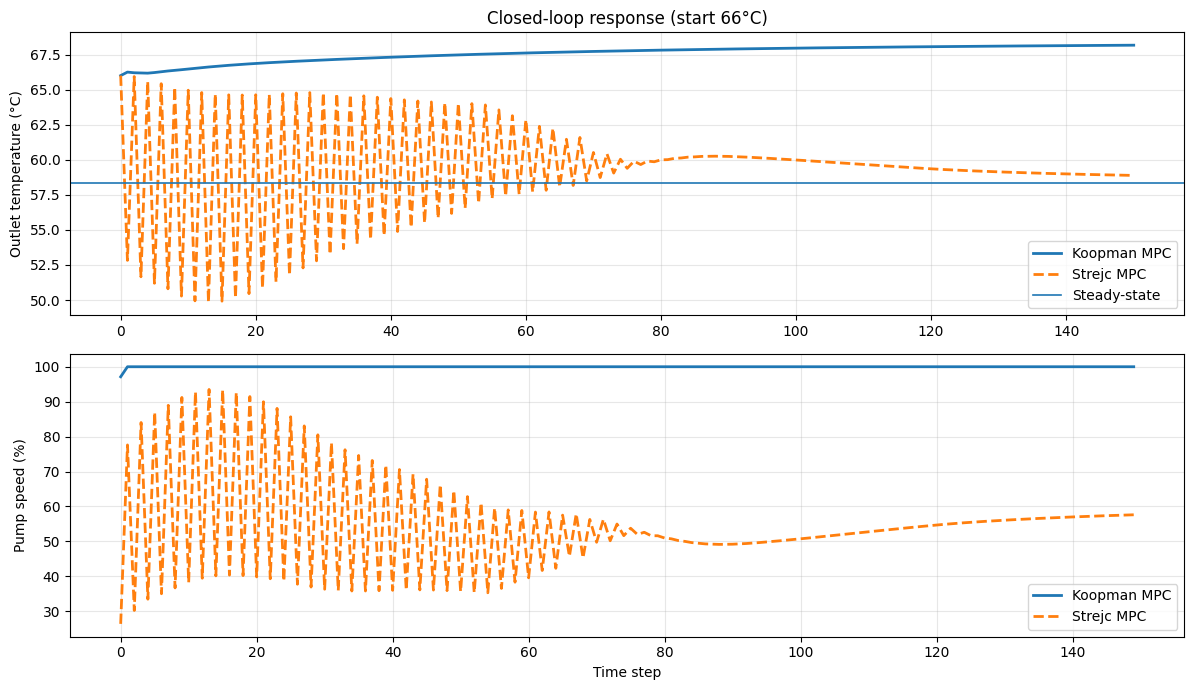

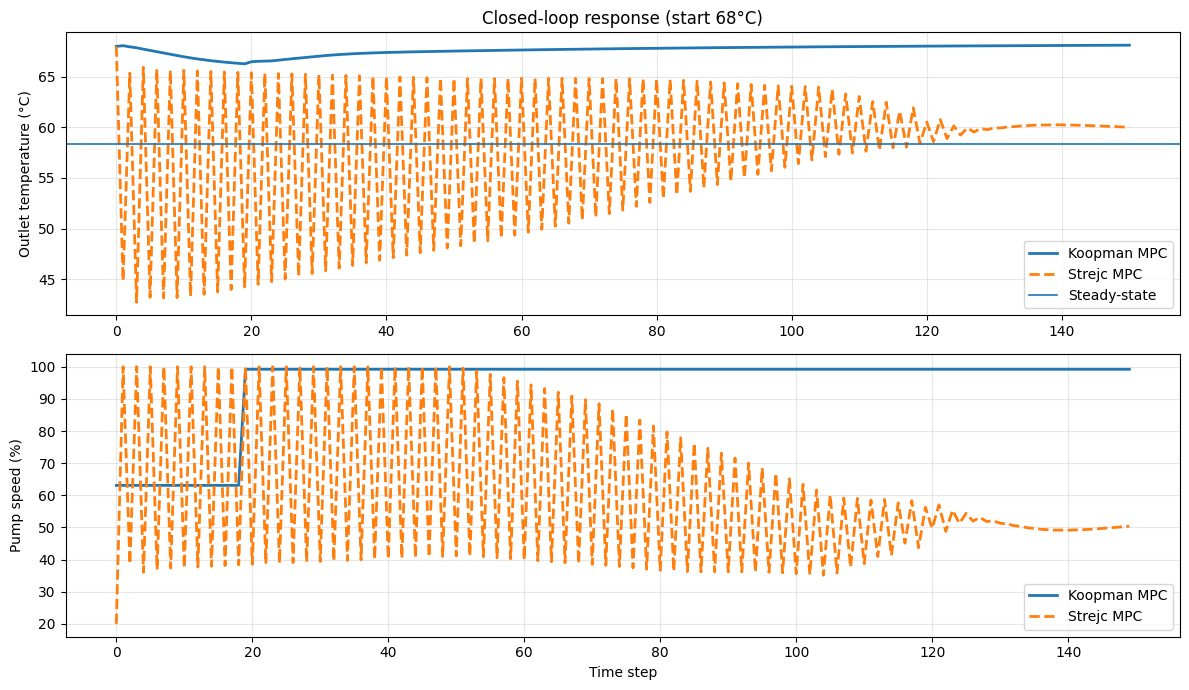

In [ ]:
for T0 in temps:
    res = all_results[T0]

    tY = np.arange(sim_length + 1)
    tU = np.arange(sim_length)

    plt.figure(figsize=(12, 7))

    plt.subplot(2, 1, 1)
    plt.plot(tY, res["y_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tY, res["y_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.axhline(x_mean, linewidth=1.2, label="Steady-state")
    plt.grid(True, which="both", alpha=0.3)
    plt.ylabel("Outlet temperature (°C)")
    plt.title(f"Closed-loop response (start {T0}°C)")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tU, res["u_koop"], label="Koopman MPC", linewidth=2)
    plt.plot(tU, res["u_strejc"], "--", label="Strejc MPC", linewidth=2)
    plt.grid(True, which="both", alpha=0.3)
    plt.xlabel("Time step")
    plt.ylabel("Pump speed (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
summary = []

for T0 in temps:
    res = all_results[T0]

    e_k = res["y_koop"][:-1] - x_mean
    e_s = res["y_strejc"][:-1] - x_mean

    rmse_k = np.sqrt(np.mean(e_k**2))
    rmse_s = np.sqrt(np.mean(e_s**2))

    iae_k = np.sum(np.abs(e_k))
    iae_s = np.sum(np.abs(e_s))

    yk_scaled = (res["y_koop"][:-1] - x_mean) / x_std
    ys_scaled = (res["y_strejc"][:-1] - x_mean) / x_std
    uk_scaled = (res["u_koop"] - u_mean) / u_std
    us_scaled = (res["u_strejc"] - u_mean) / u_std

    obj_k = np.sum(Qy * yk_scaled**2 + Qu * uk_scaled**2)
    obj_s = np.sum(Qy * ys_scaled**2 + Qu * us_scaled**2)

    summary.append([T0, rmse_k, rmse_s, iae_k, iae_s, obj_k, obj_s])

summary_df = pd.DataFrame(
    summary,
    columns=["T0", "RMSE_K", "RMSE_S", "IAE_K", "IAE_S", "Obj_K", "Obj_S"]
)

print(summary_df)

   T0     RMSE_K    RMSE_S        IAE_K       IAE_S        Obj_K        Obj_S
0  45  15.696162  3.447104  2353.589021  305.390414  7775.243887   421.436627
1  50  13.102318  1.507842  1937.282782  117.748126  5535.195492    86.783017
2  55  11.053580  0.871672  1561.031502   77.132351  3989.603822    29.797459
3  58   2.518493  0.288032   290.932057   42.638884   246.926575     6.108682
4  60   3.157486  0.660958   470.094550   82.531383   304.362648    21.874143
5  62   4.056275  1.133391   607.112099  129.309543   517.278264    57.414323
6  66   9.250623  3.964073  1385.068420  459.177340  2887.374250   539.003474
7  68   9.312649  7.350810  1395.104137  927.486058  2863.768035  1755.889889


In [ ]:
baseline_inference.init()
baseline_inference.get_x(y0_scaled)

ys = []
for k in range(200):
    ys.append(baseline_inference.y_plus(u_const_scaled))

NameError: name 'u_const_scaled' is not defined

C:\Users\ivadu\AppData\Local\Temp\ipykernel_6156\199569409.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(25, 5))


0.27135063568421175
[ 0.50660515 -0.97560817  0.46068433 -0.09581248 -0.16290087  0.8469686
 -0.7563312  -0.05706884  0.48579115  0.5867551  -0.6192273  -1.0689116
  0.00641317 -0.34902748  0.16825637 -0.74451035 -0.48926276  1.4003503
 -0.03465385 -0.6510006  -0.2605928   0.14492503 -0.3777762  -1.1839902
  0.5066733  -0.1211803   0.7928104   0.12111302  0.20037921  0.09645985
 -0.8015784   0.00591649  0.4548855   0.1410803   1.075697   -0.02628761
  0.46838328 -0.96030825  0.6083398  -1.0685863  -0.24600108  0.7057535
  0.19639404  0.2075609  -0.41257235 -1.067464   -0.29532927 -0.11409457
 -0.6536146   0.369094   -0.60496783  1.1437644  -0.26496586  0.16477531
 -0.02155782 -0.68538725 -1.3197839  -0.13707344  0.01345166  0.18490222
  0.25422853 -0.8222697  -0.14412953 -0.33457255  0.14248216 -0.0376678
  0.48979747  0.4857516  -1.0904499  -0.46722865  1.4439299   0.36590812
  0.5593432  -0.06468092  0.8612869  -0.7382244   1.1416976   1.4104048
  0.22052647 -0.03621831]
[ 0.0745559 

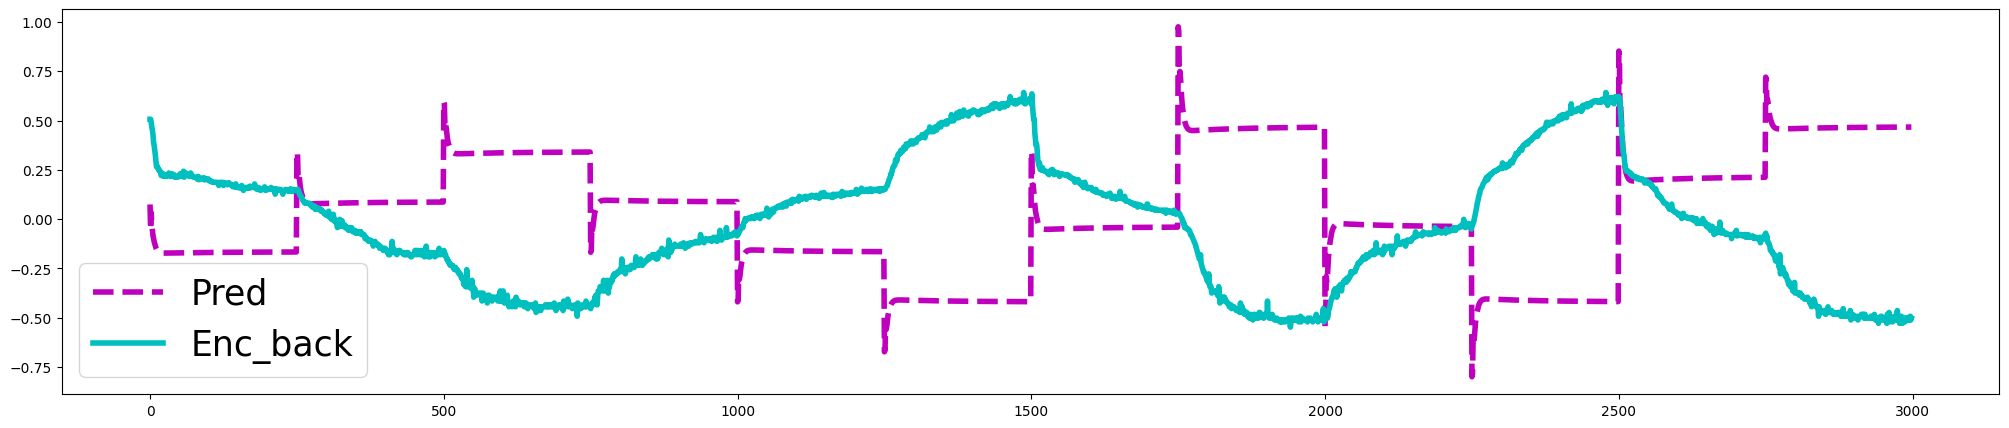

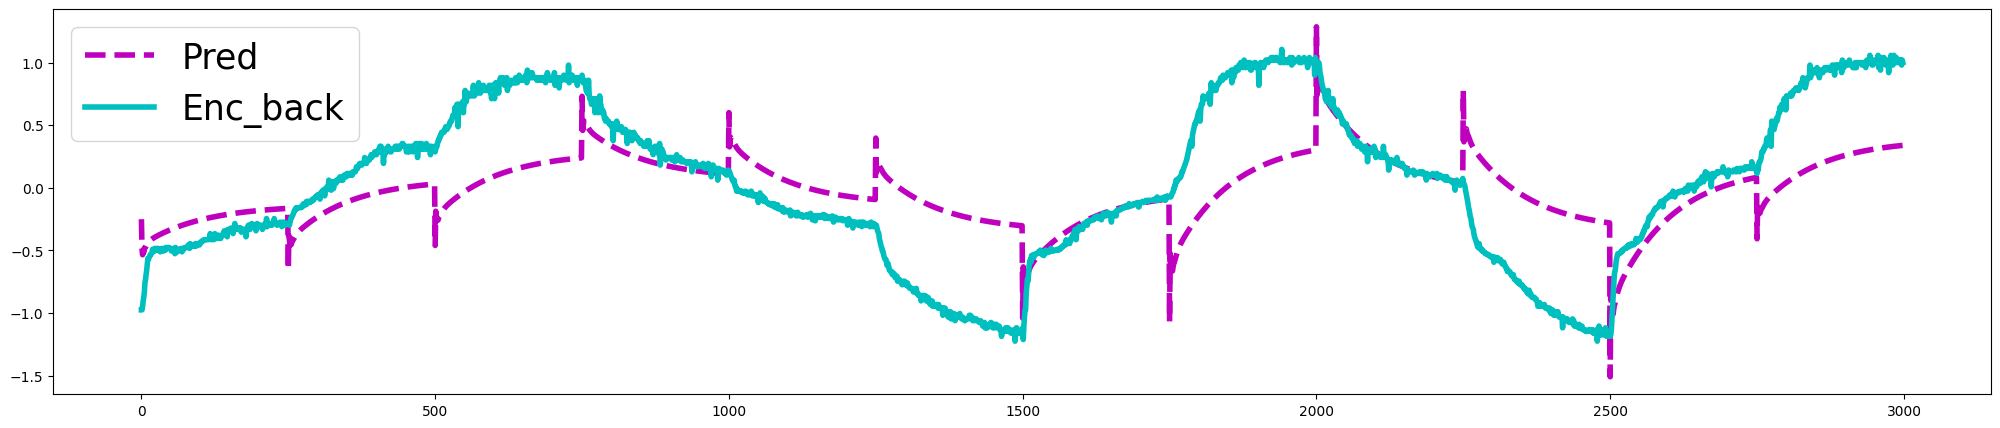

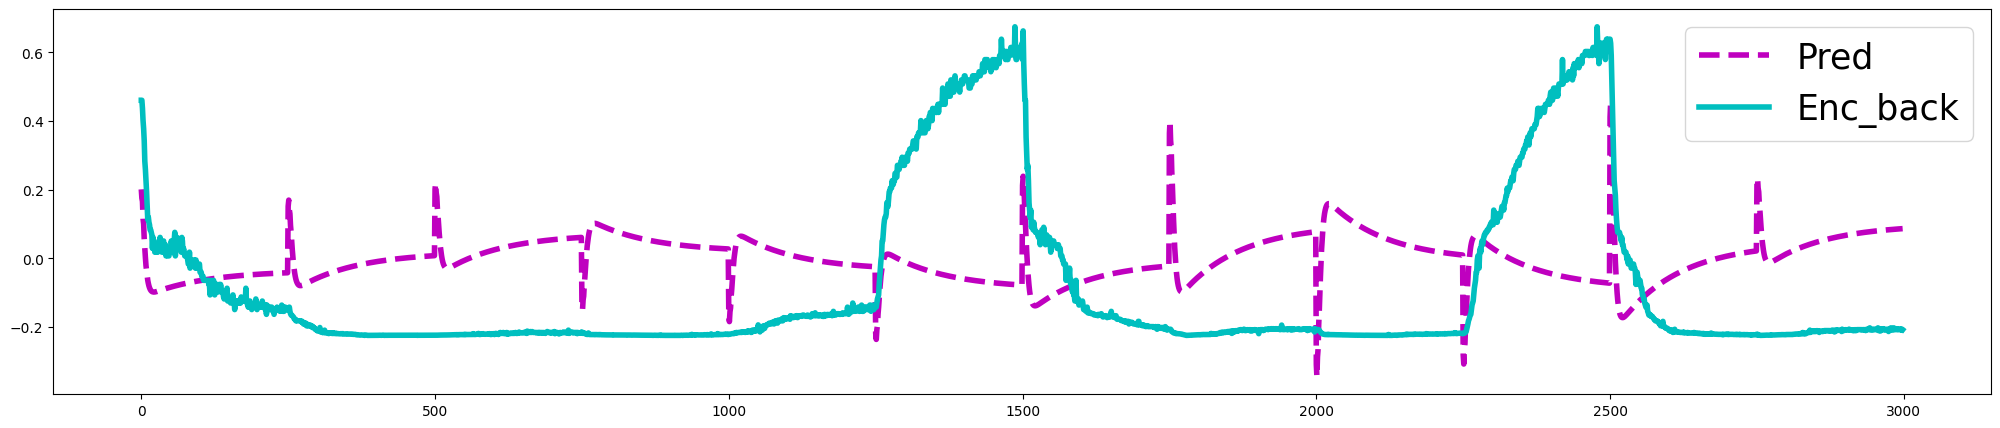

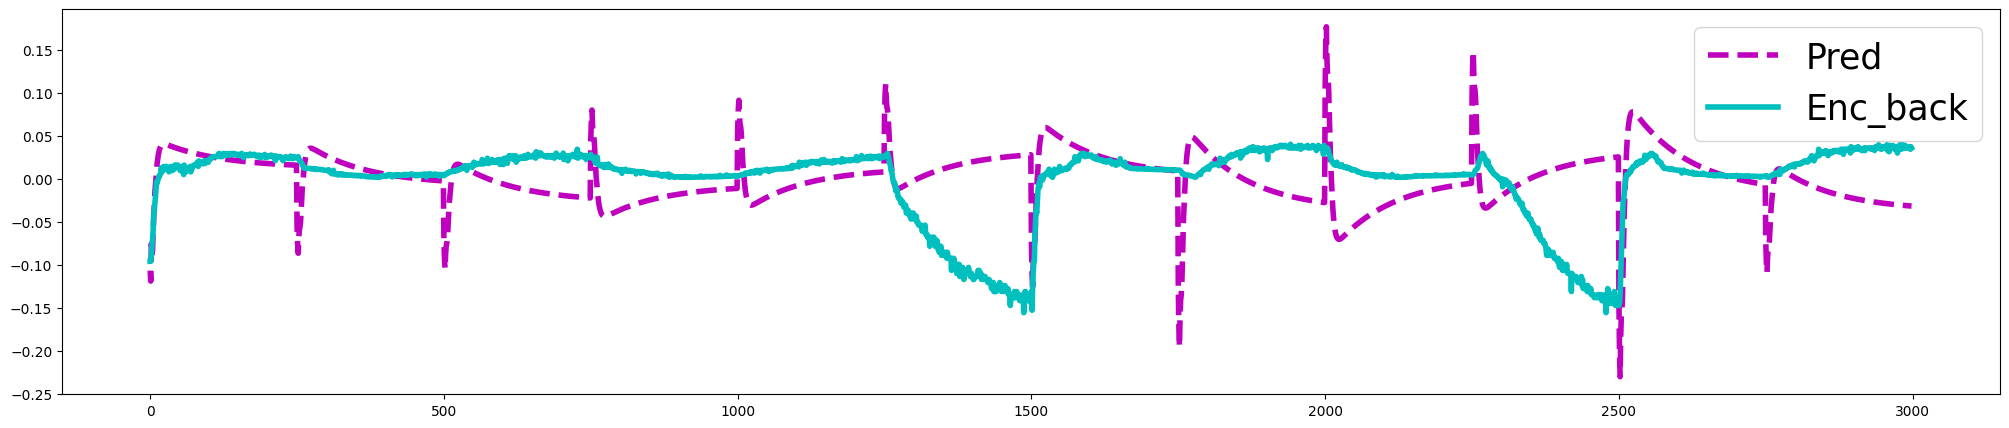

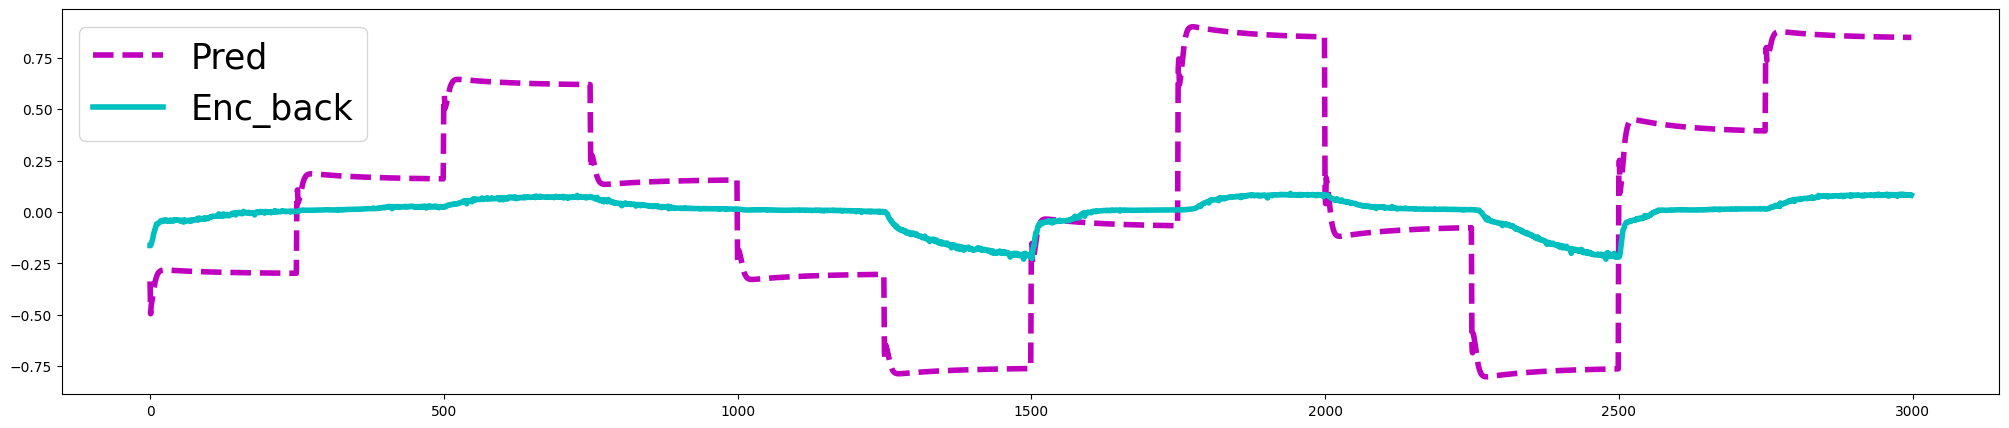

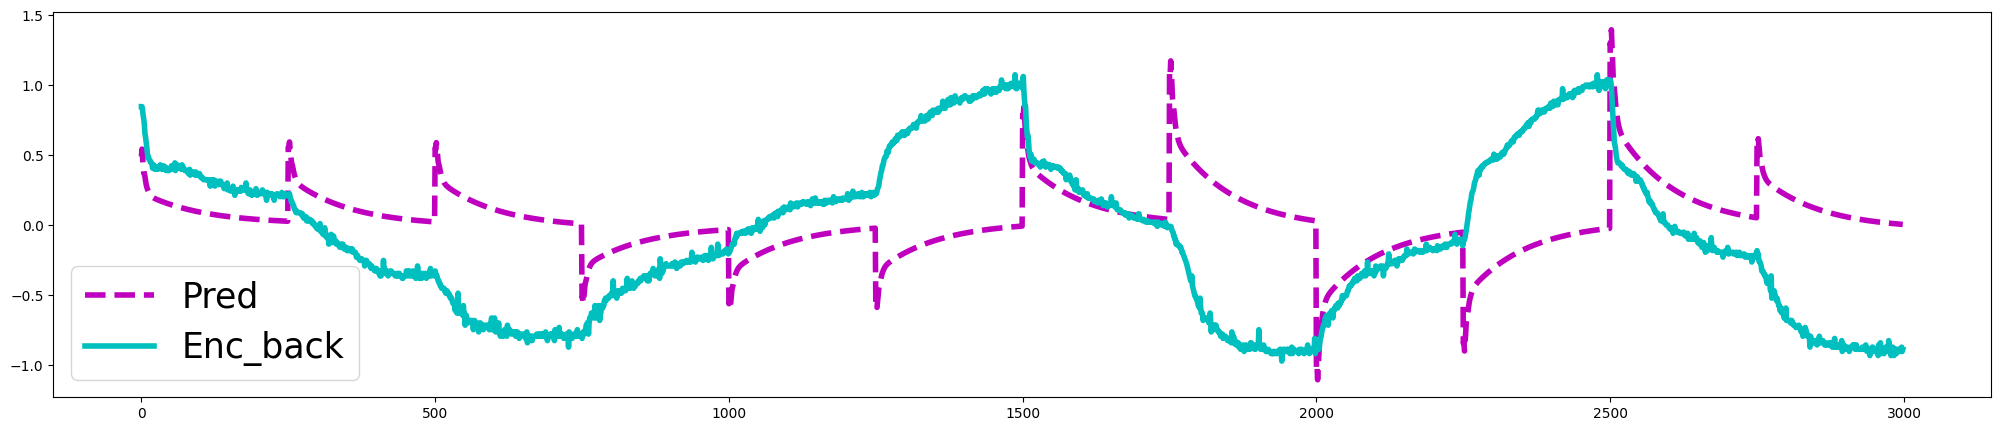

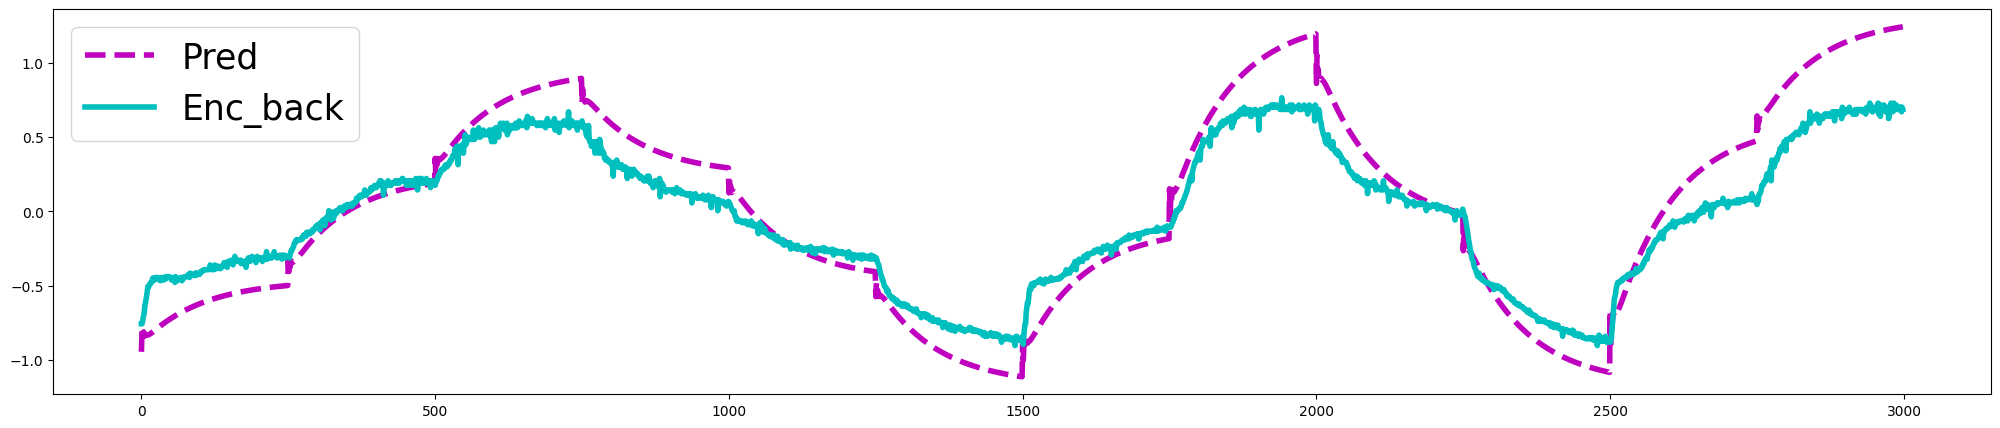

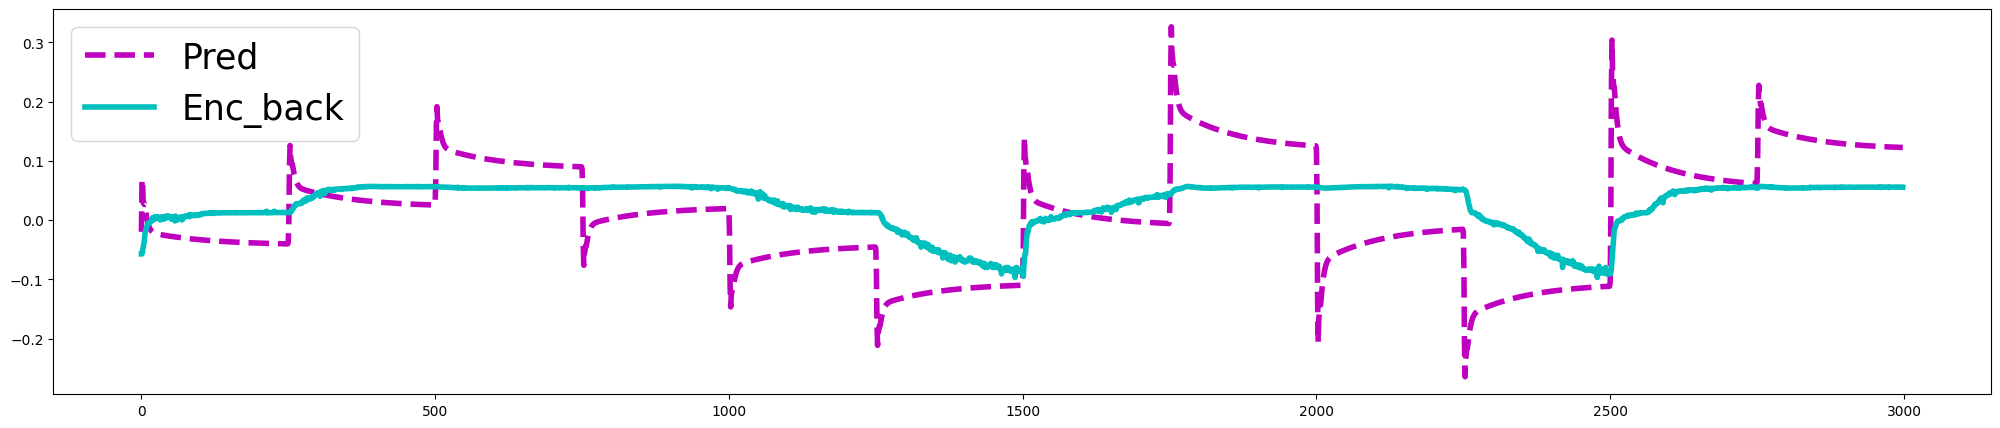

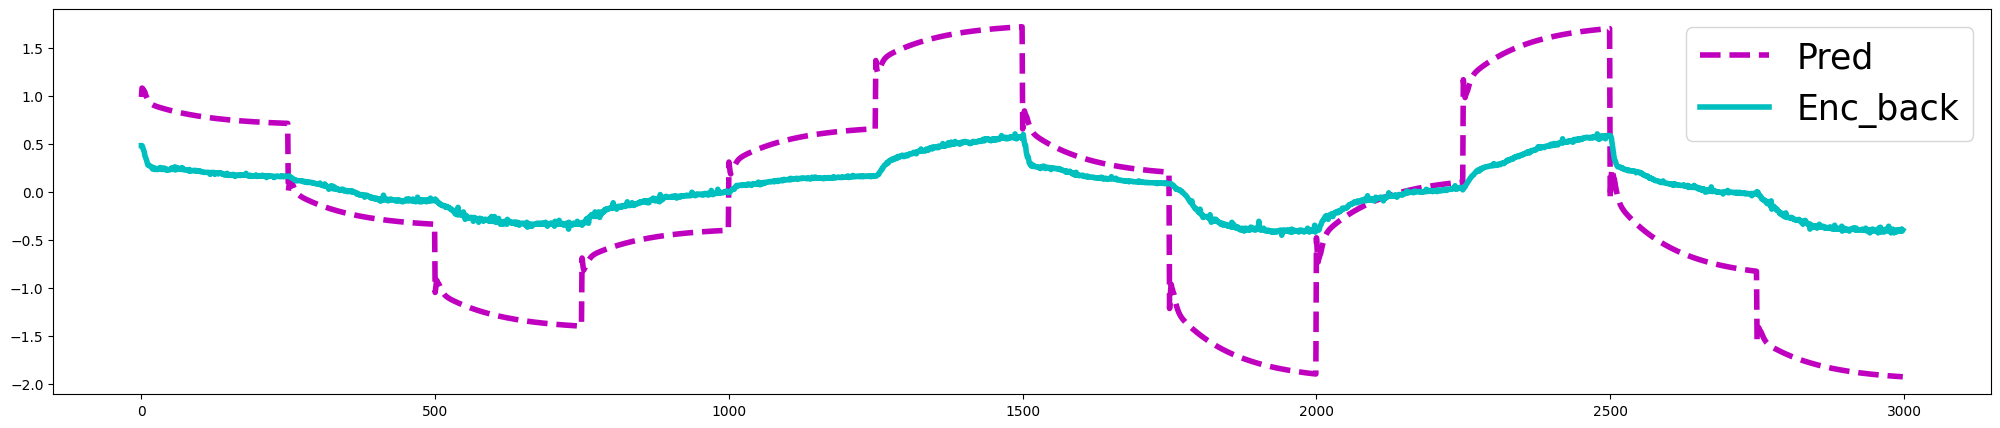

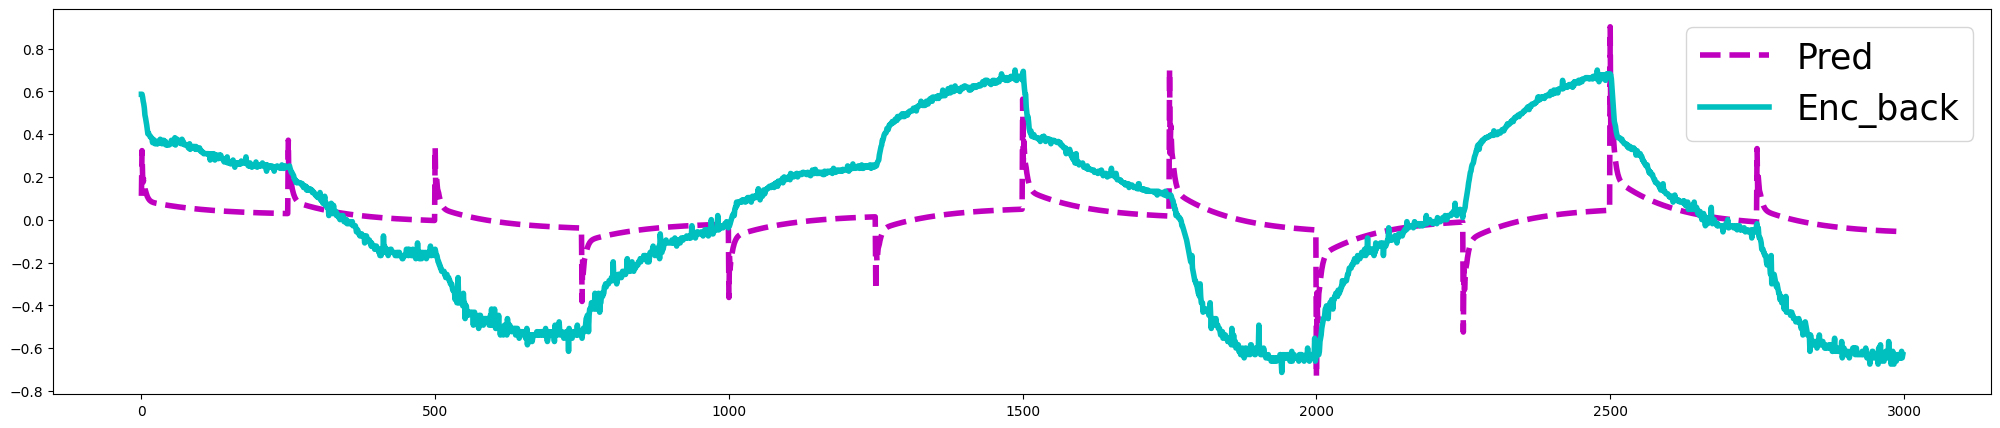

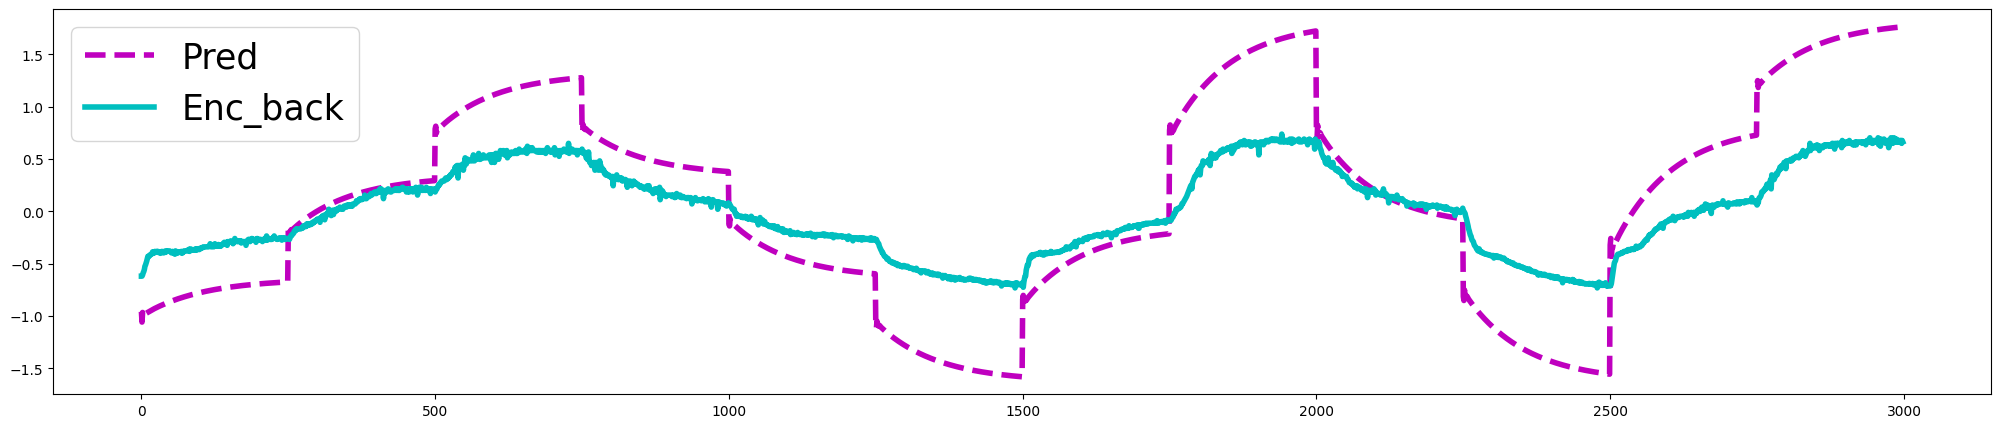

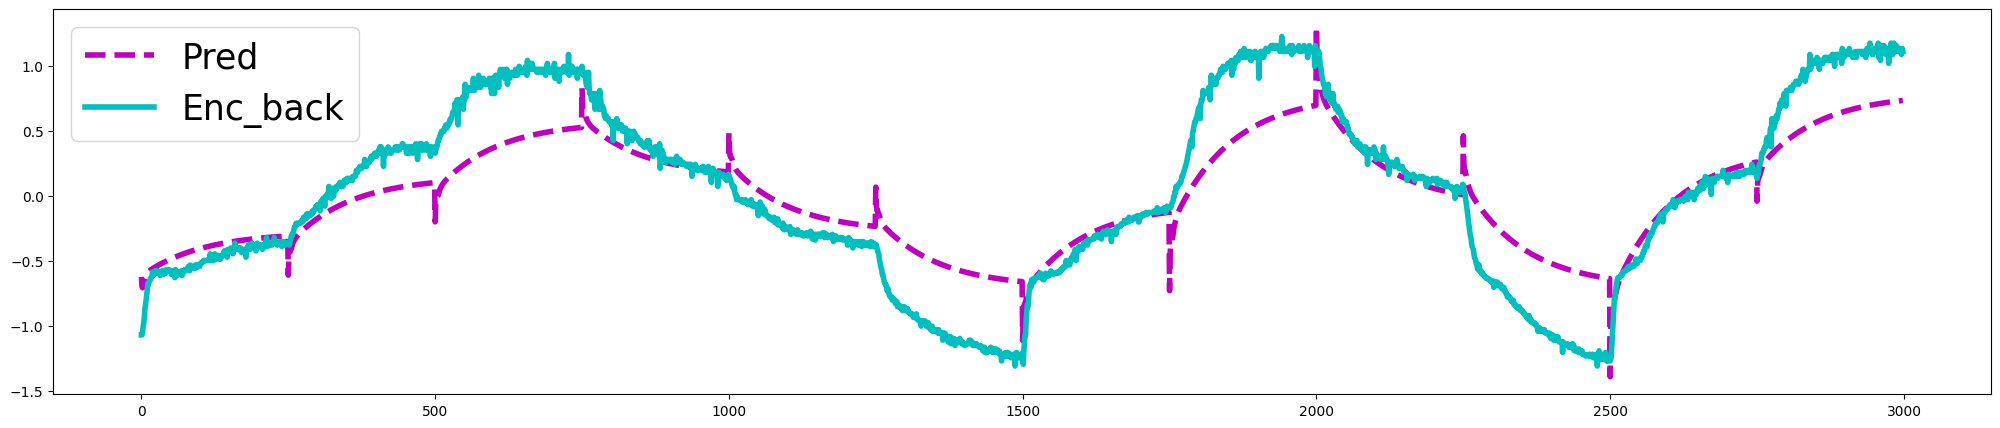

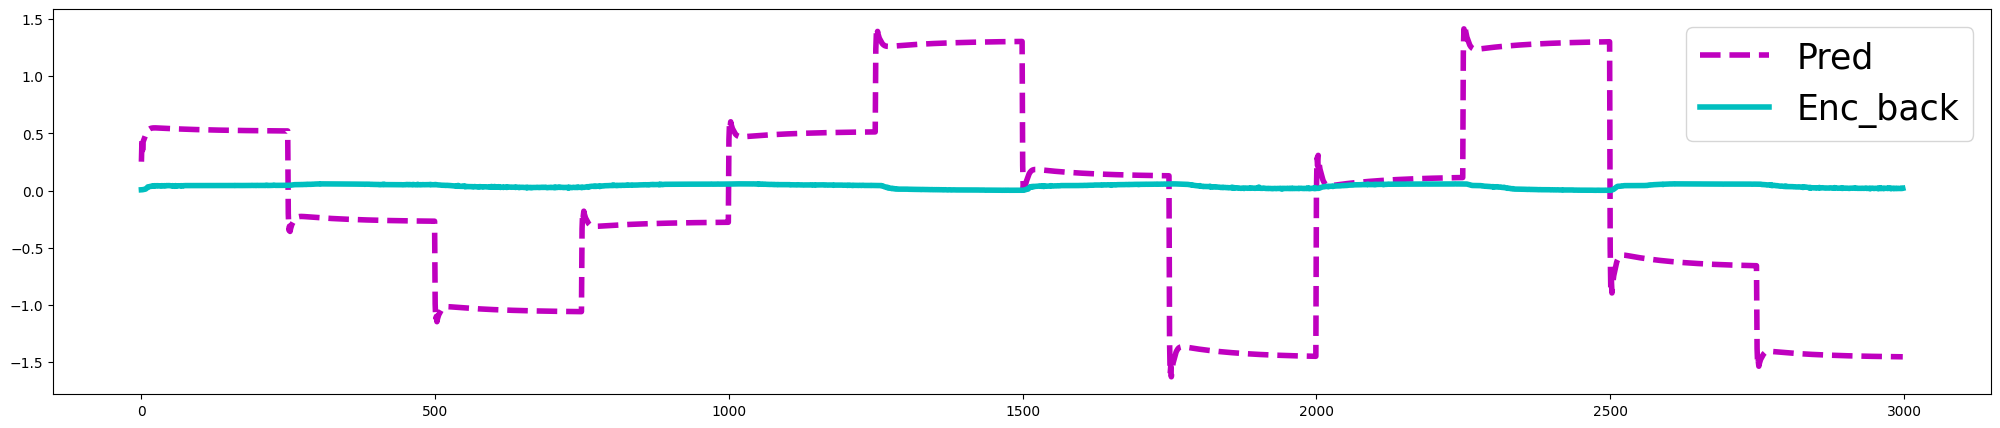

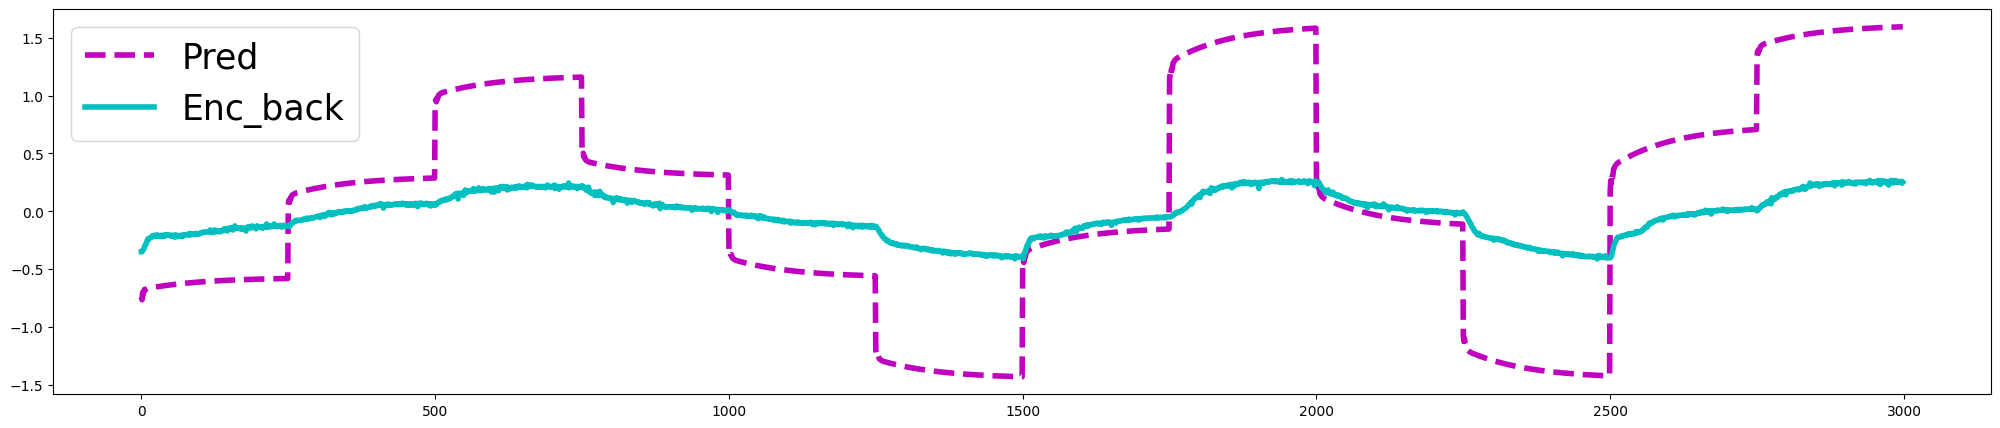

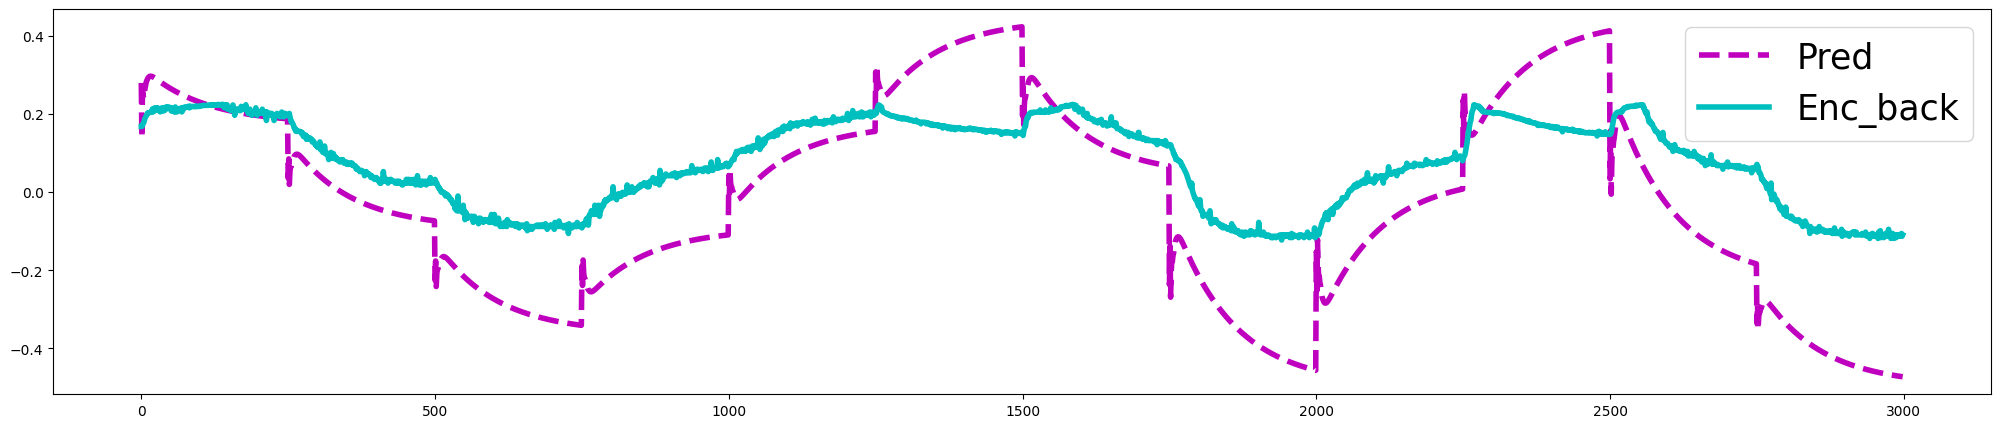

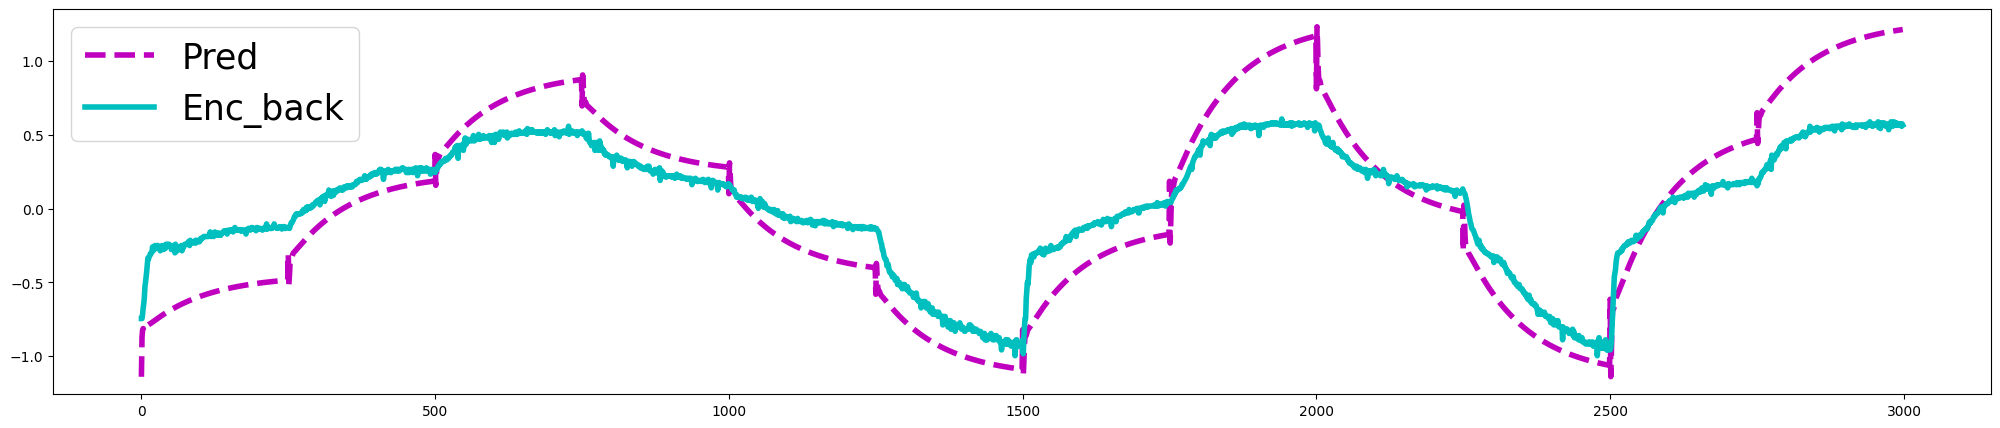

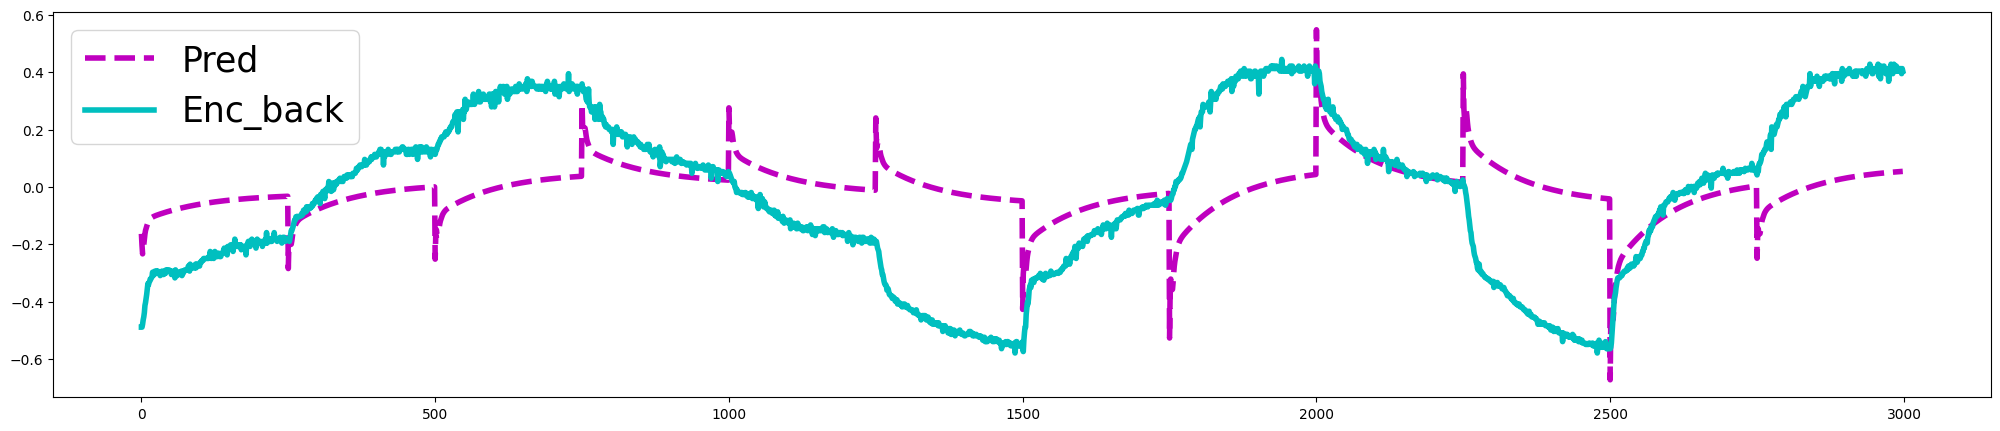

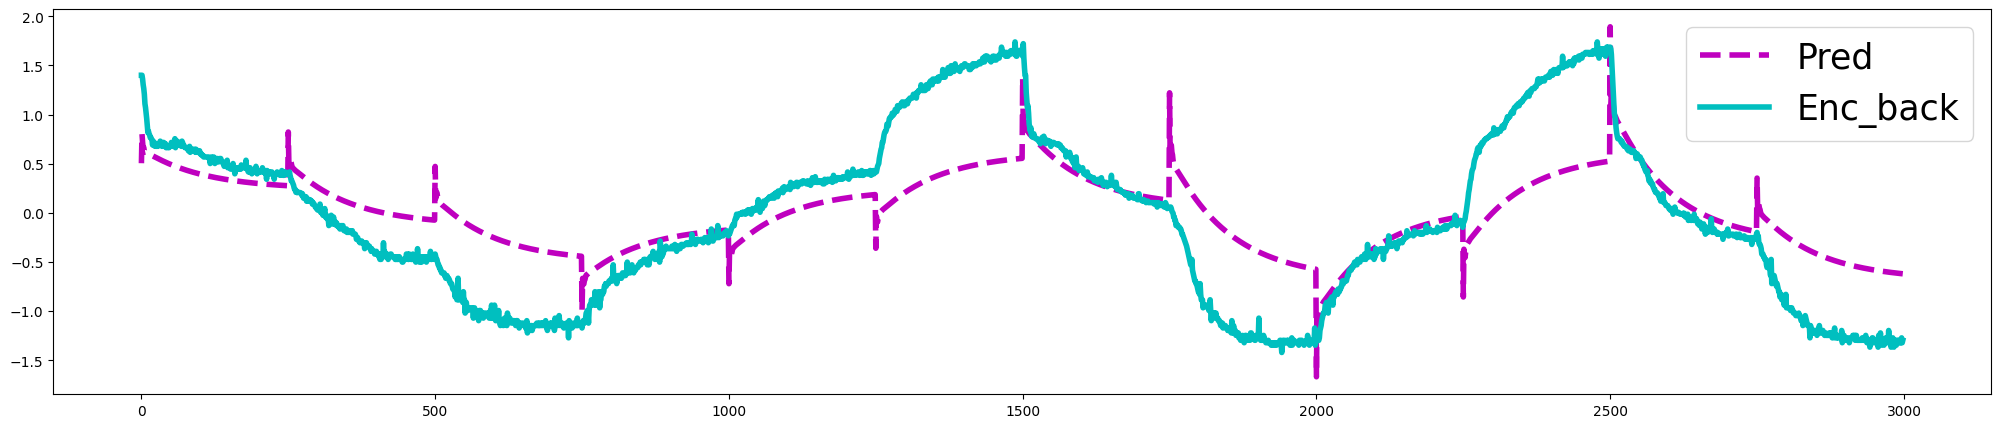

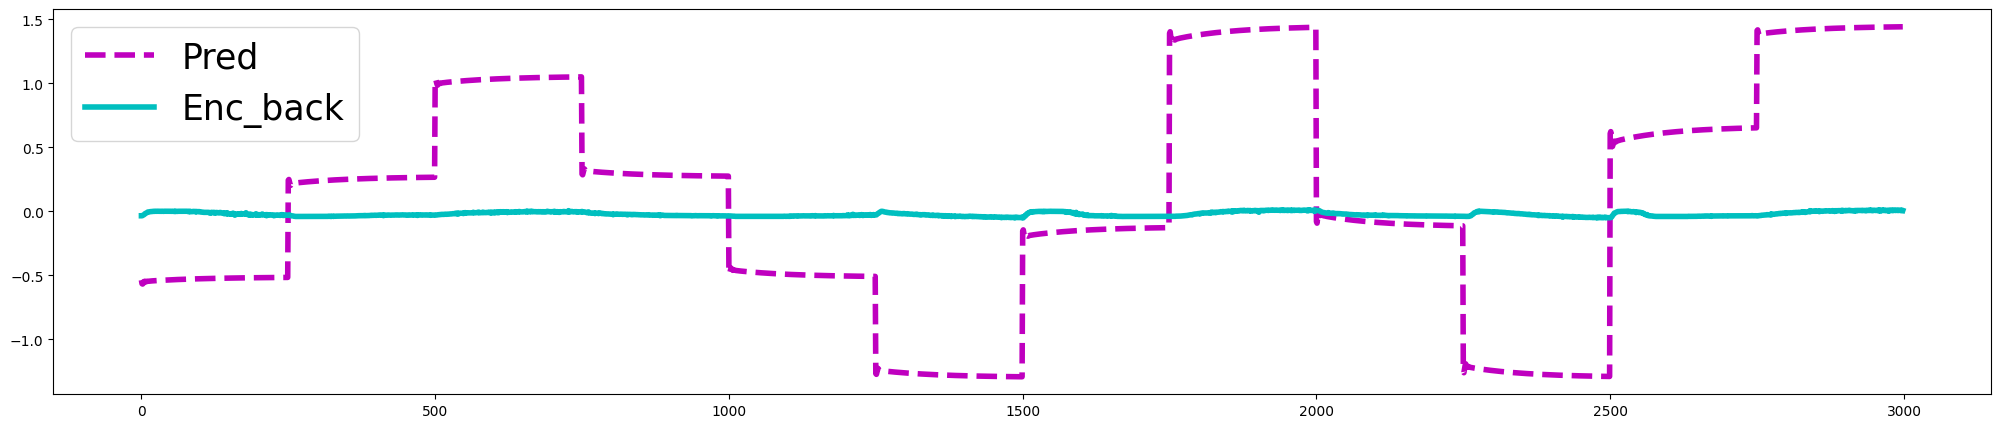

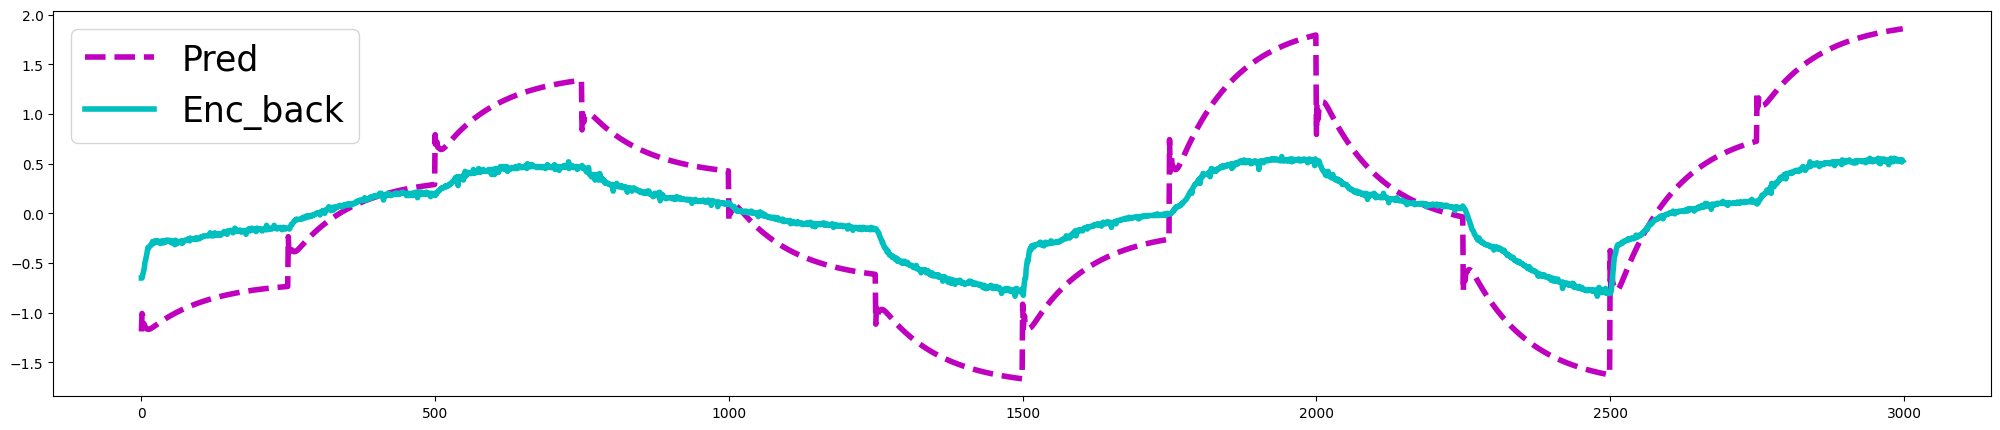

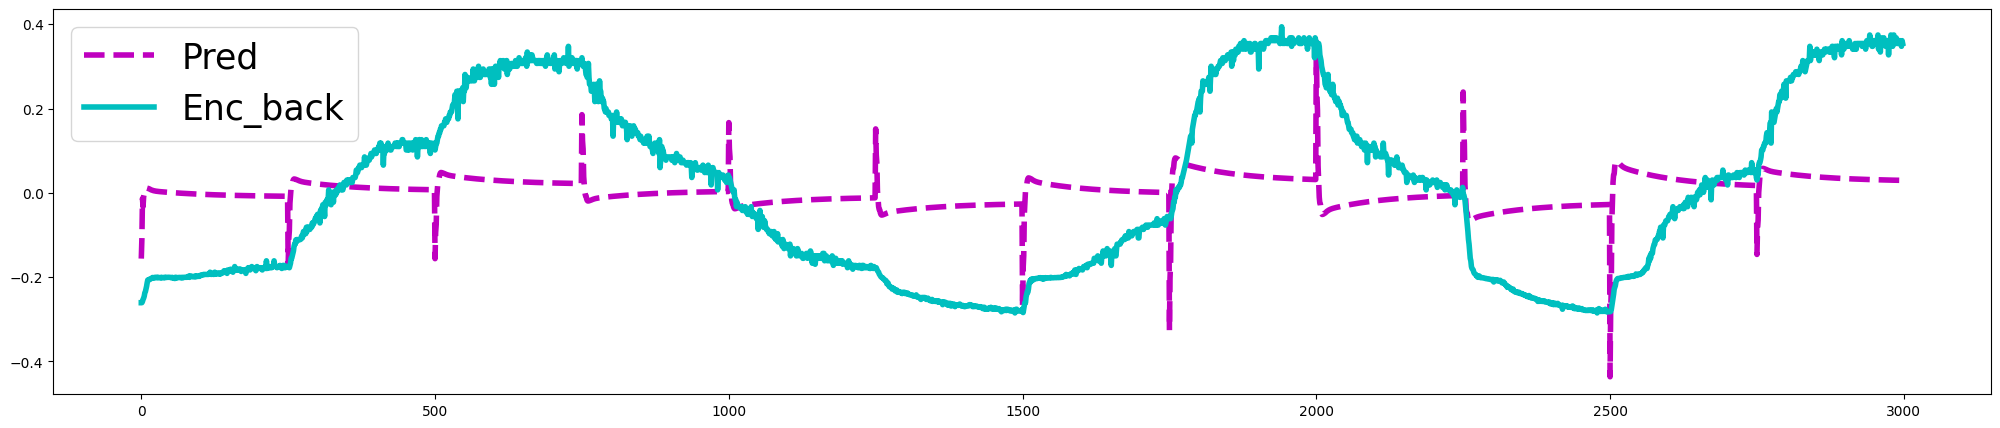

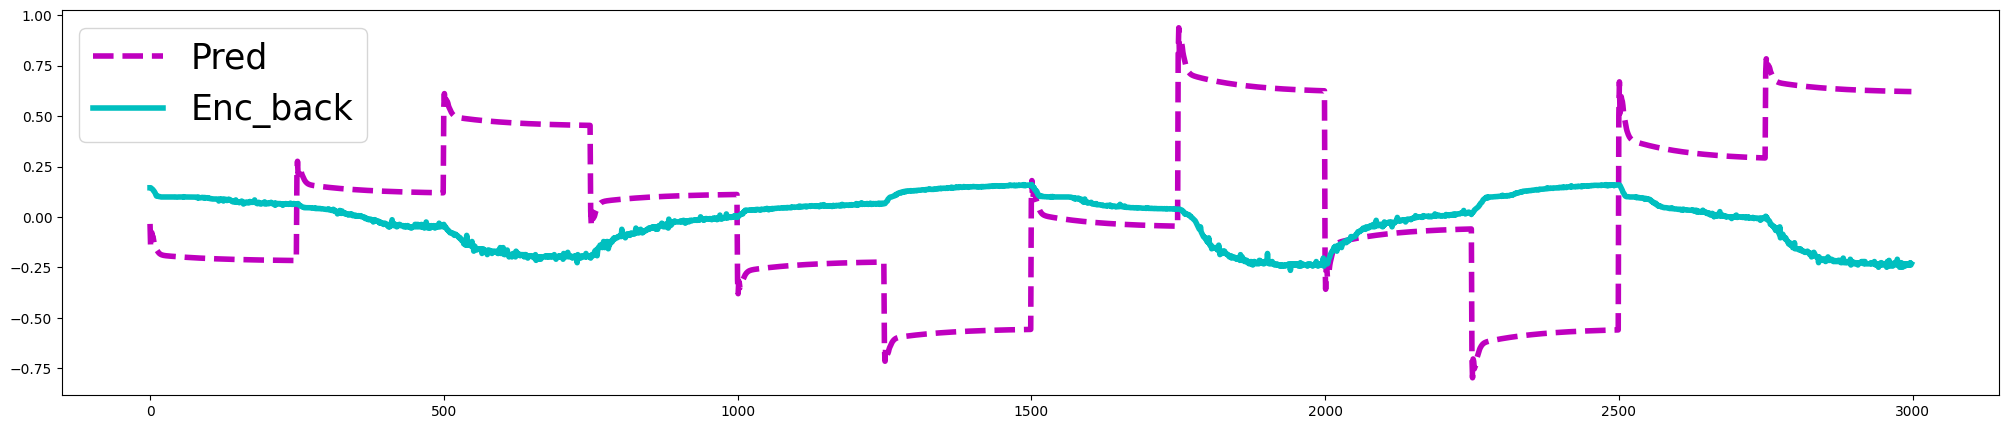

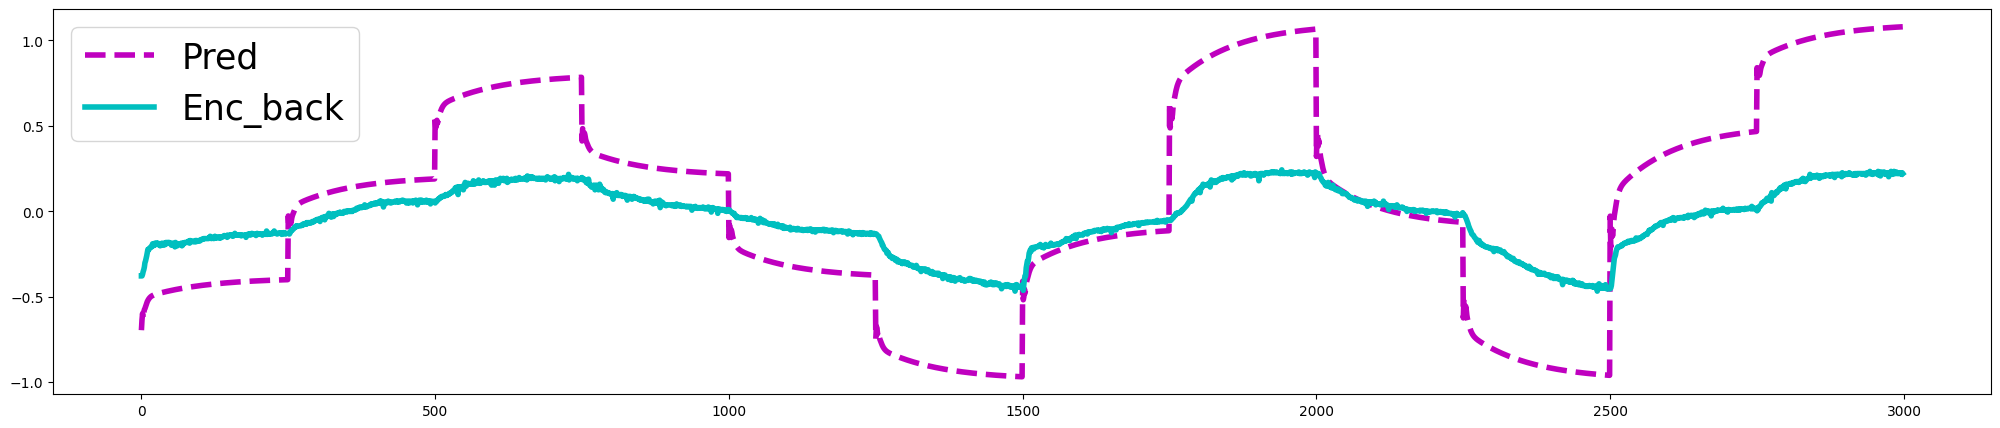

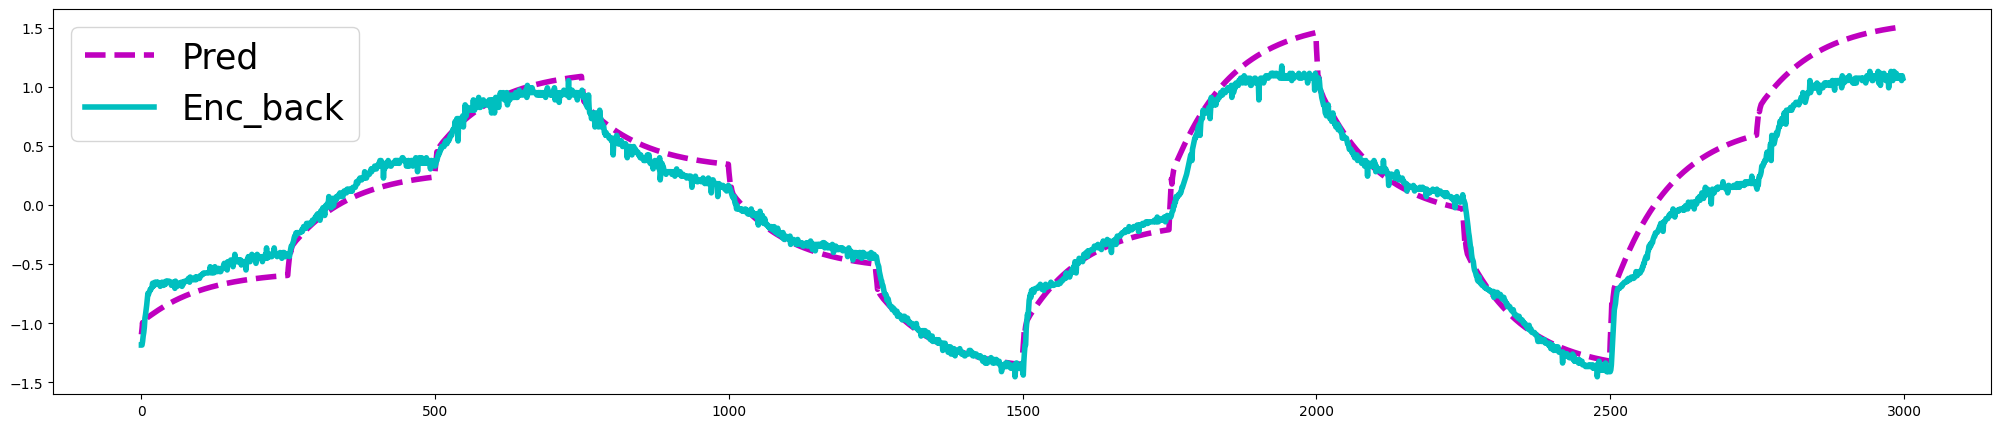

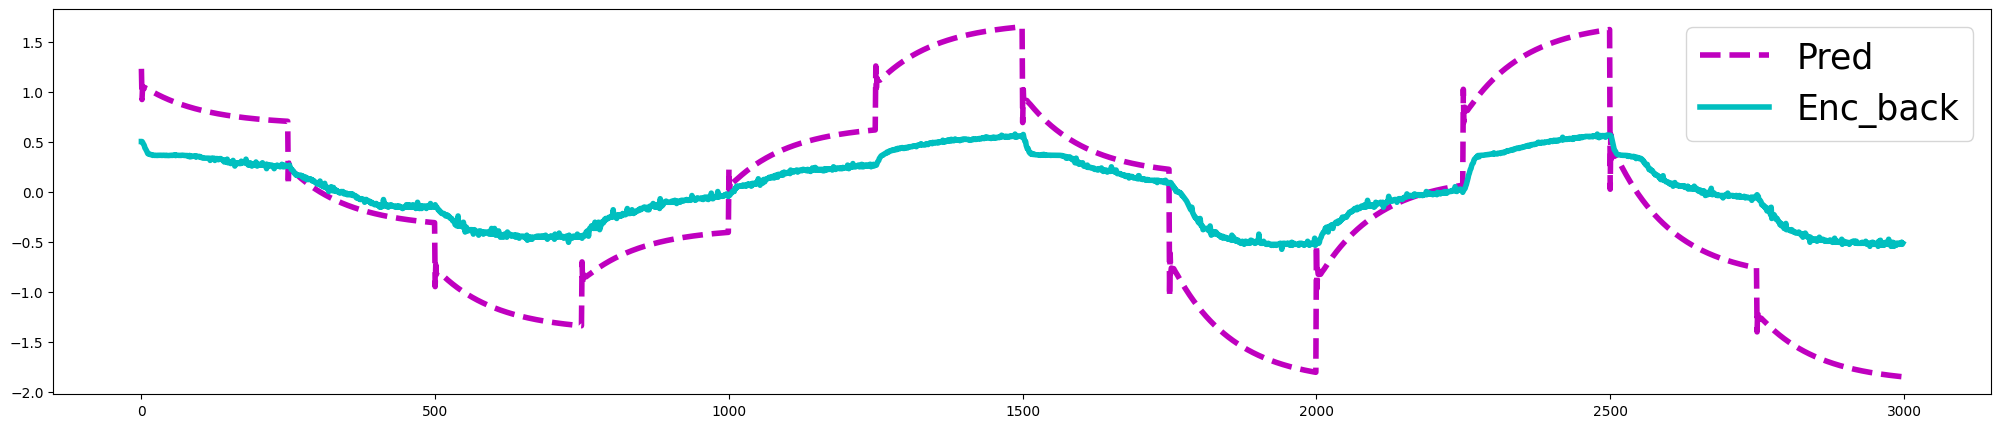

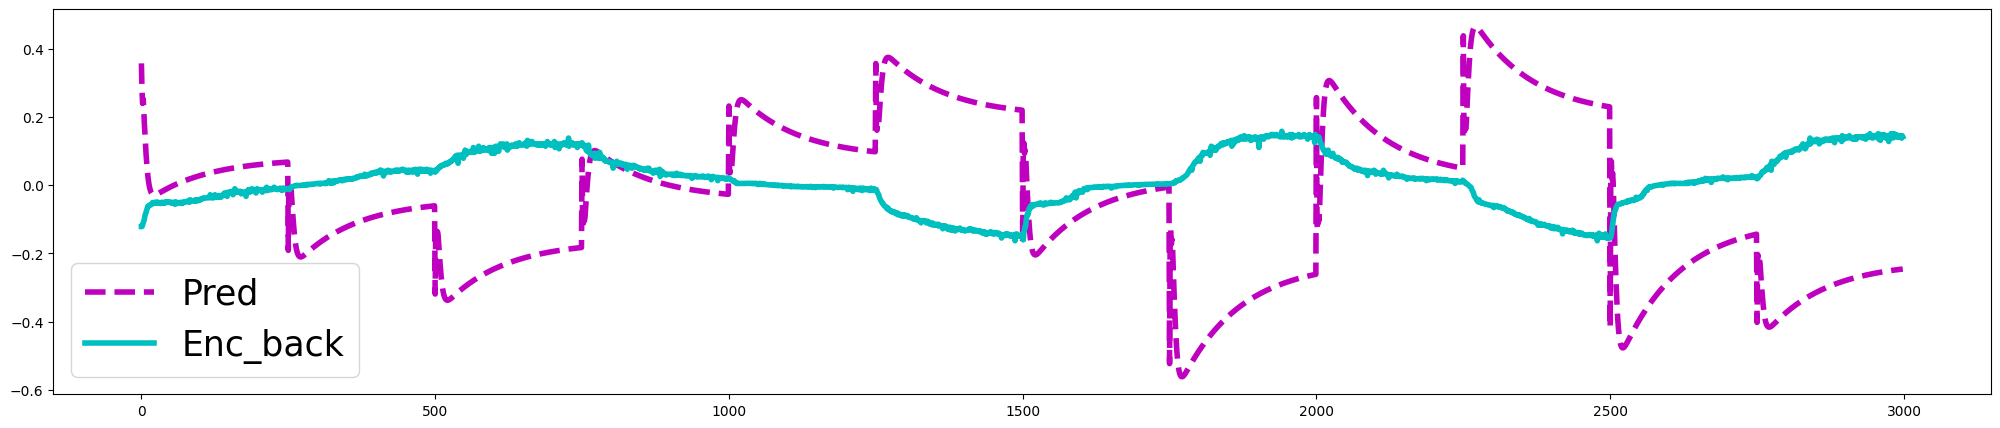

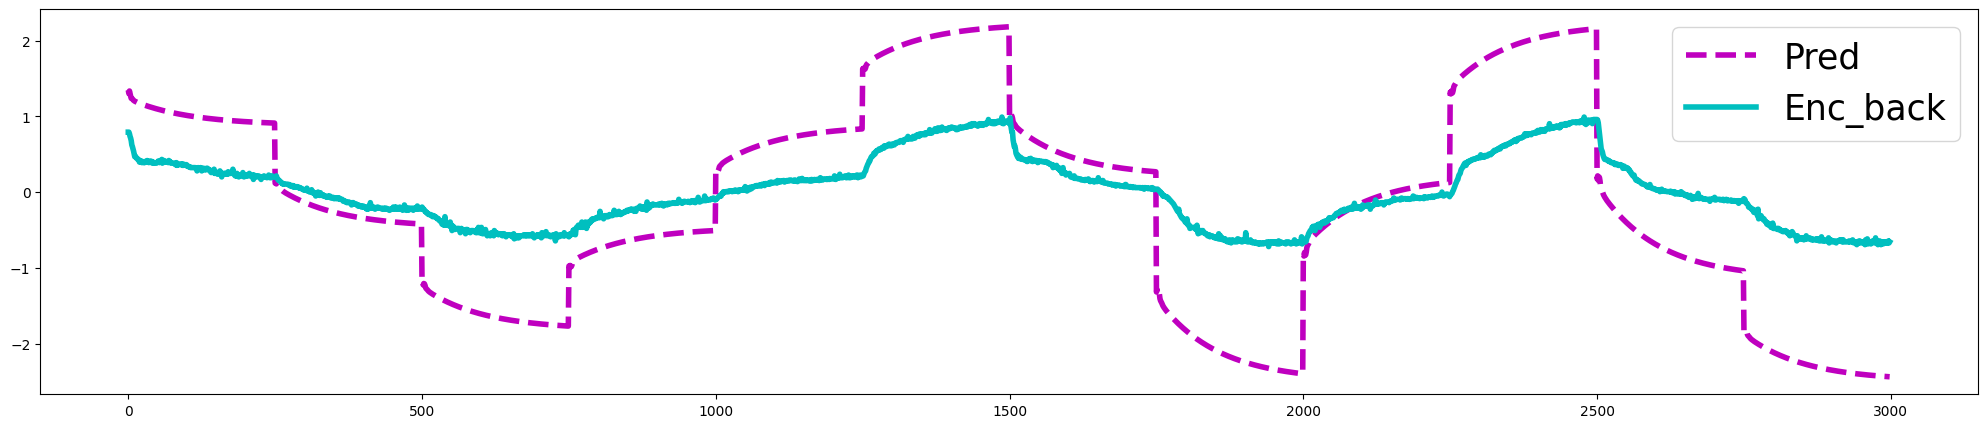

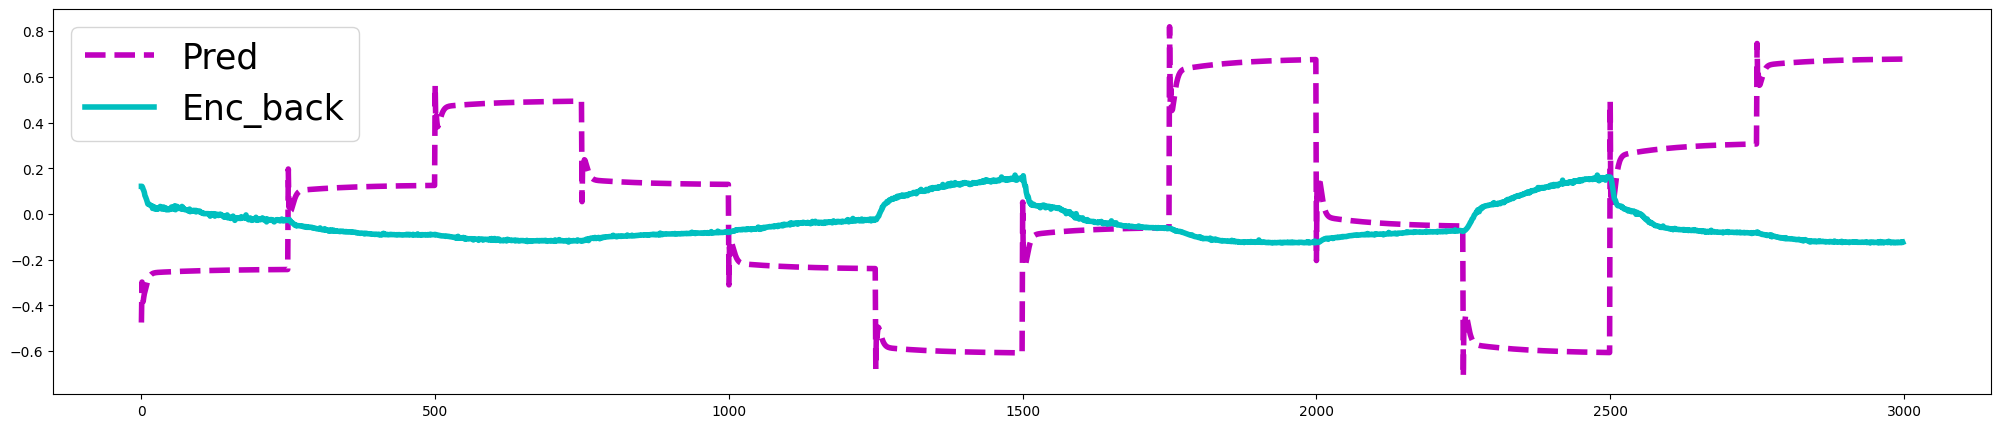

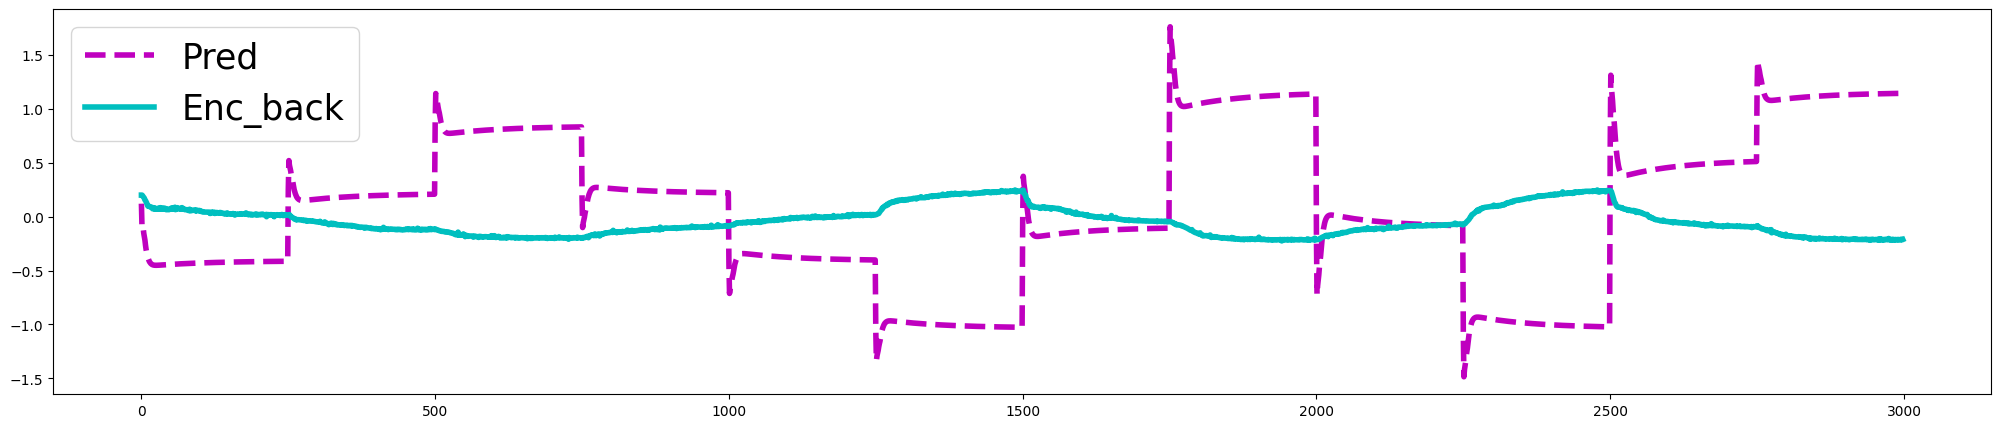

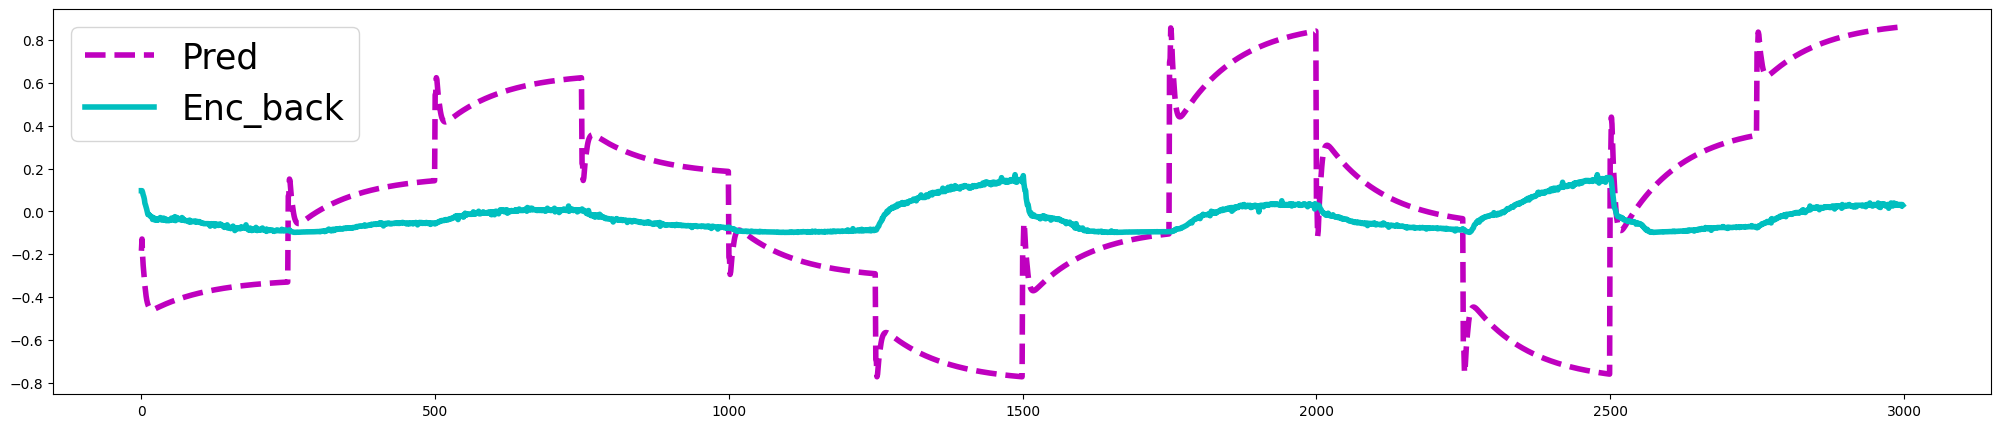

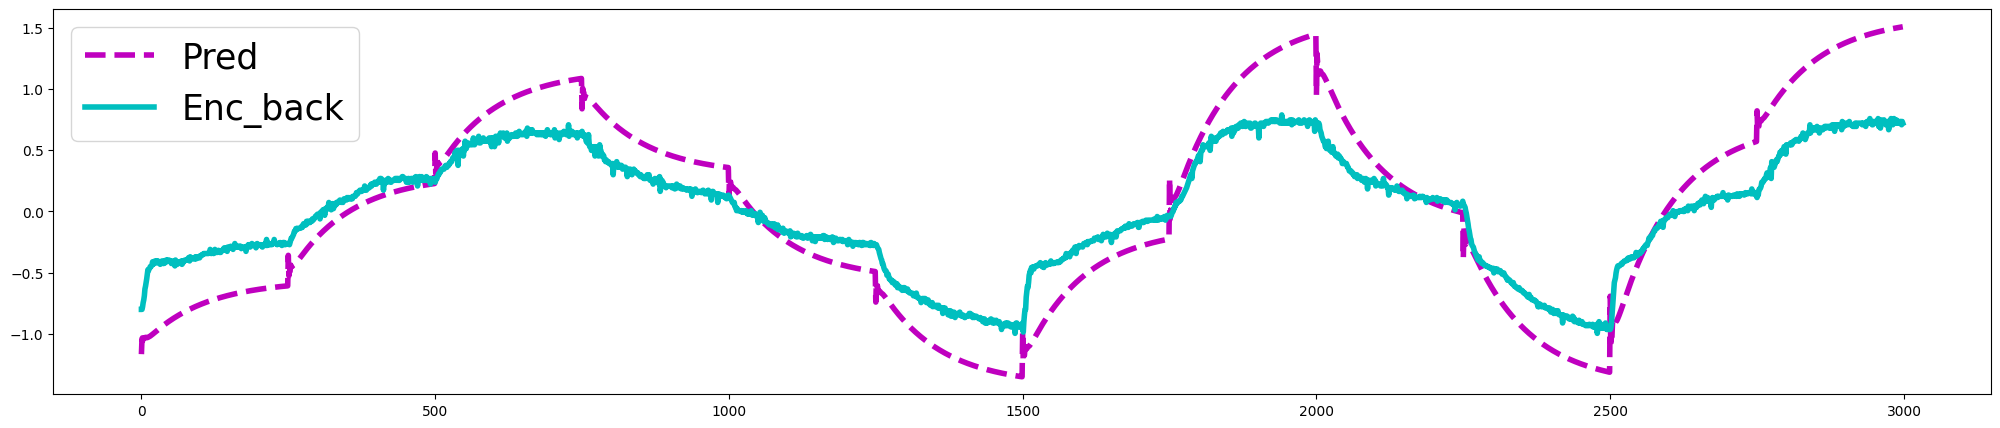

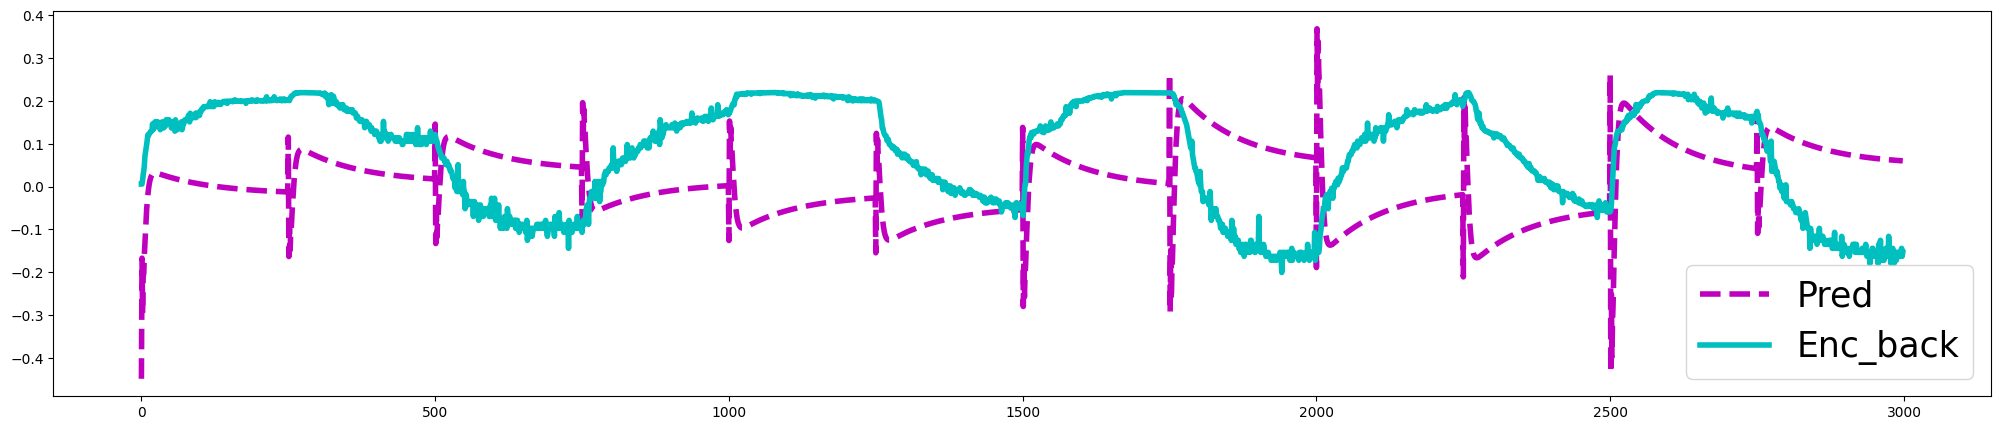

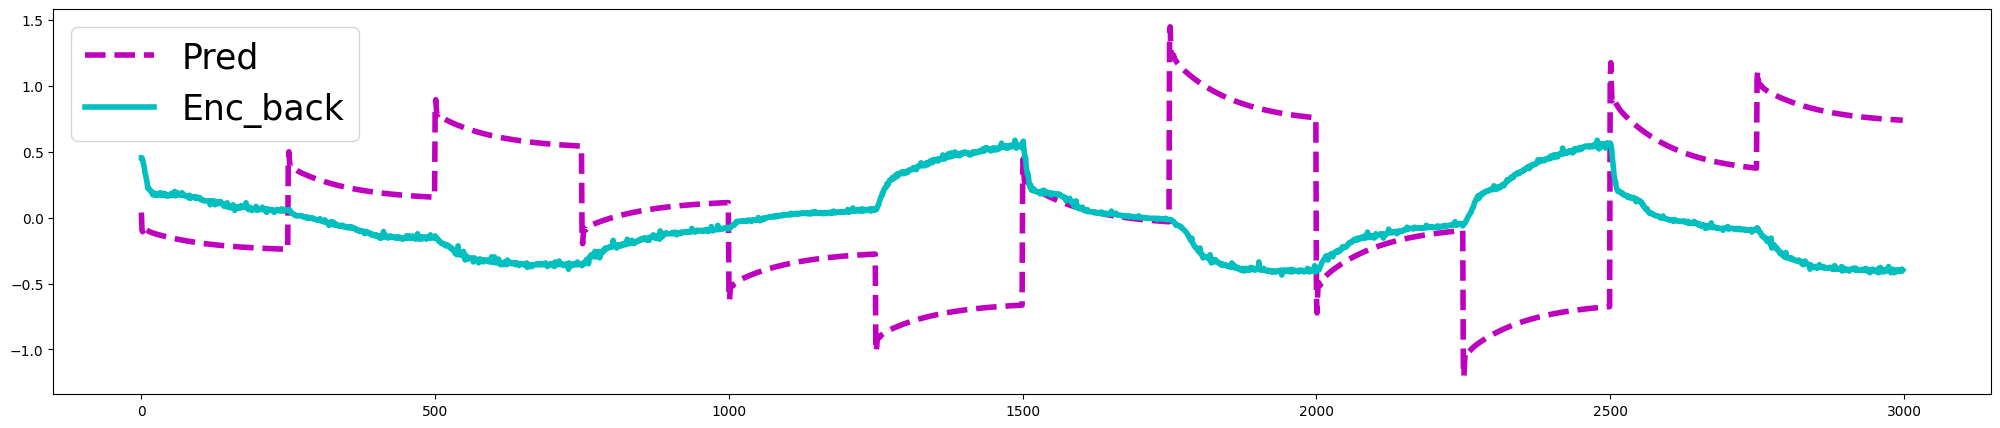

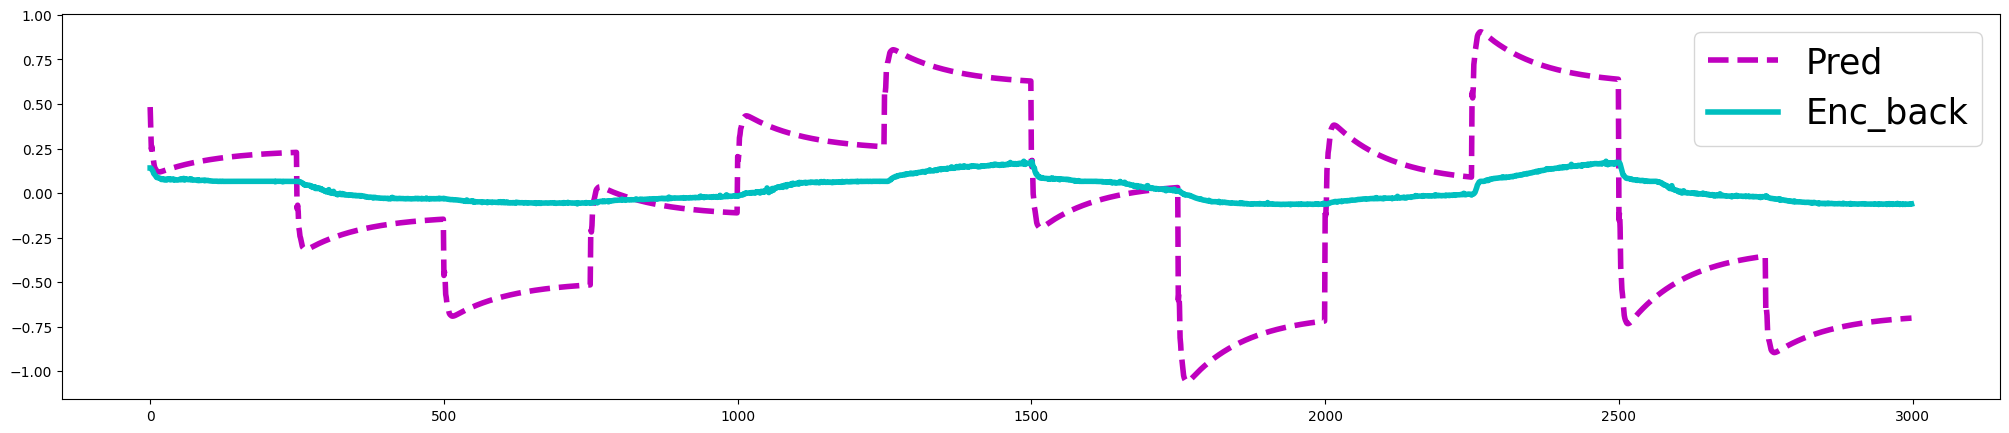

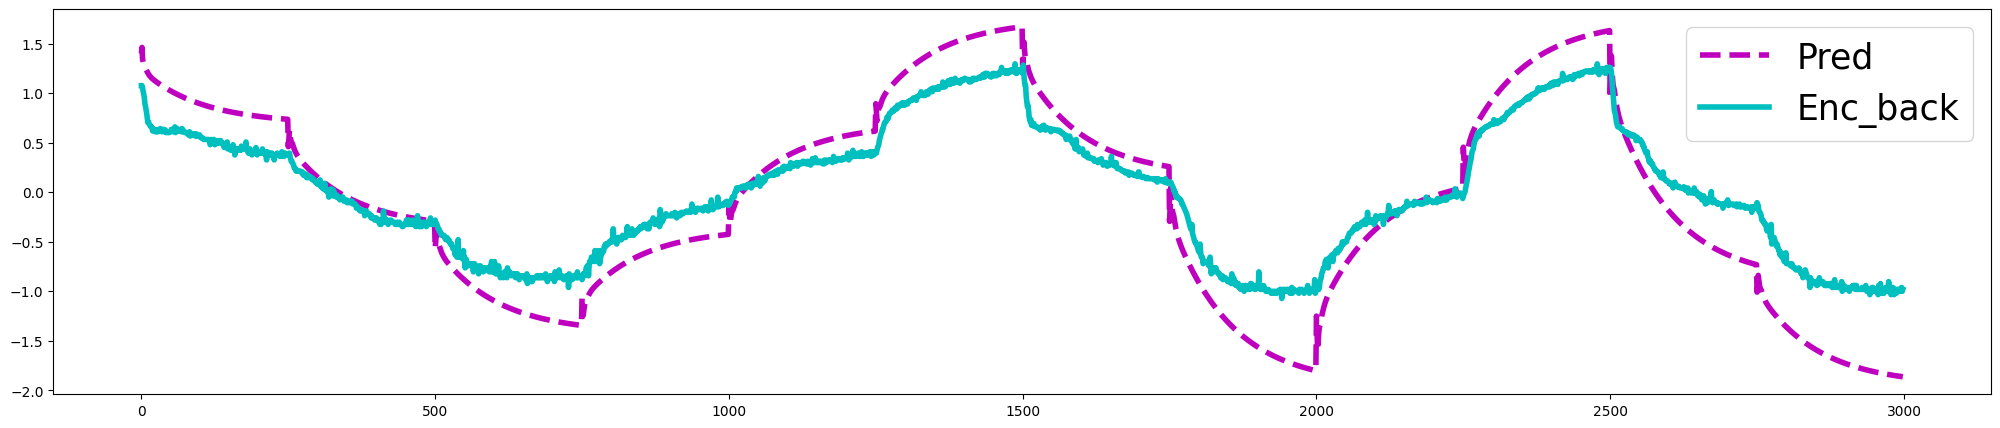

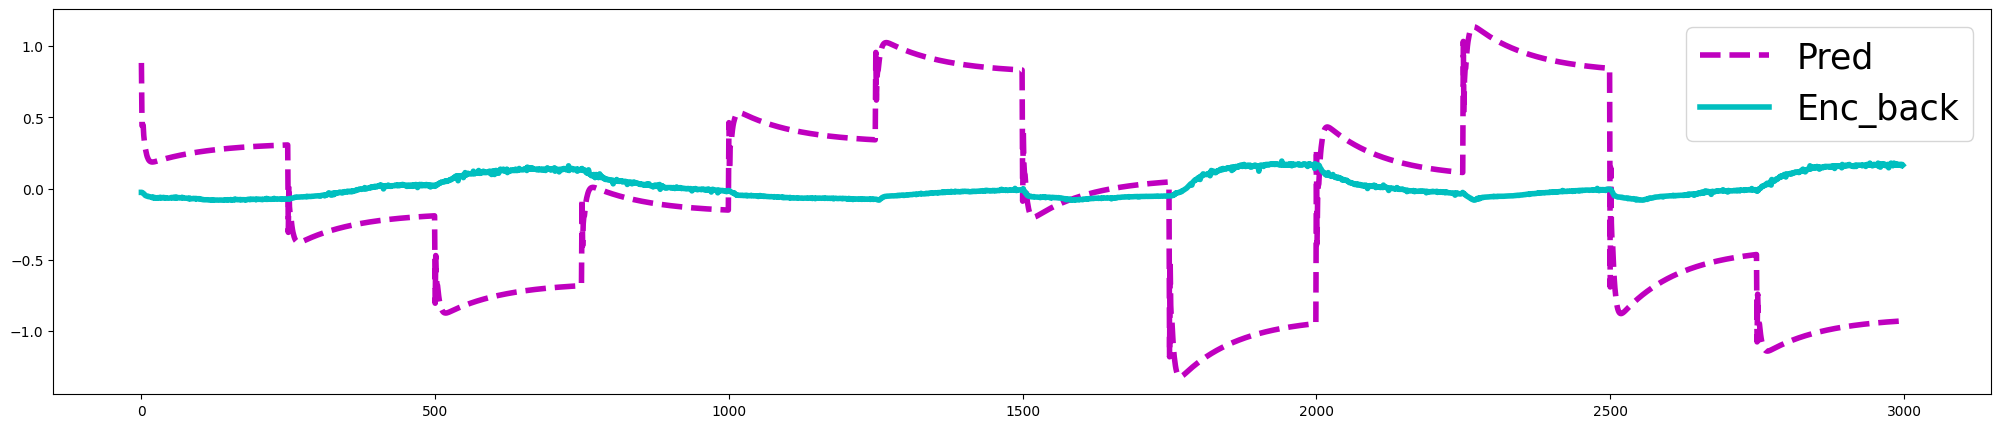

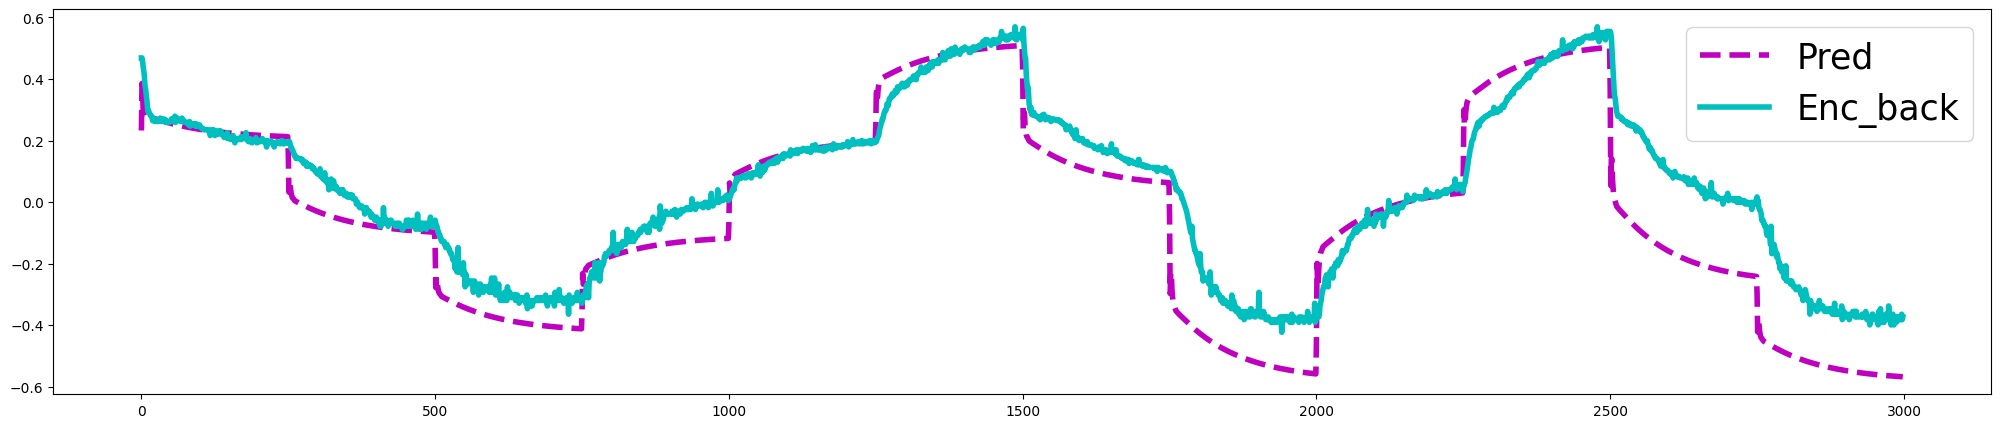

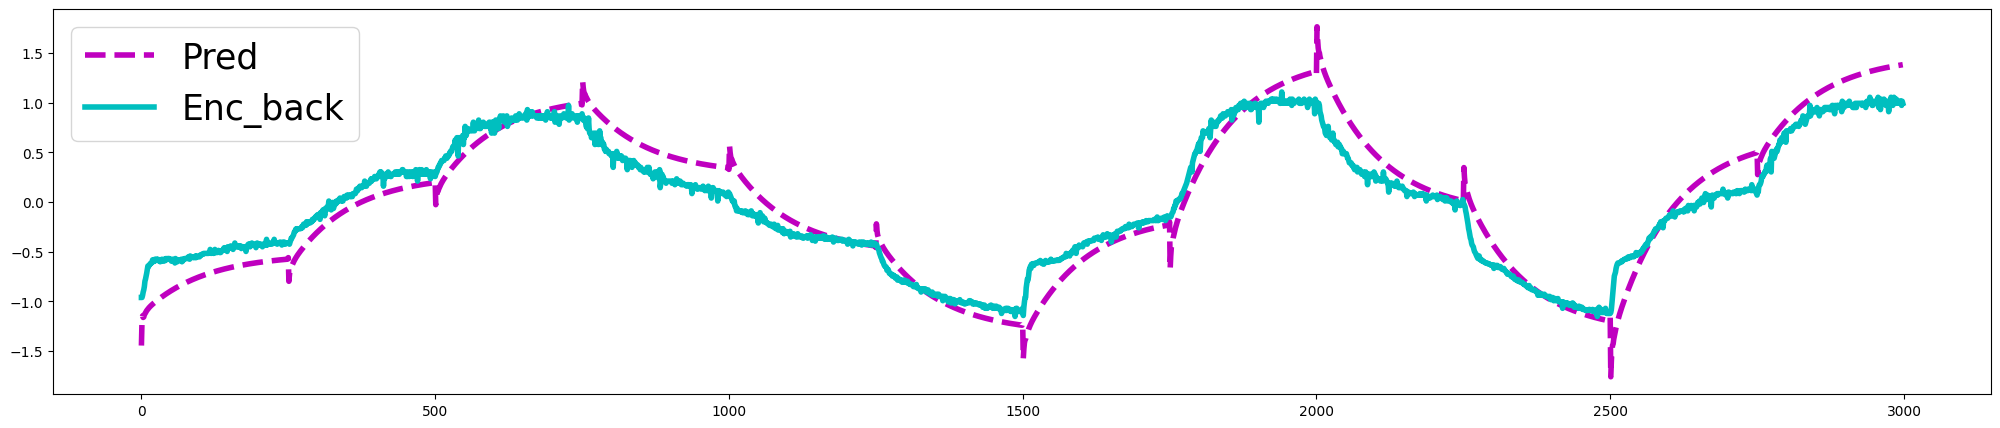

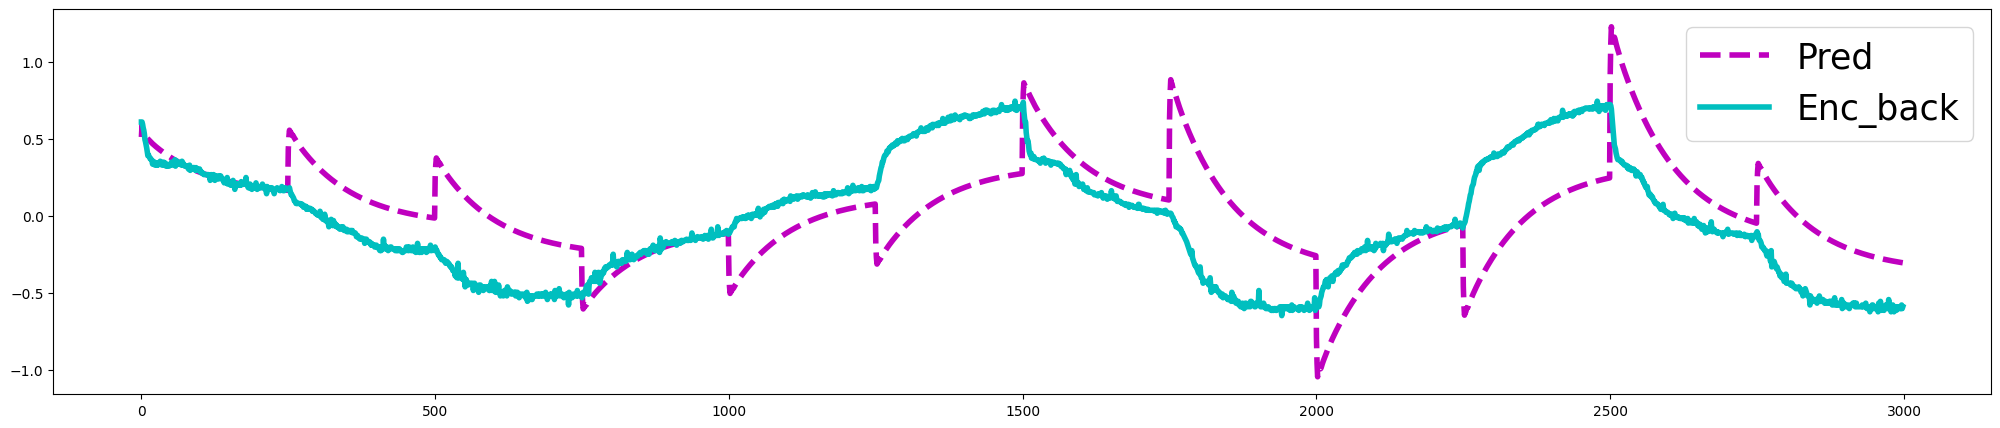

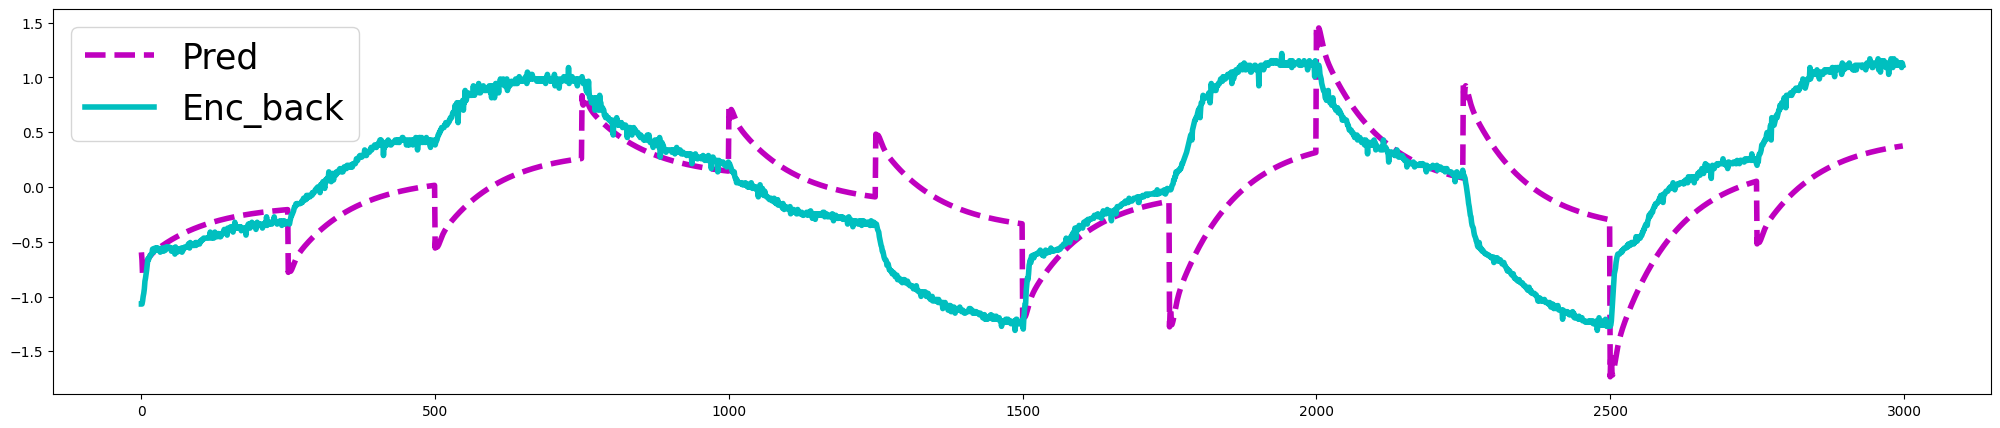

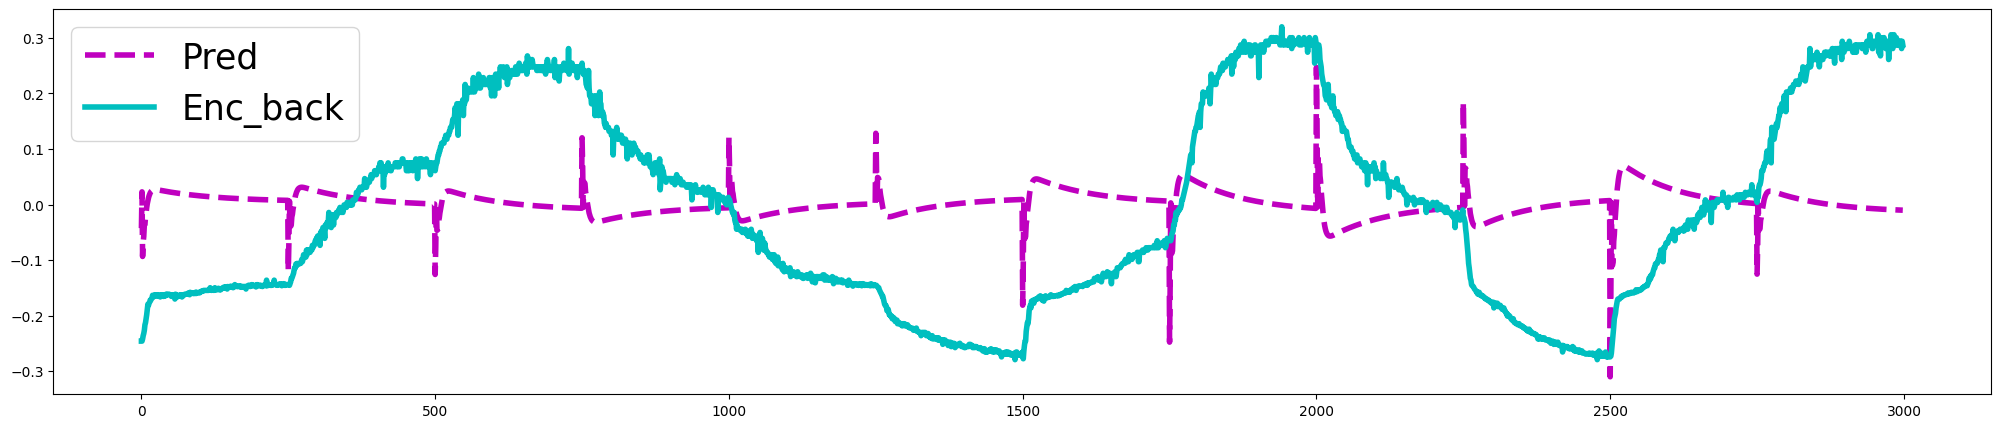

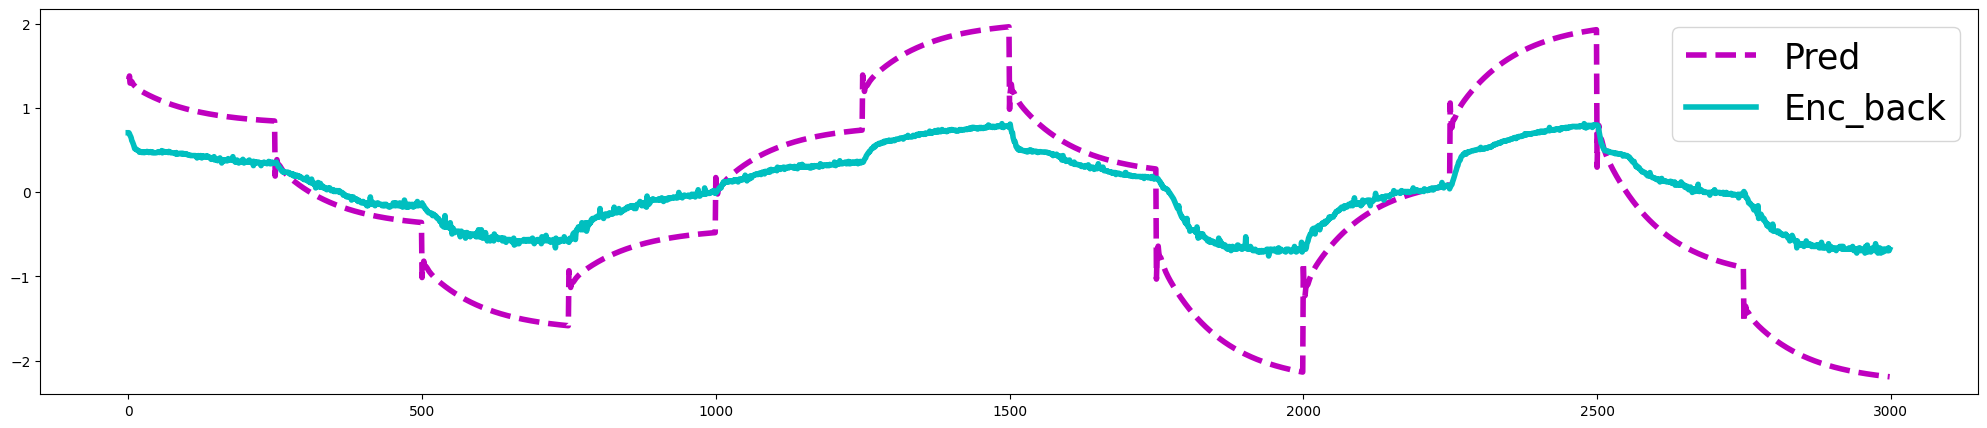

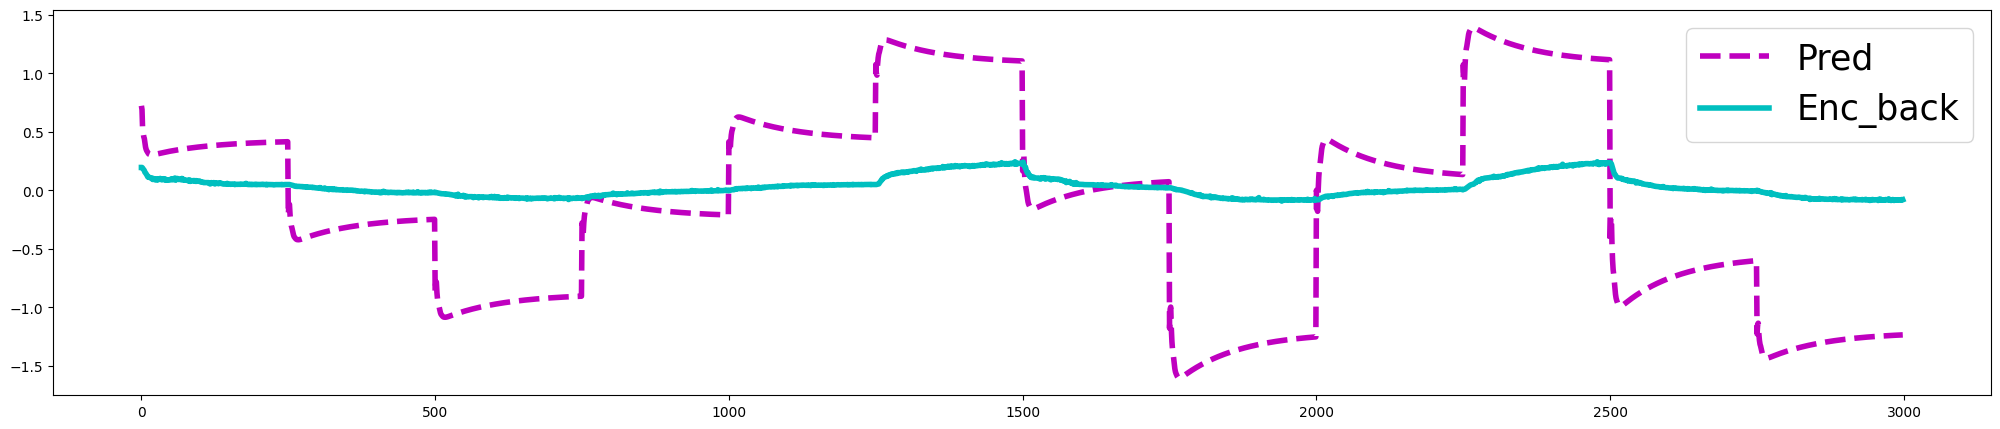

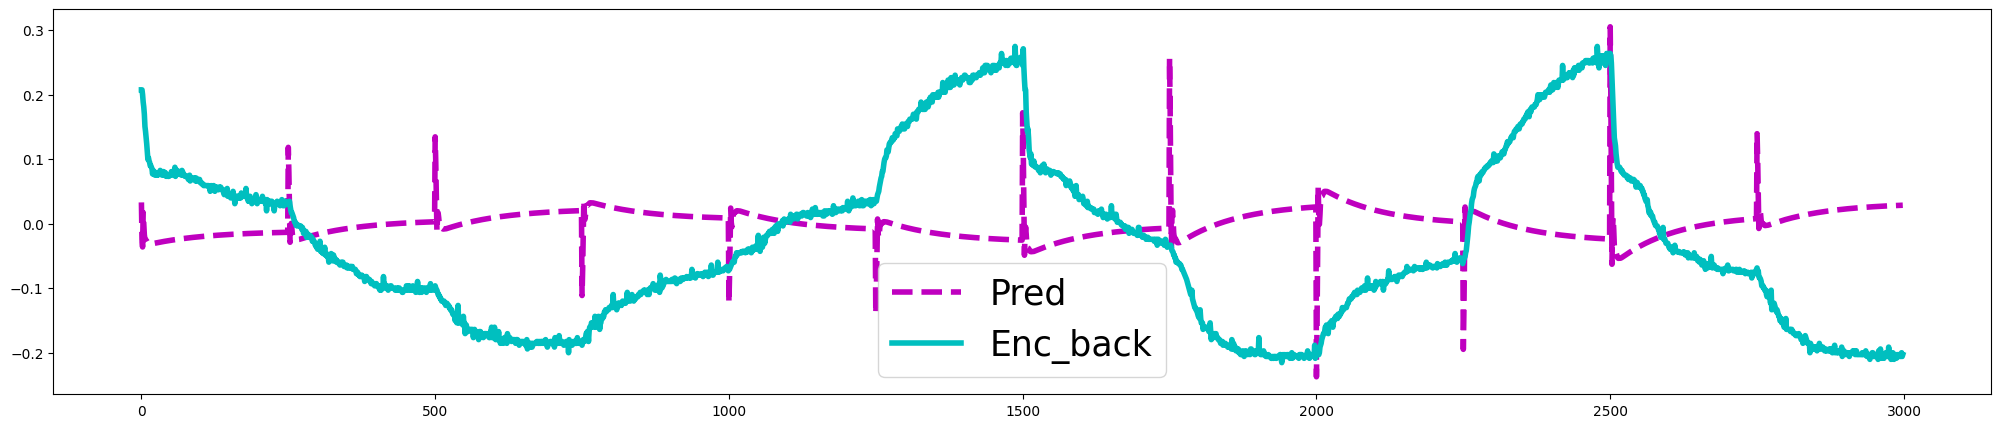

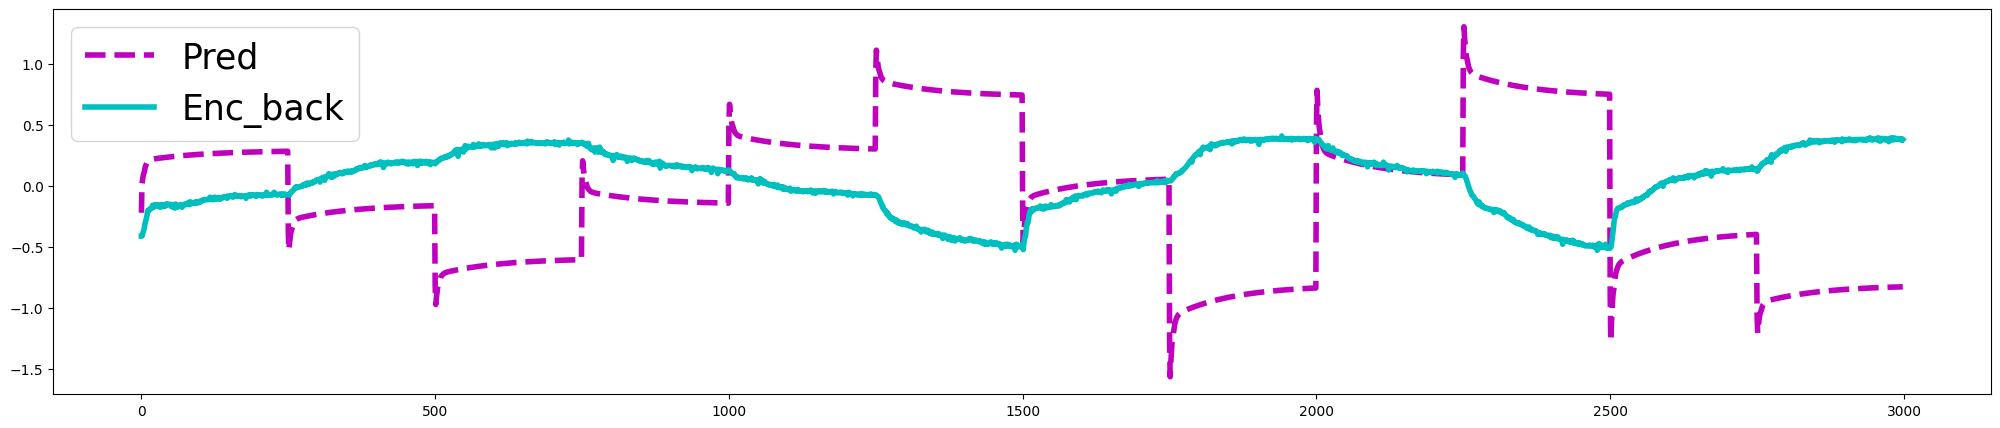

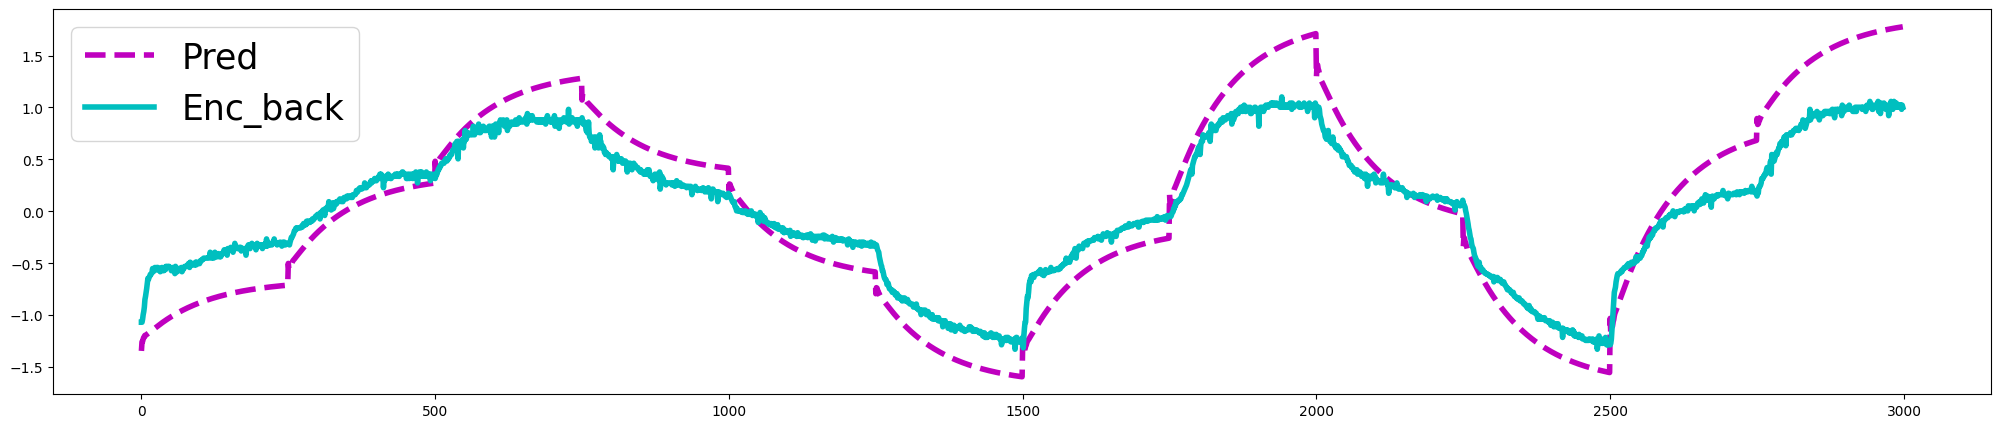

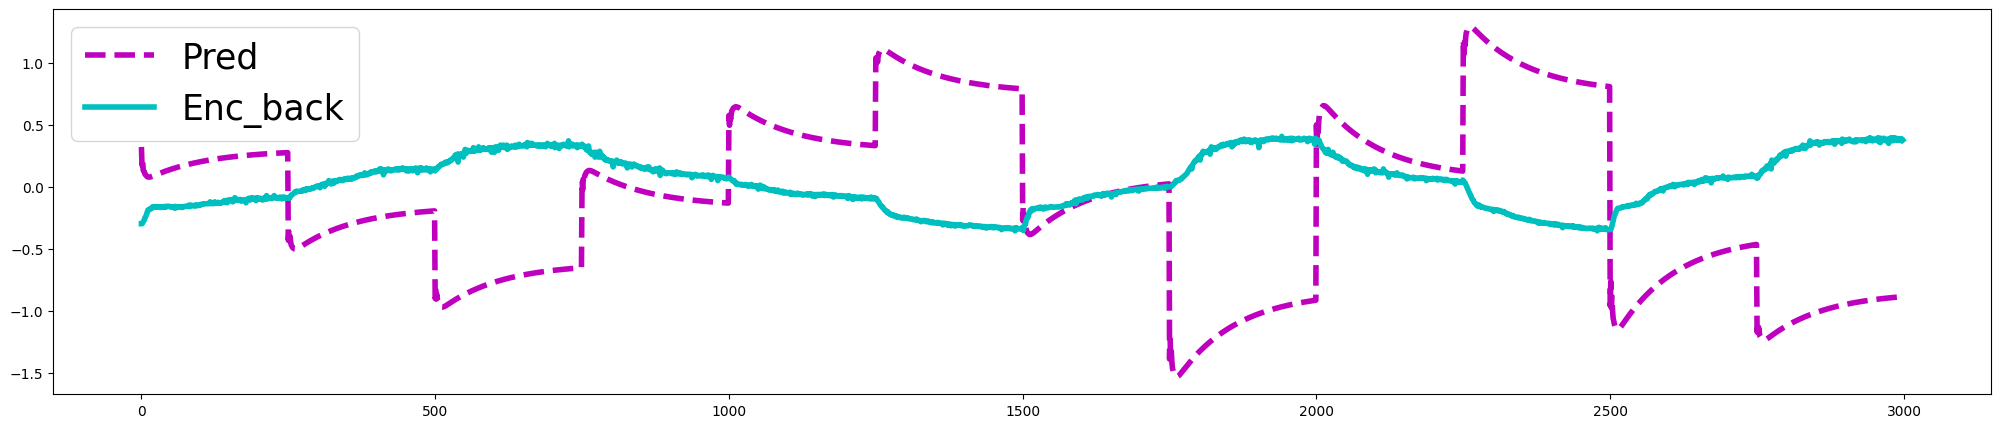

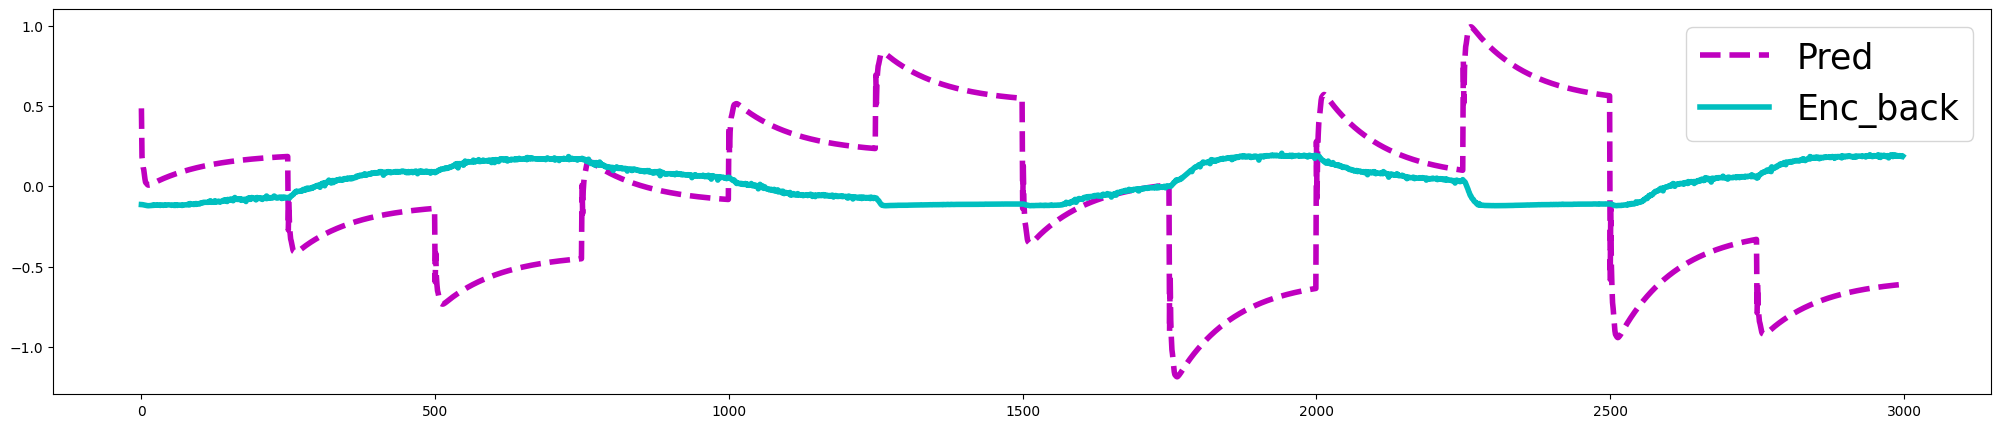

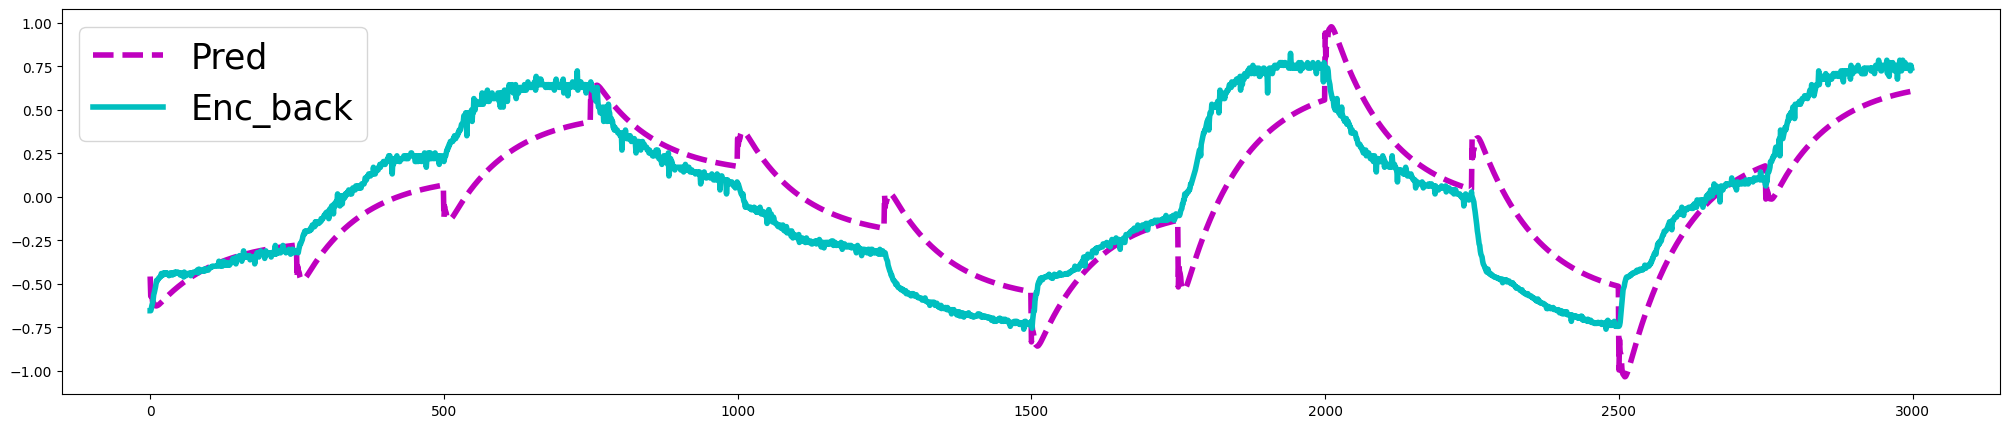

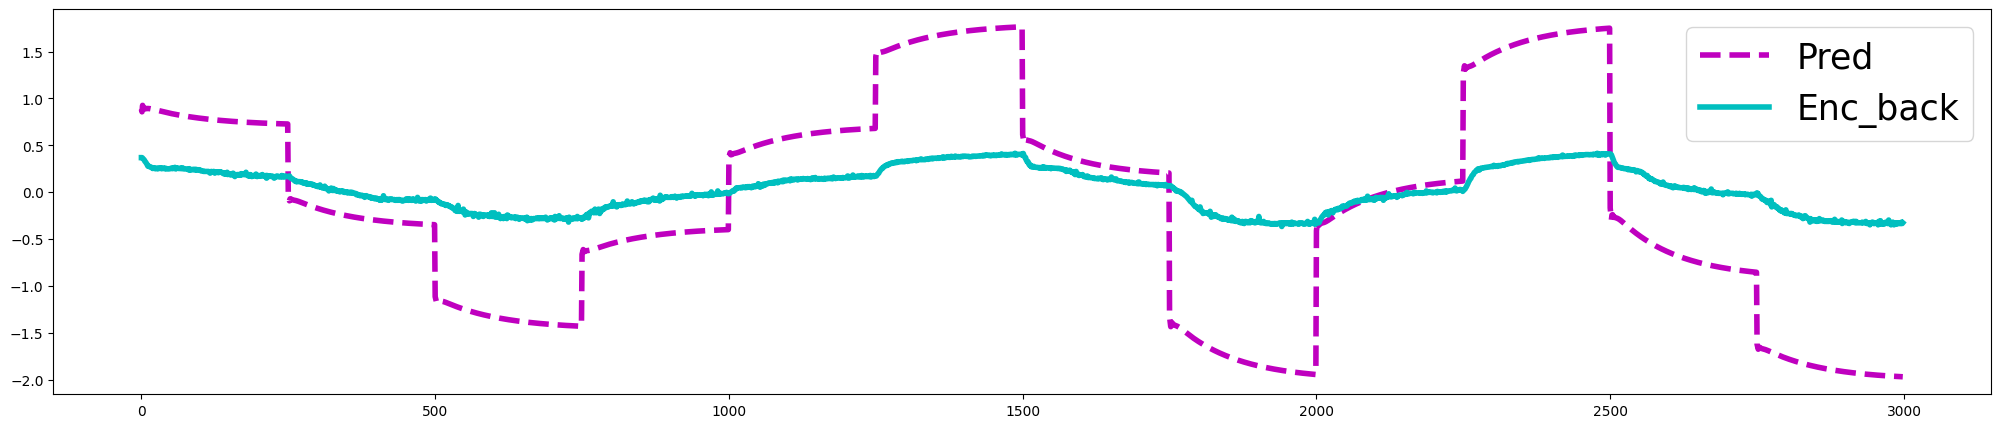

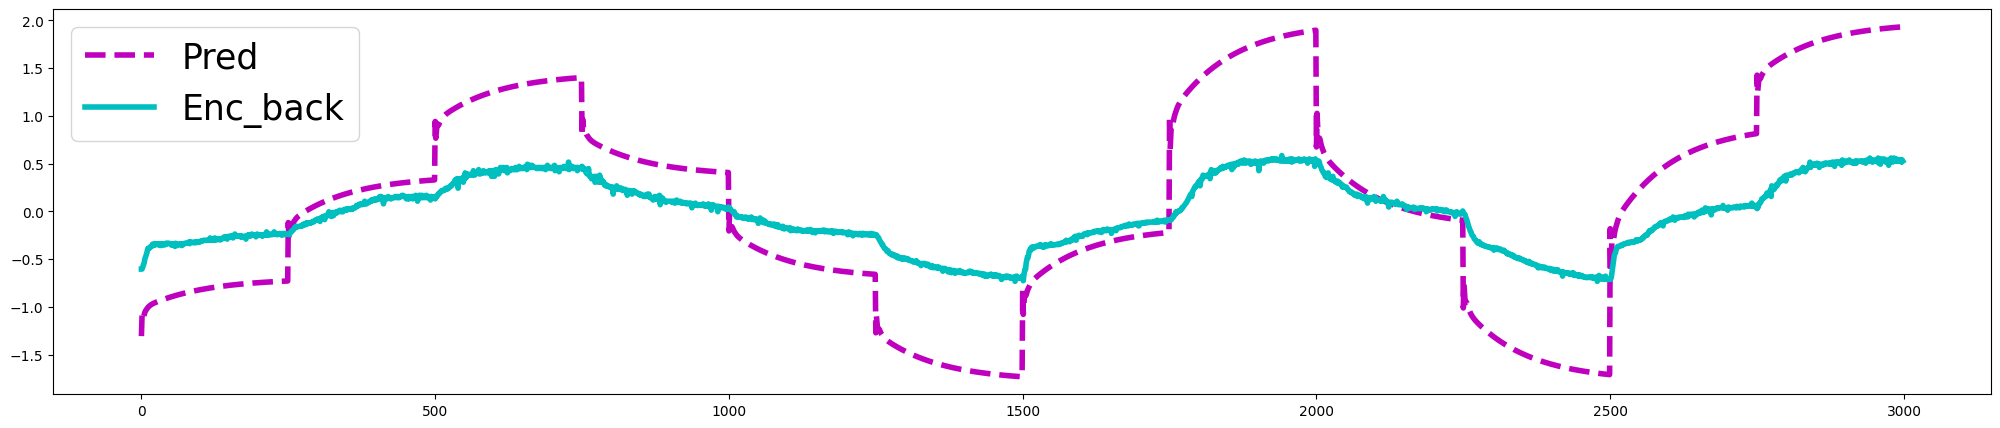

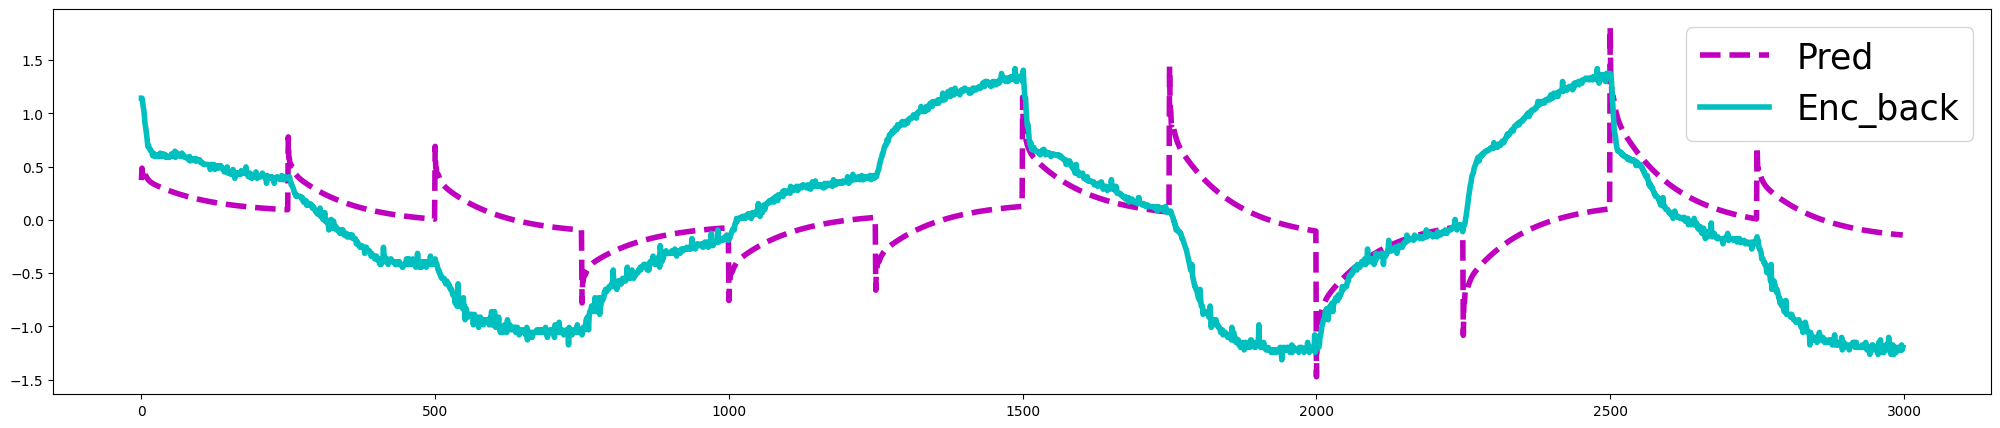

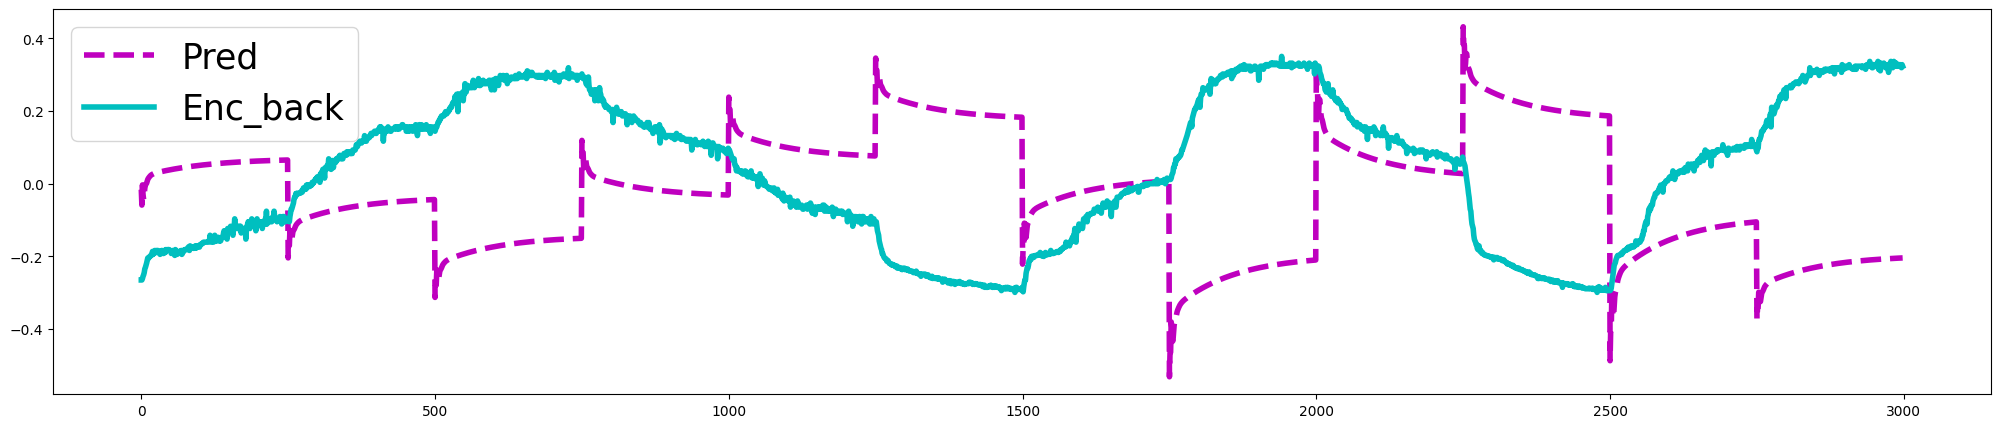

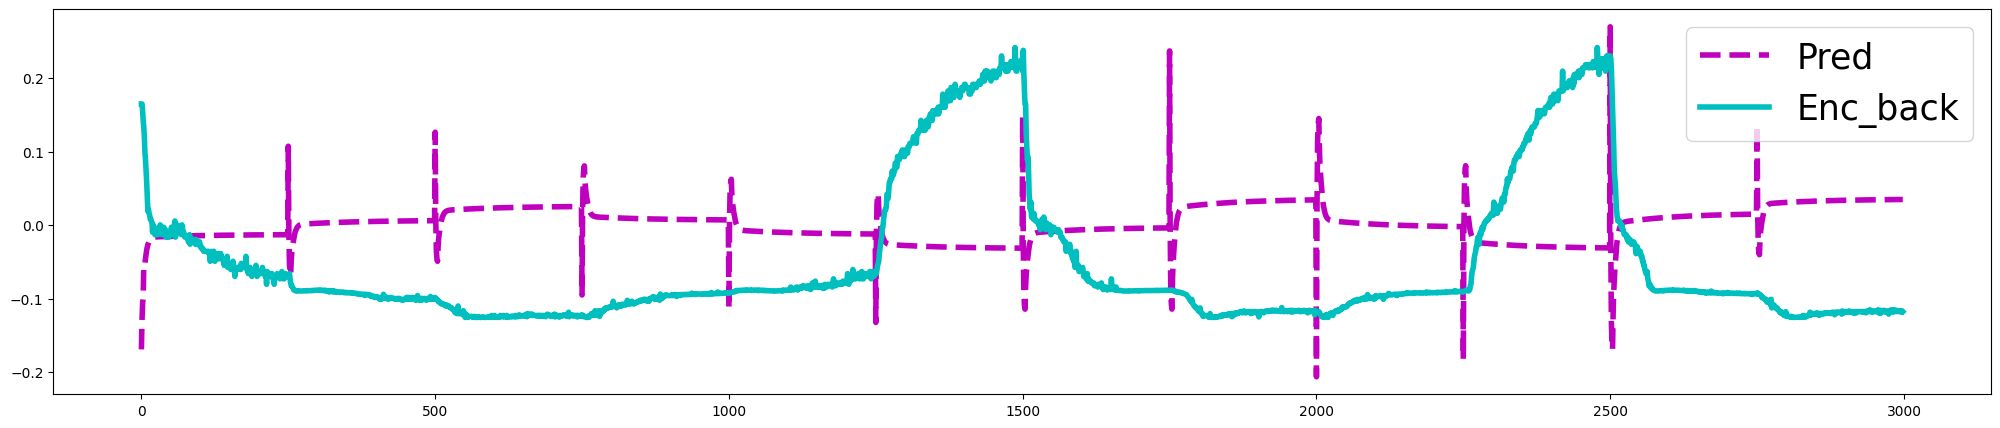

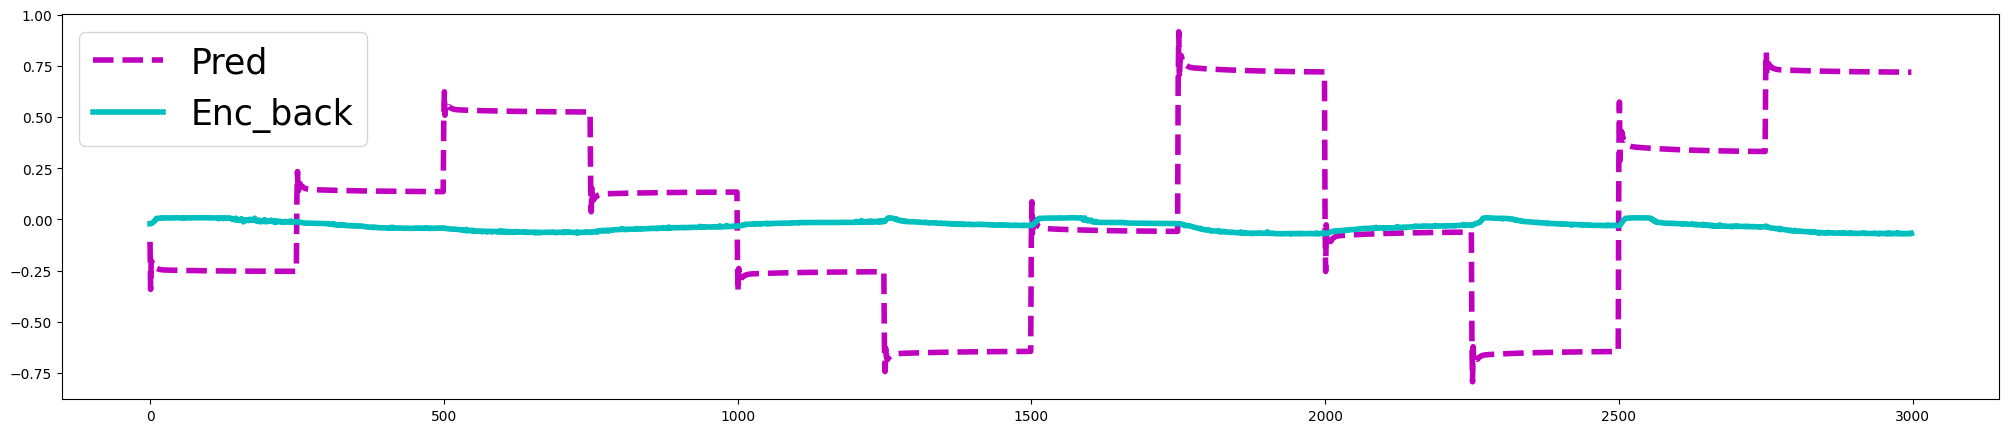

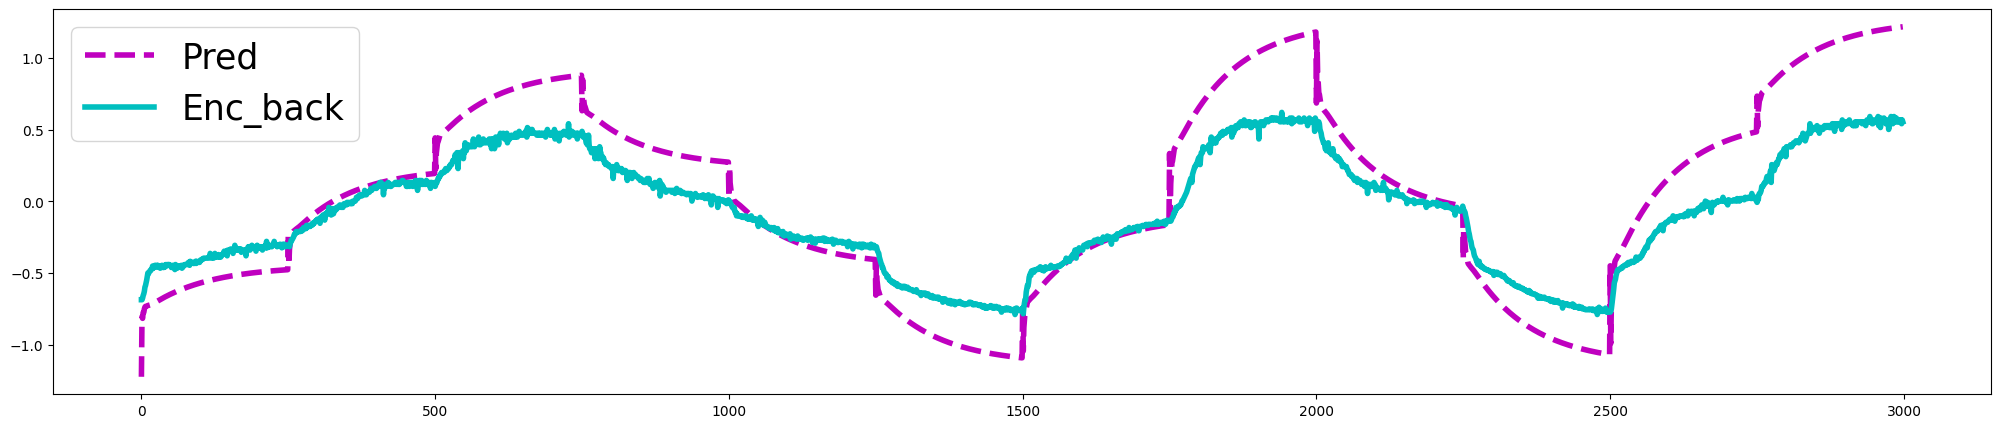

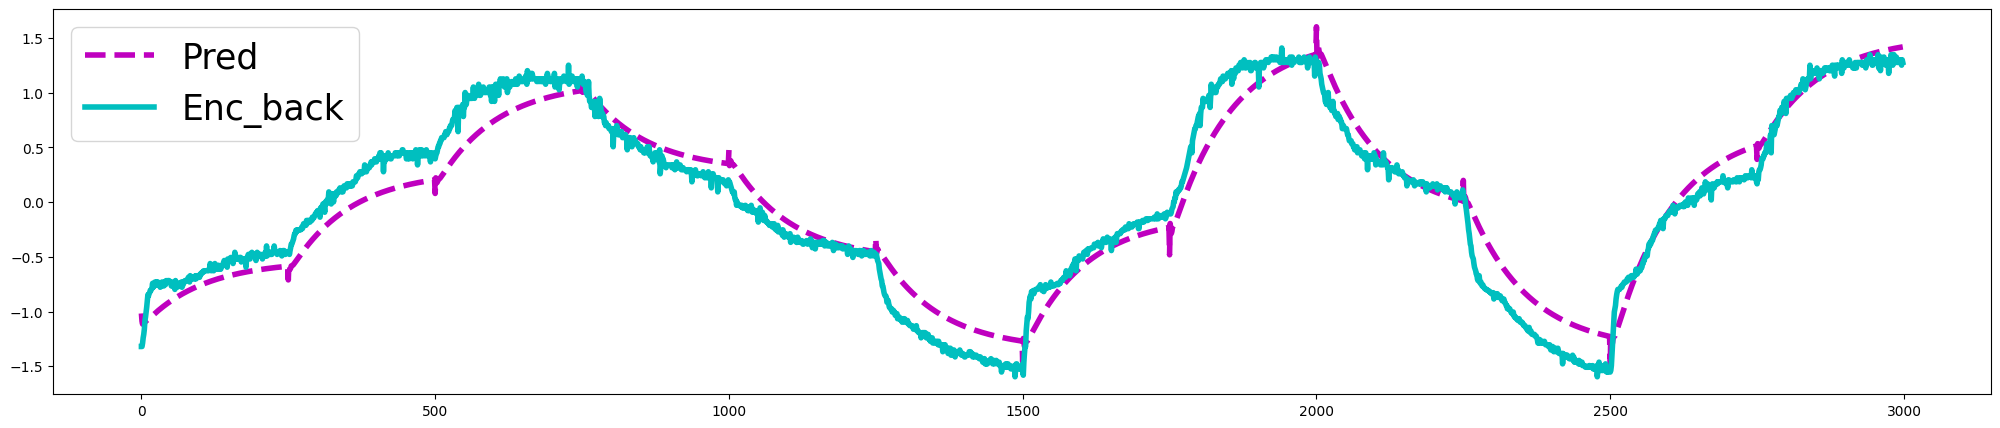

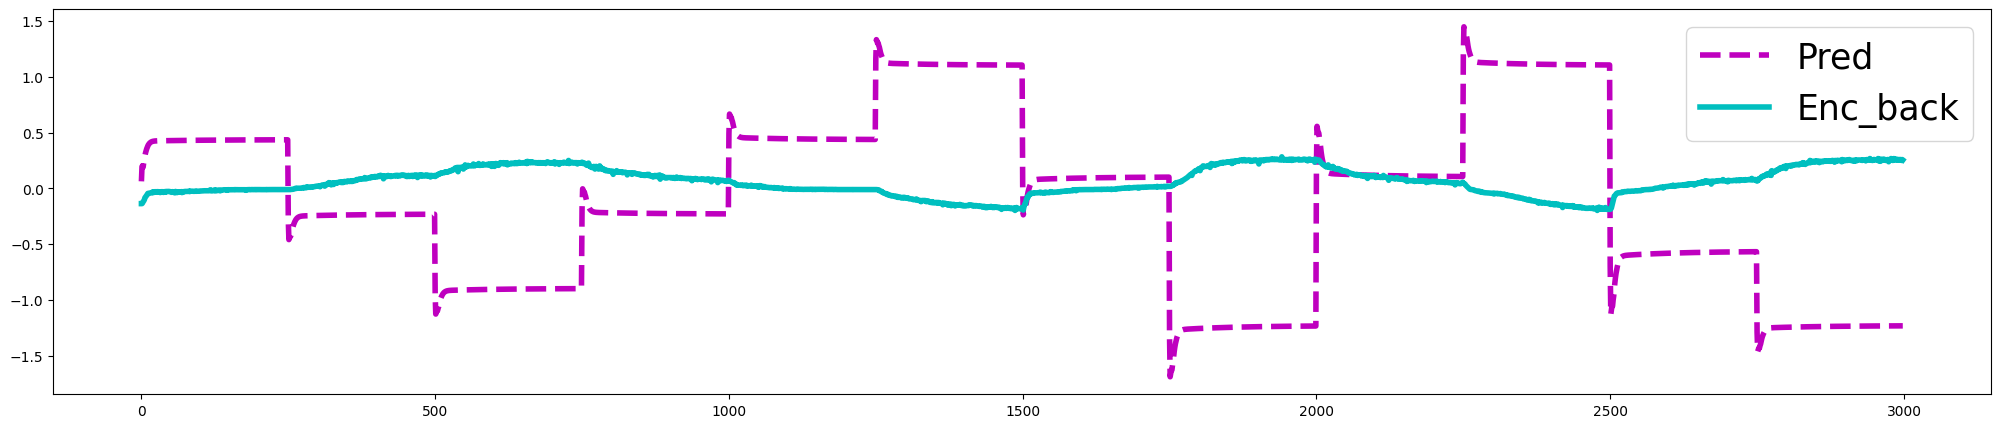

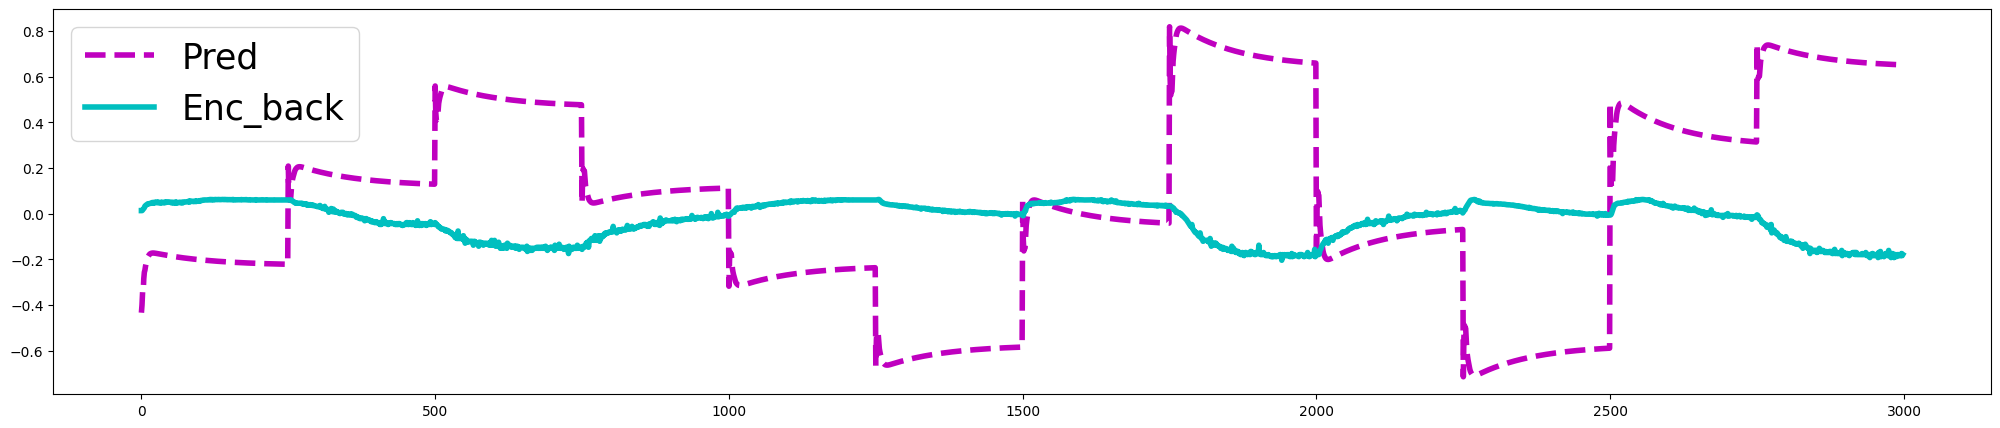

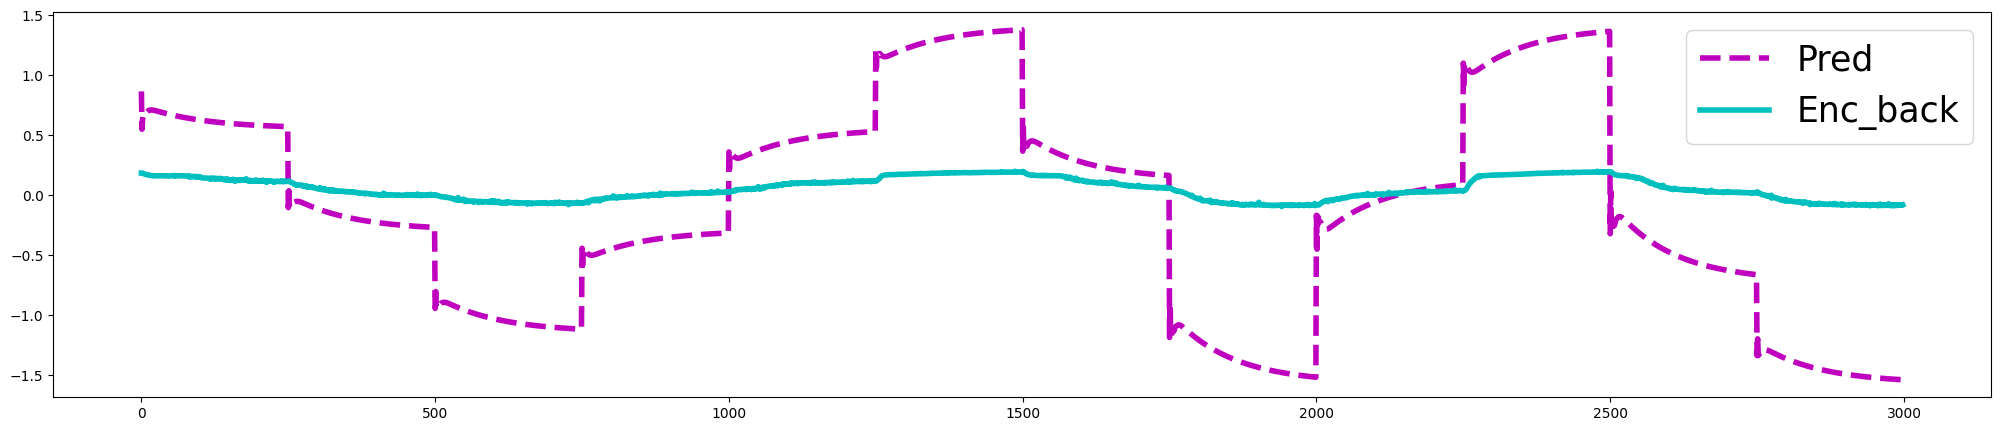

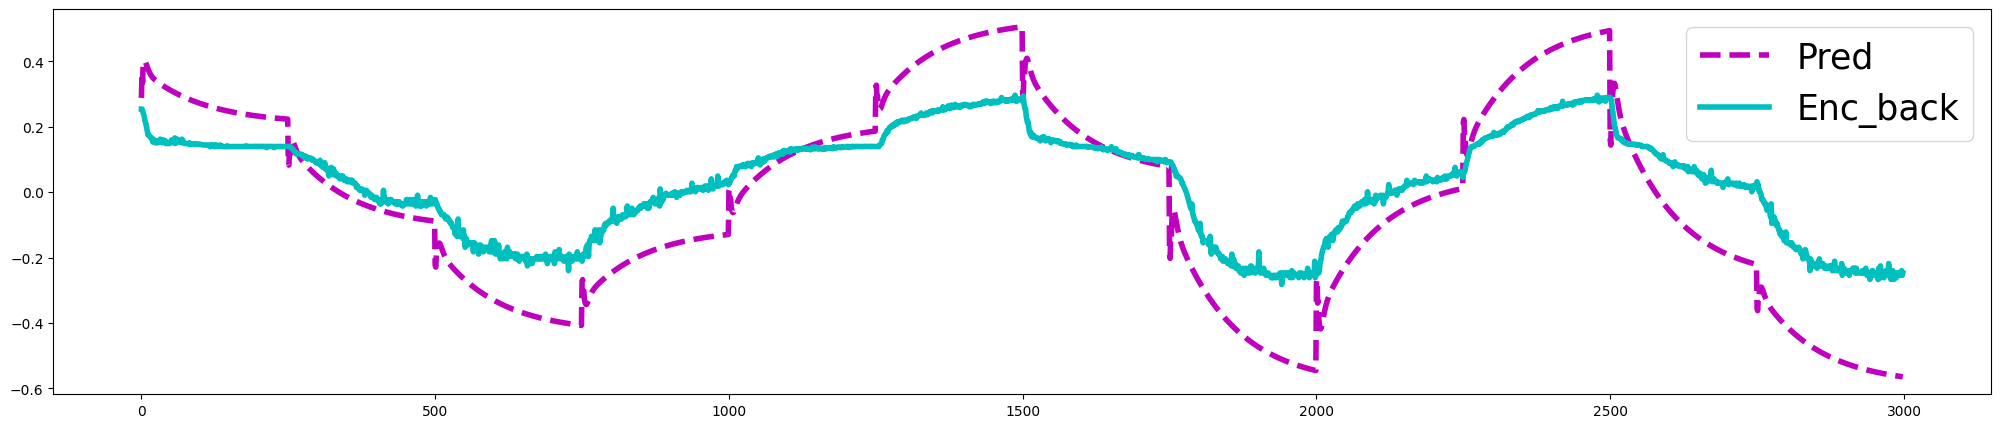

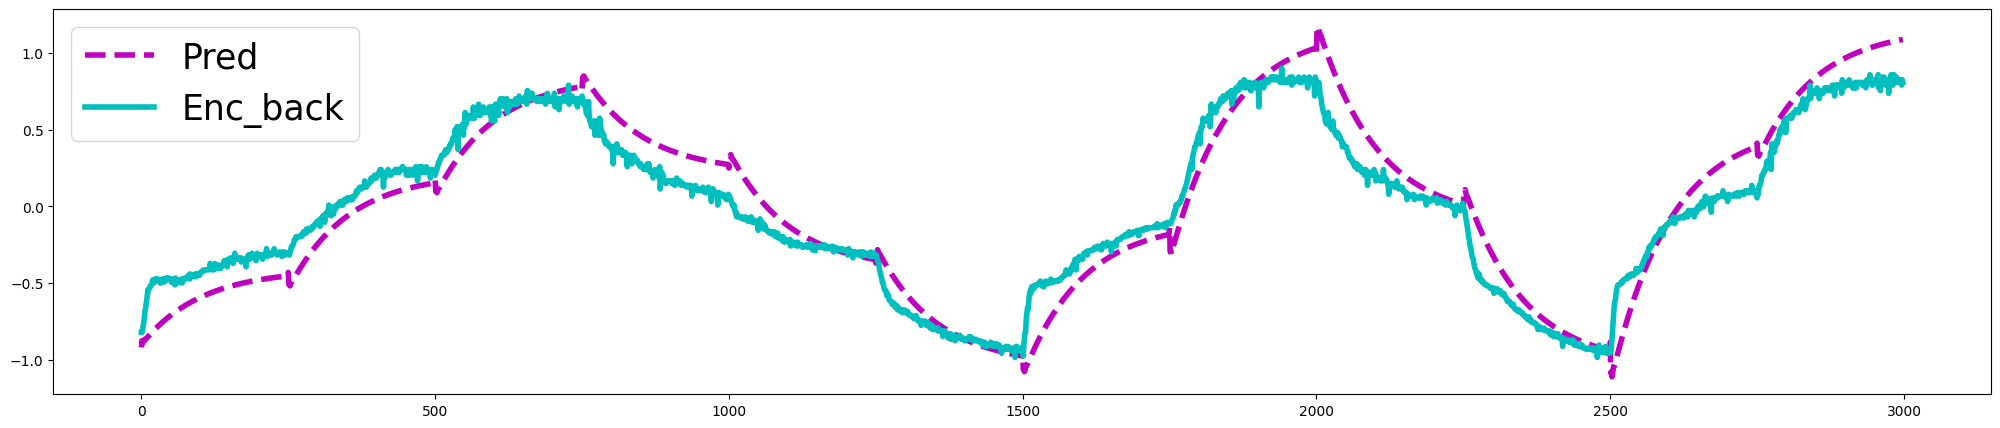

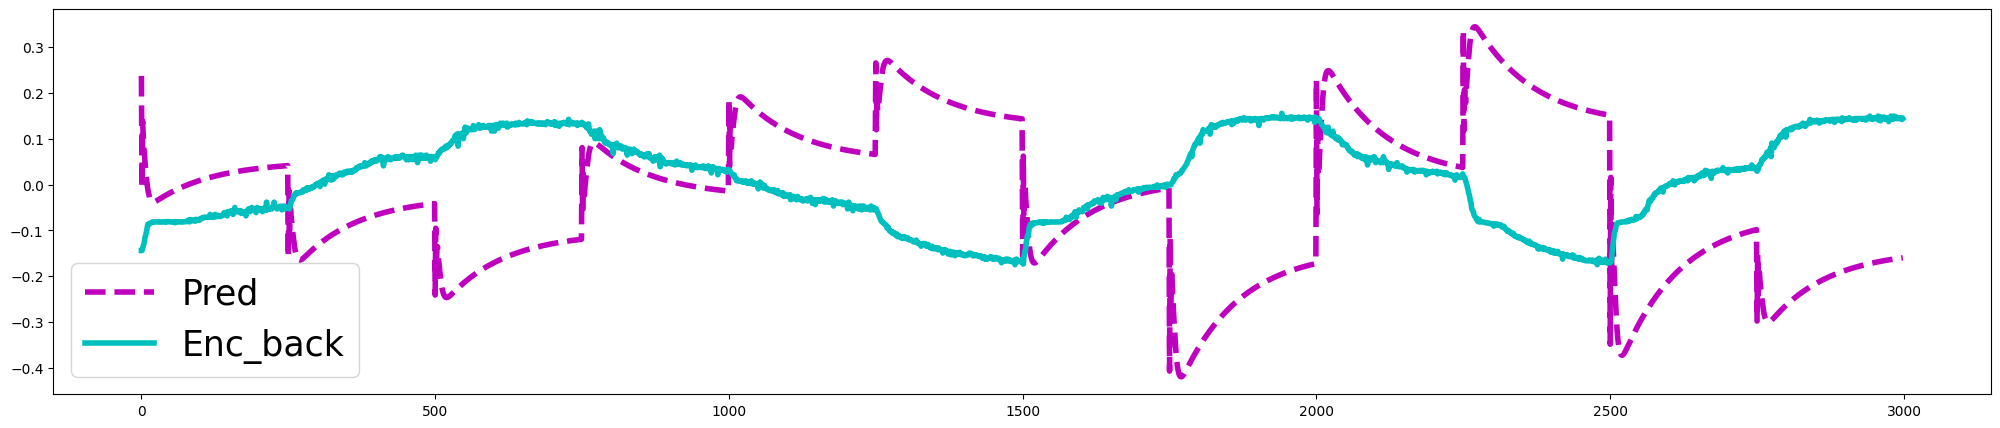

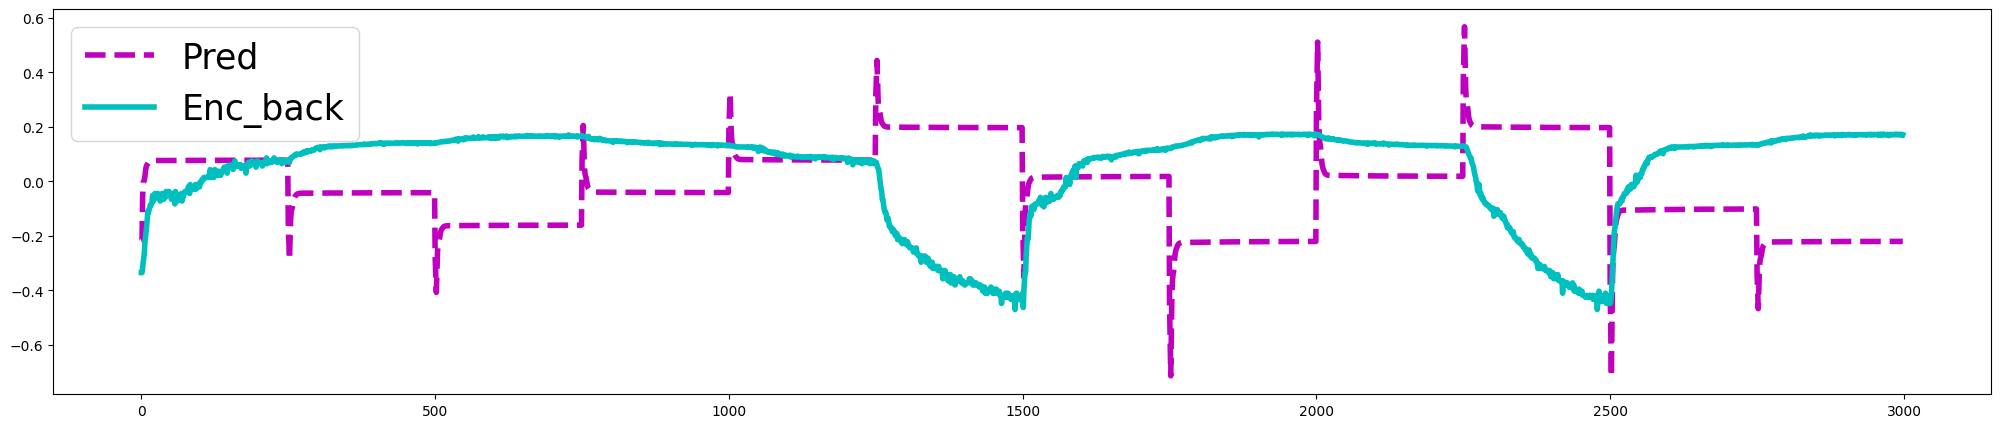

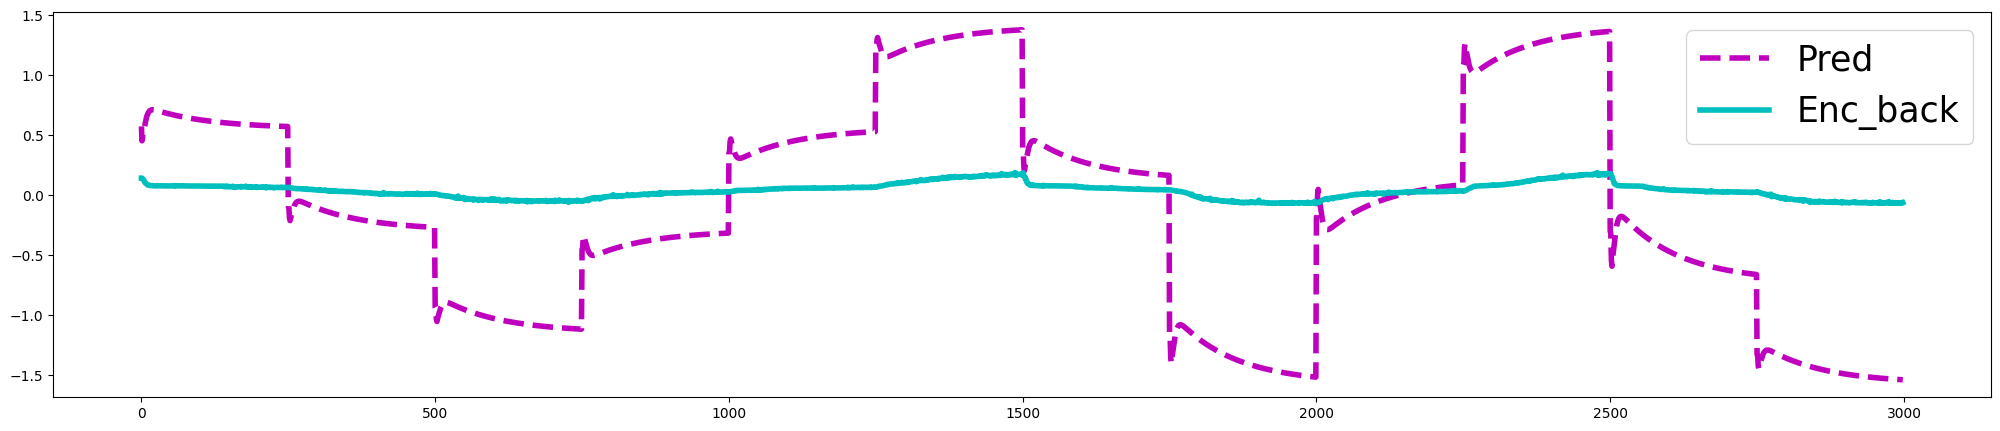

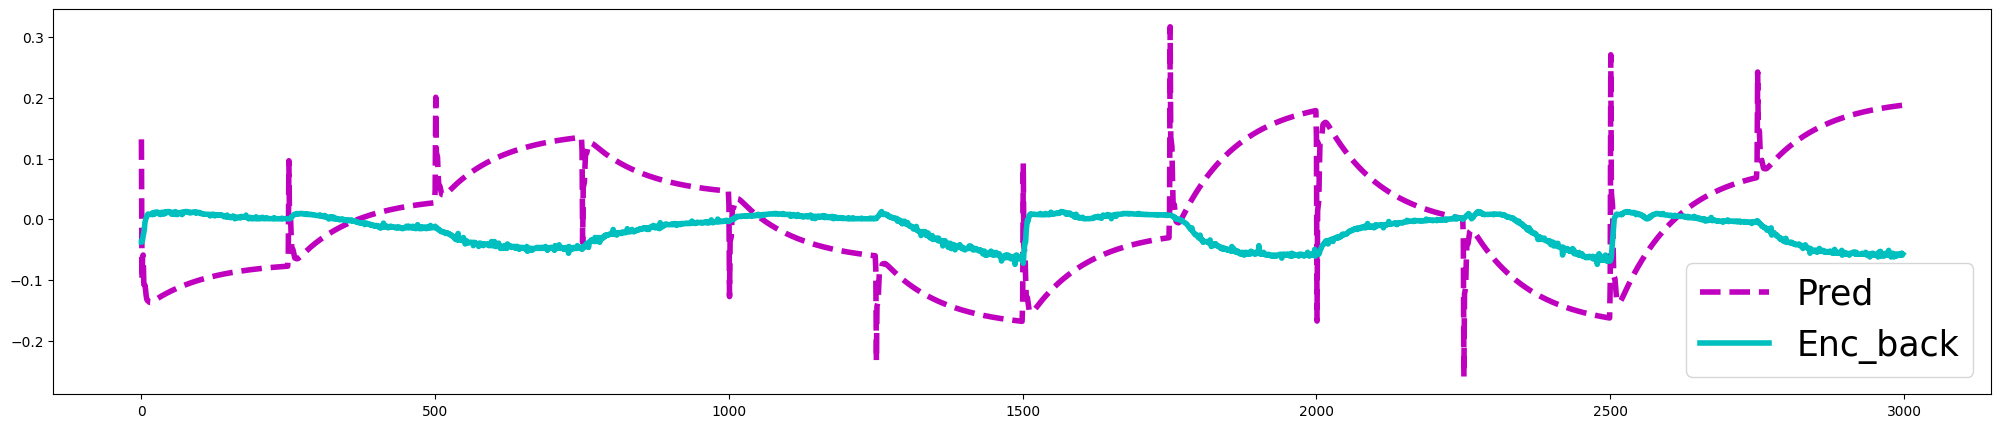

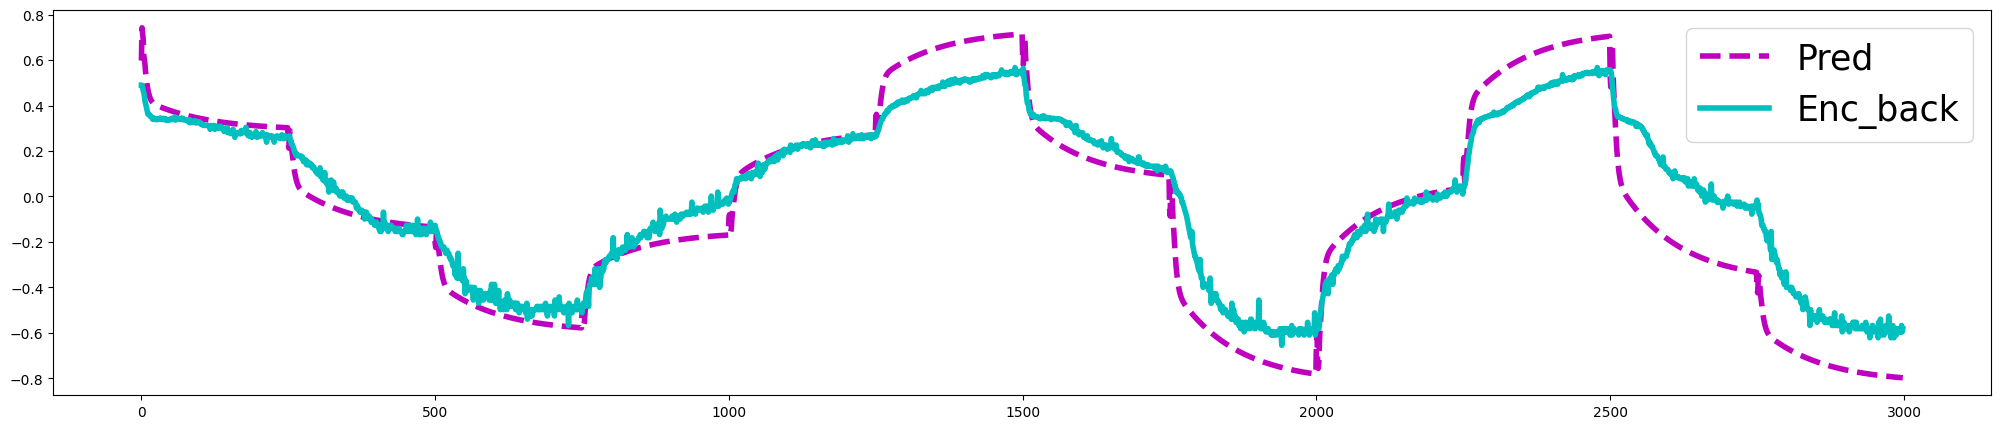

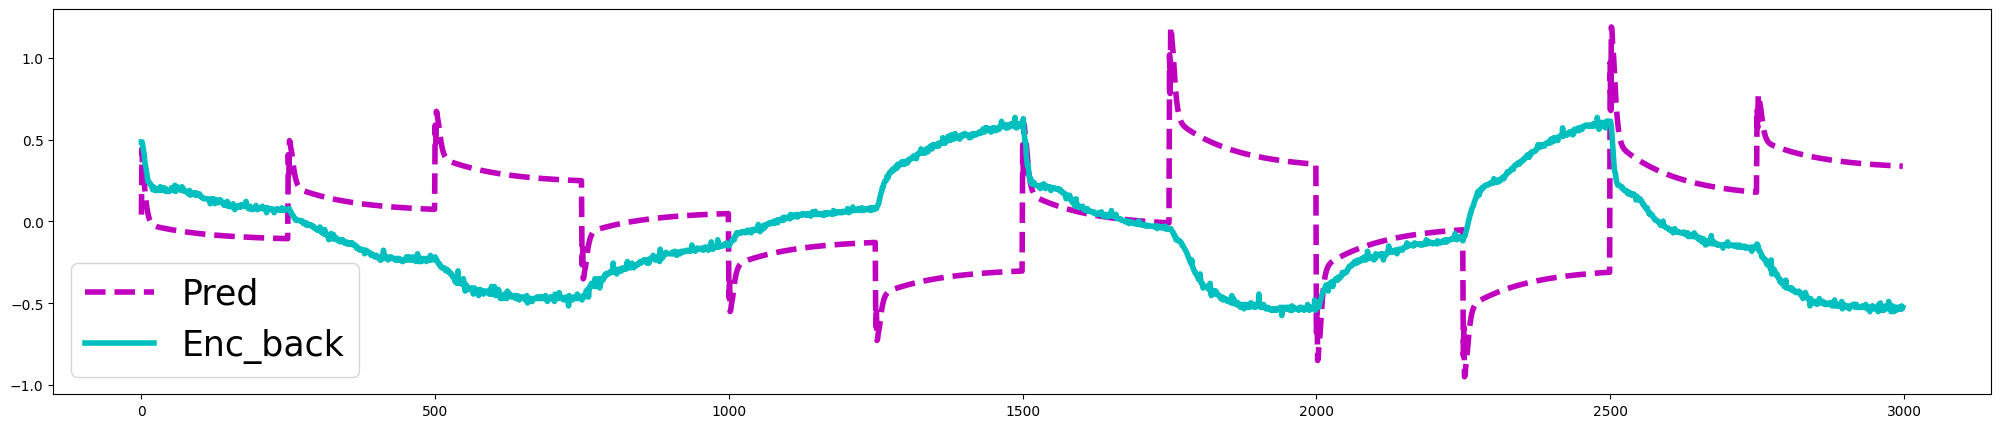

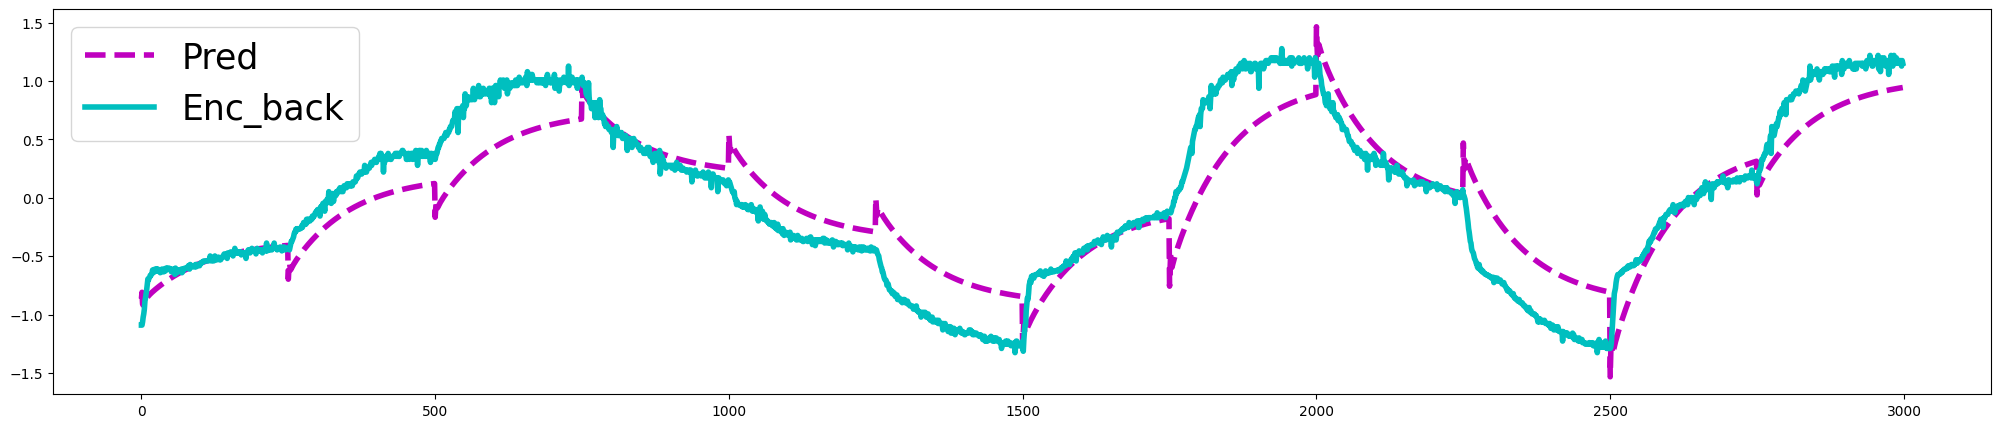

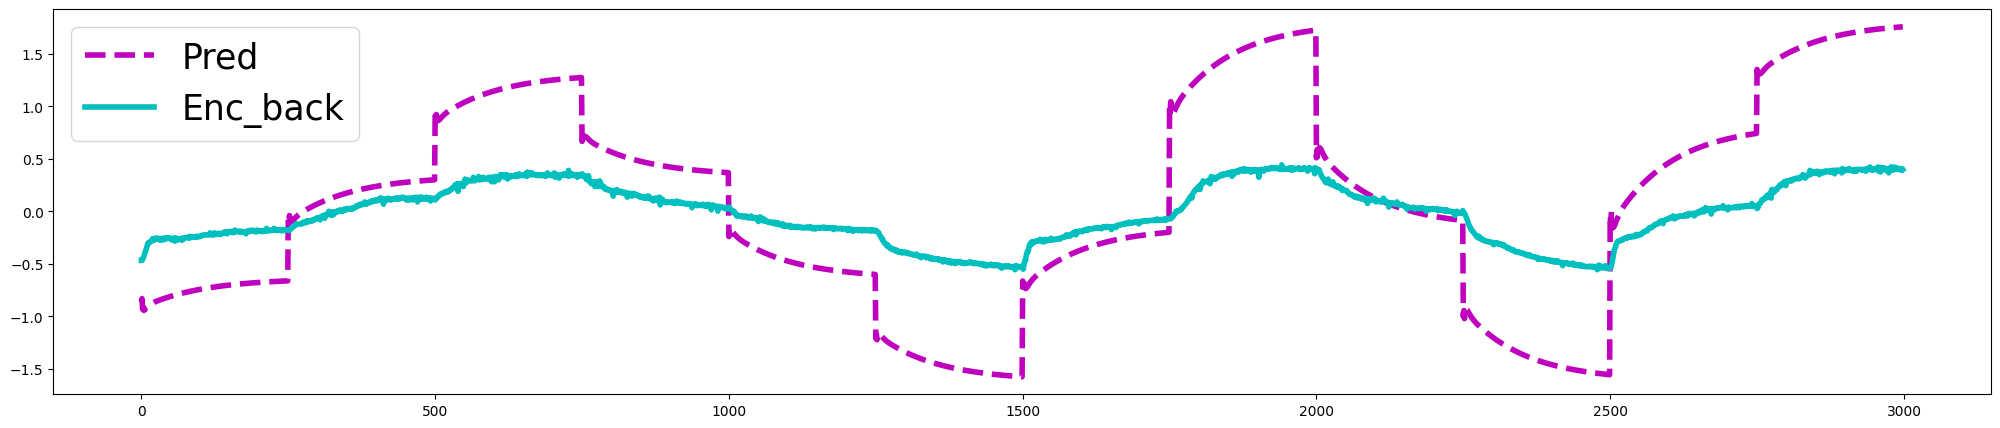

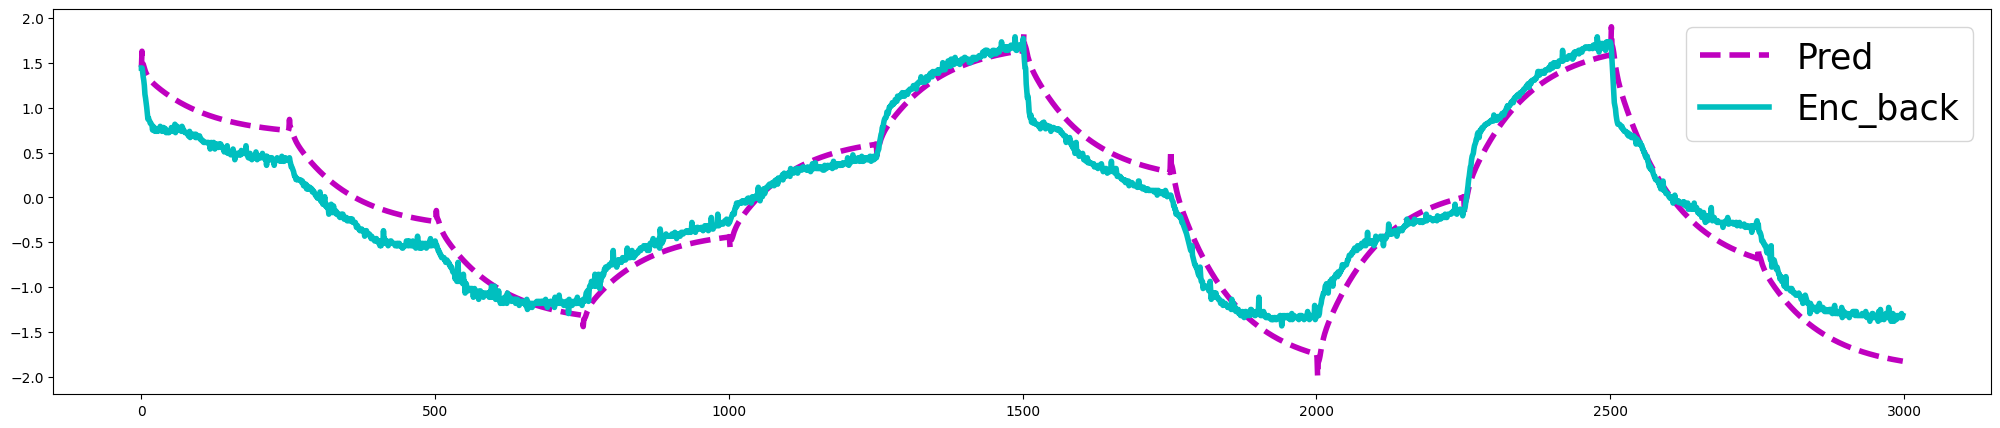

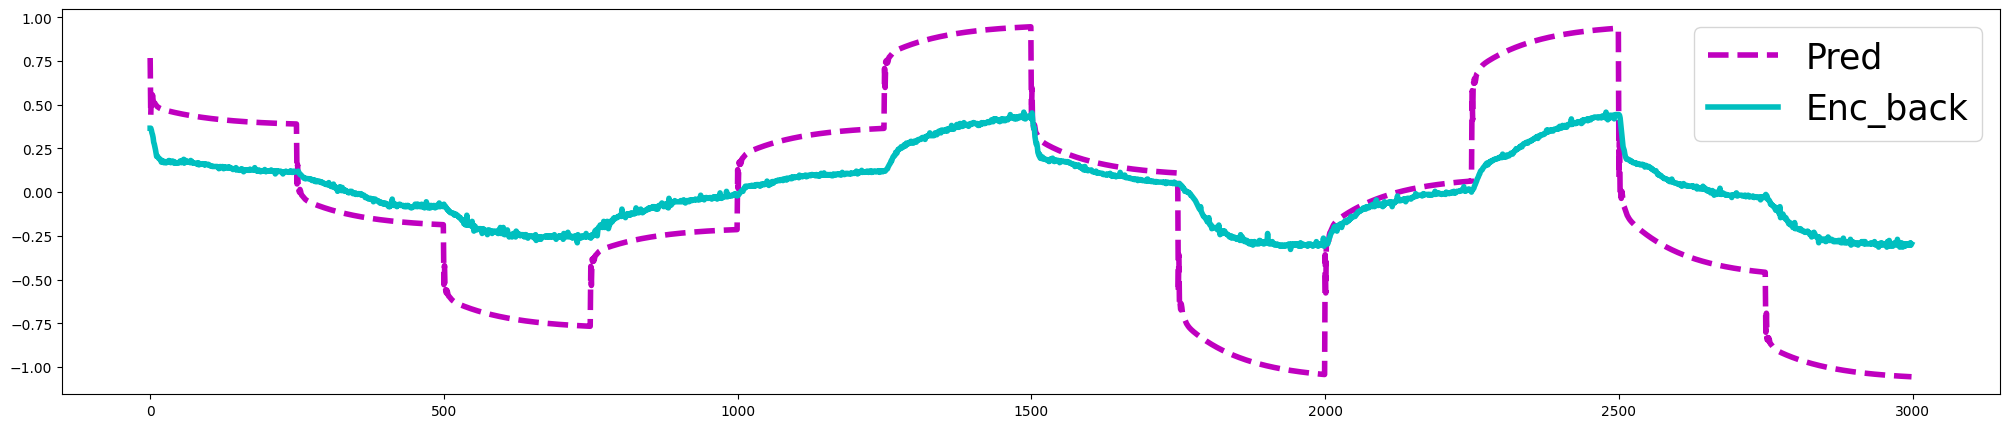

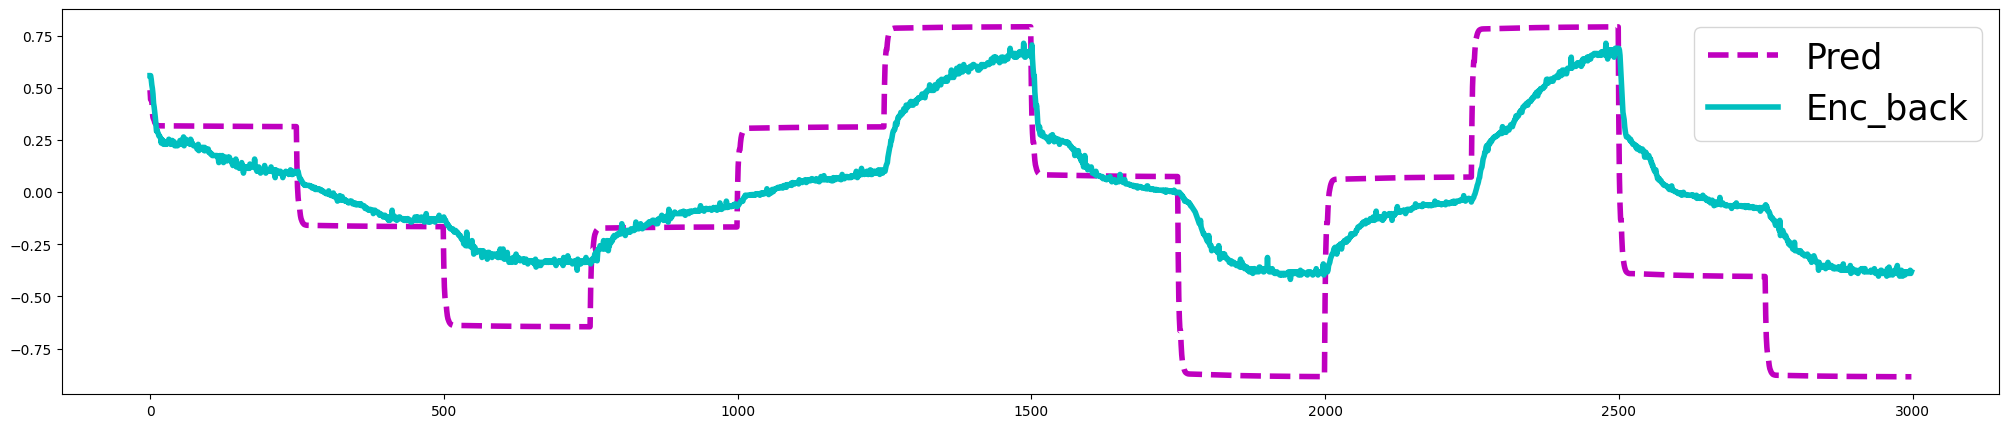

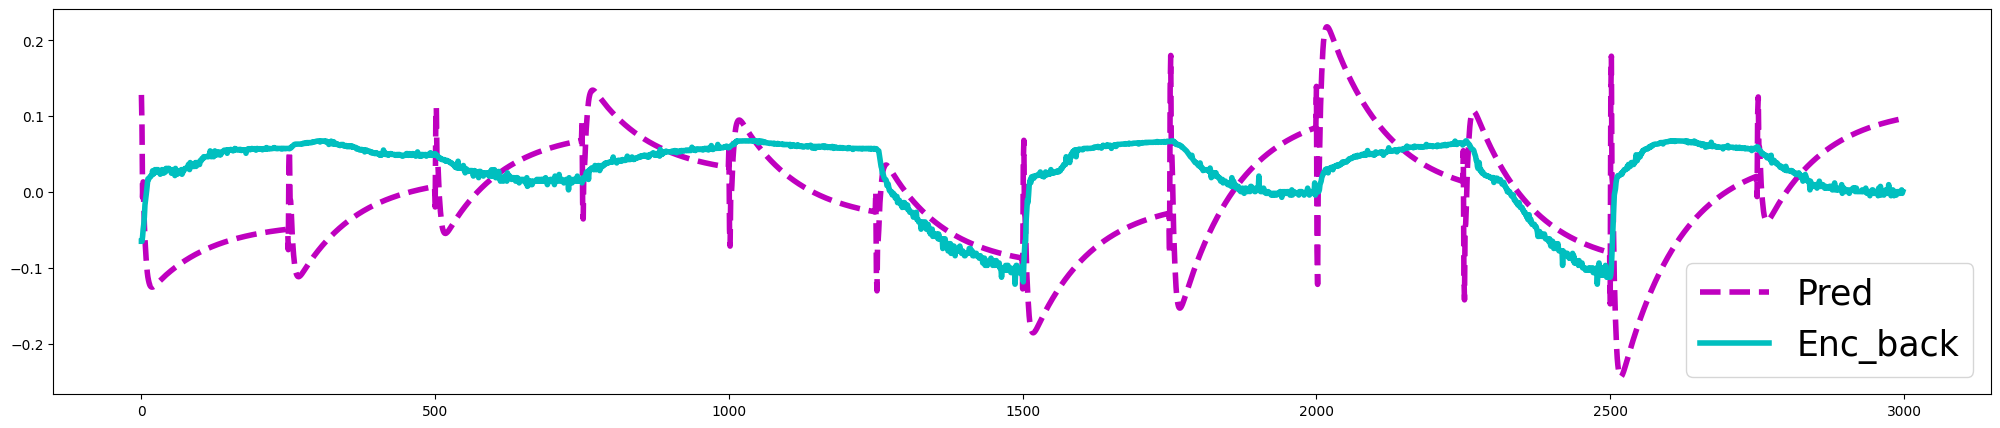

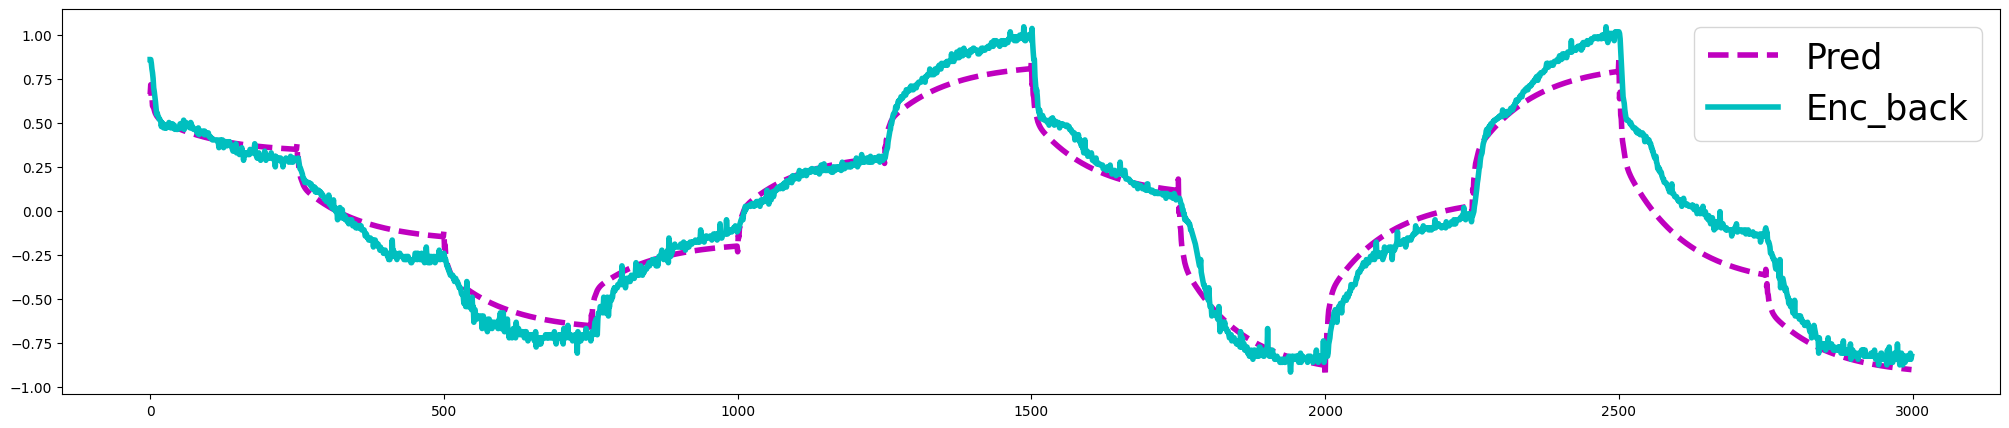

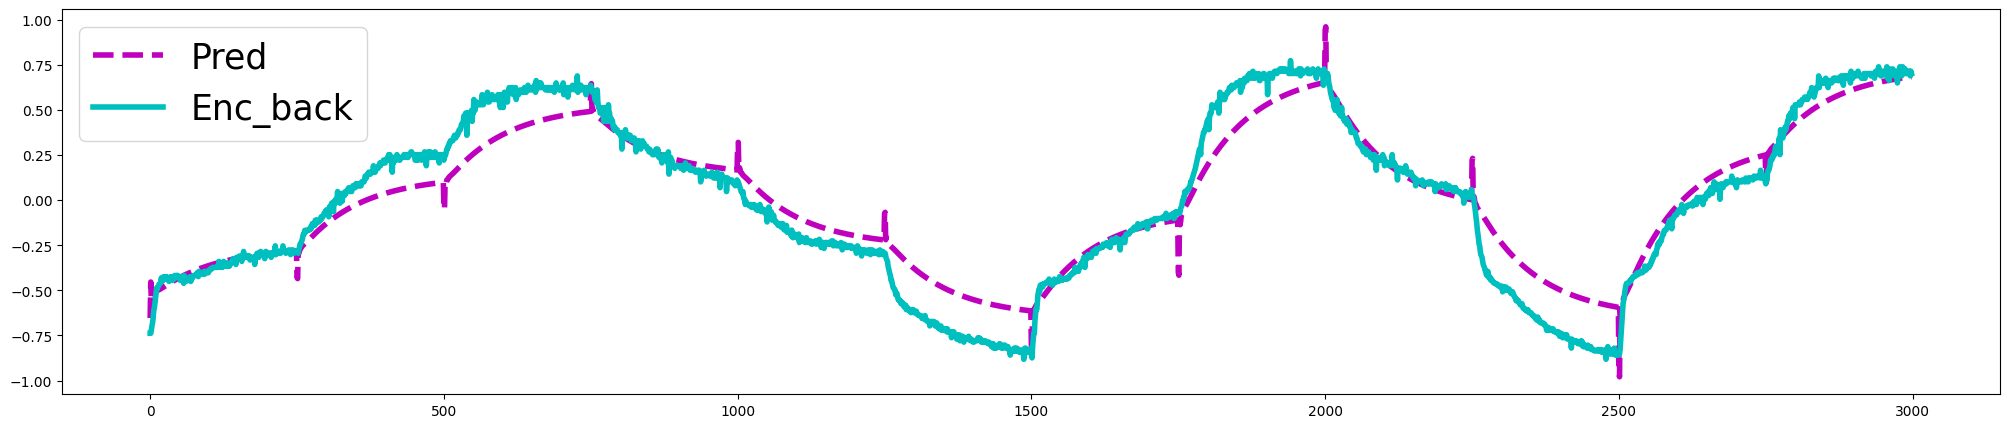

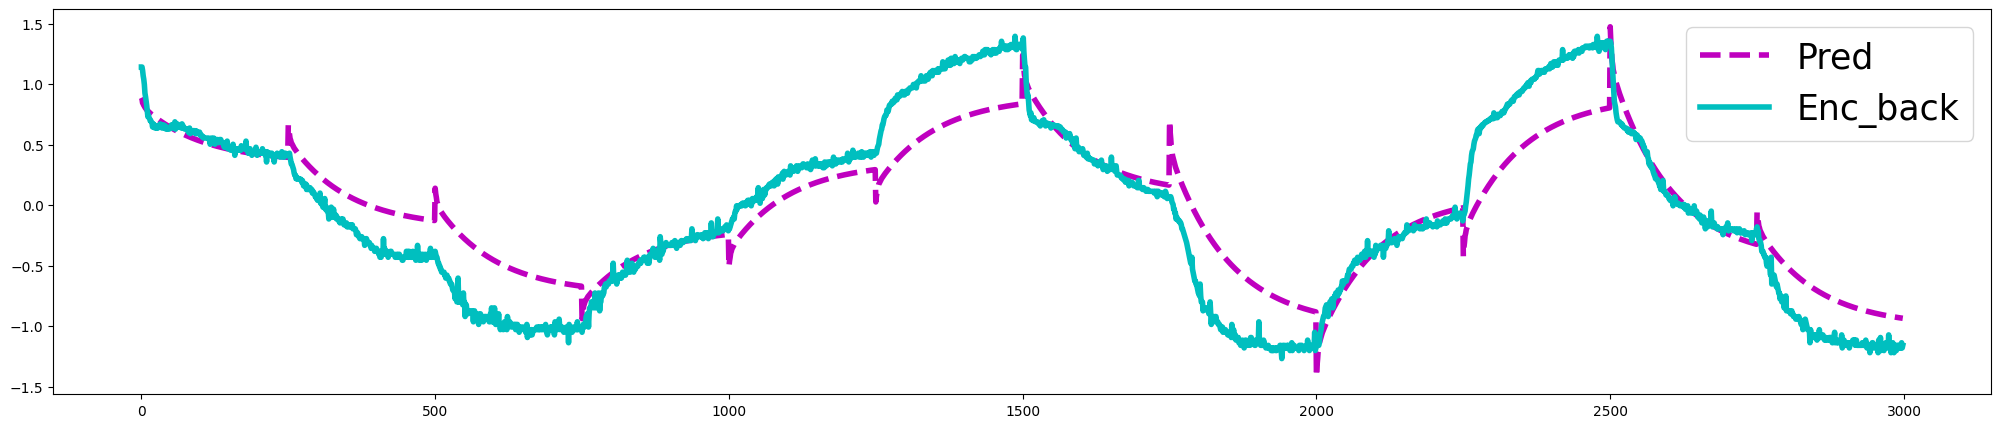

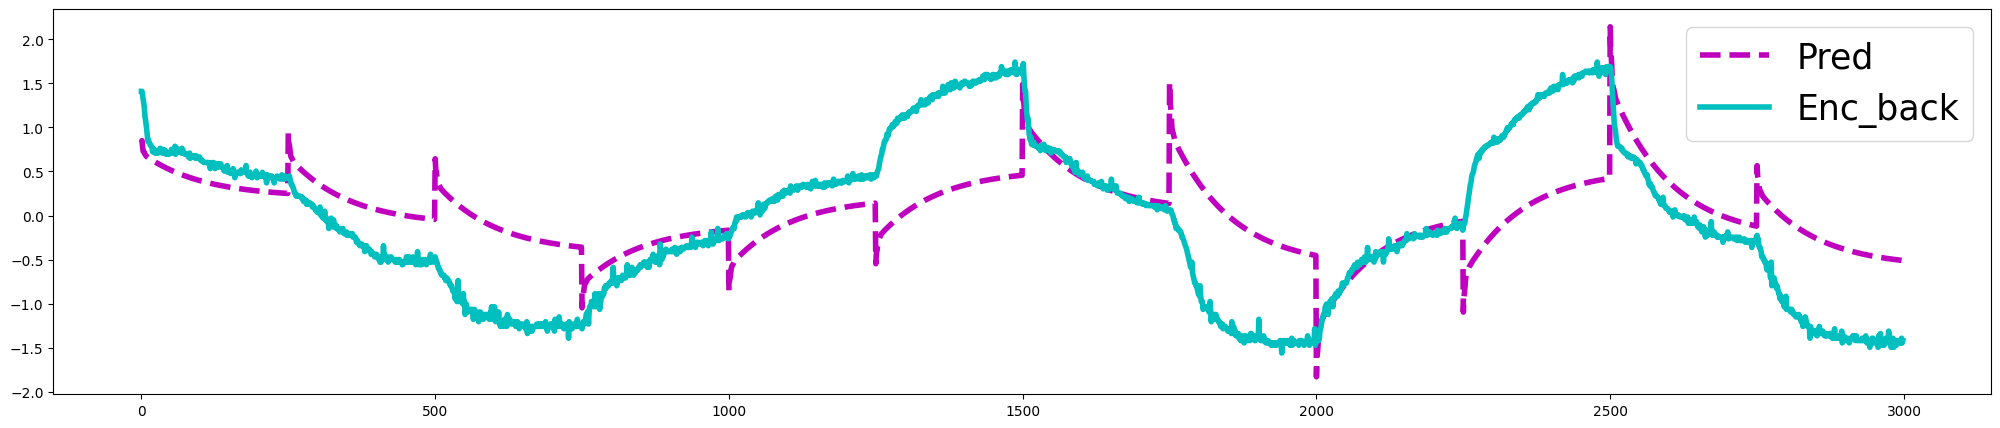

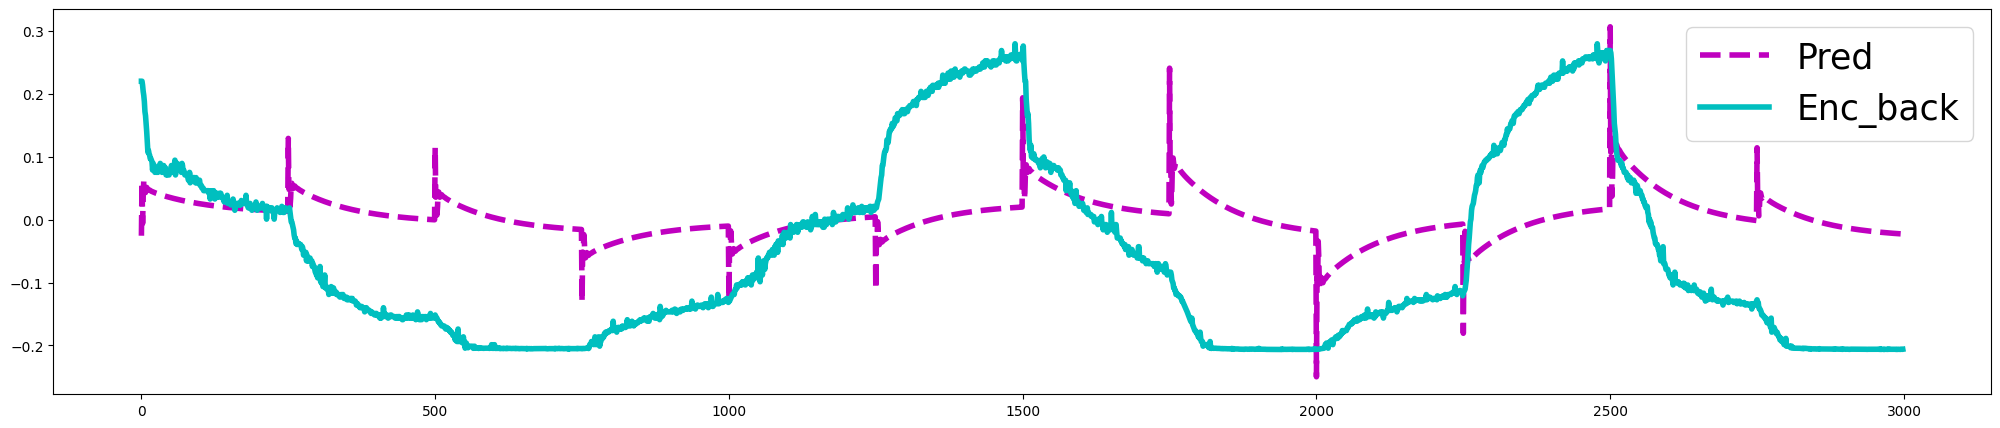

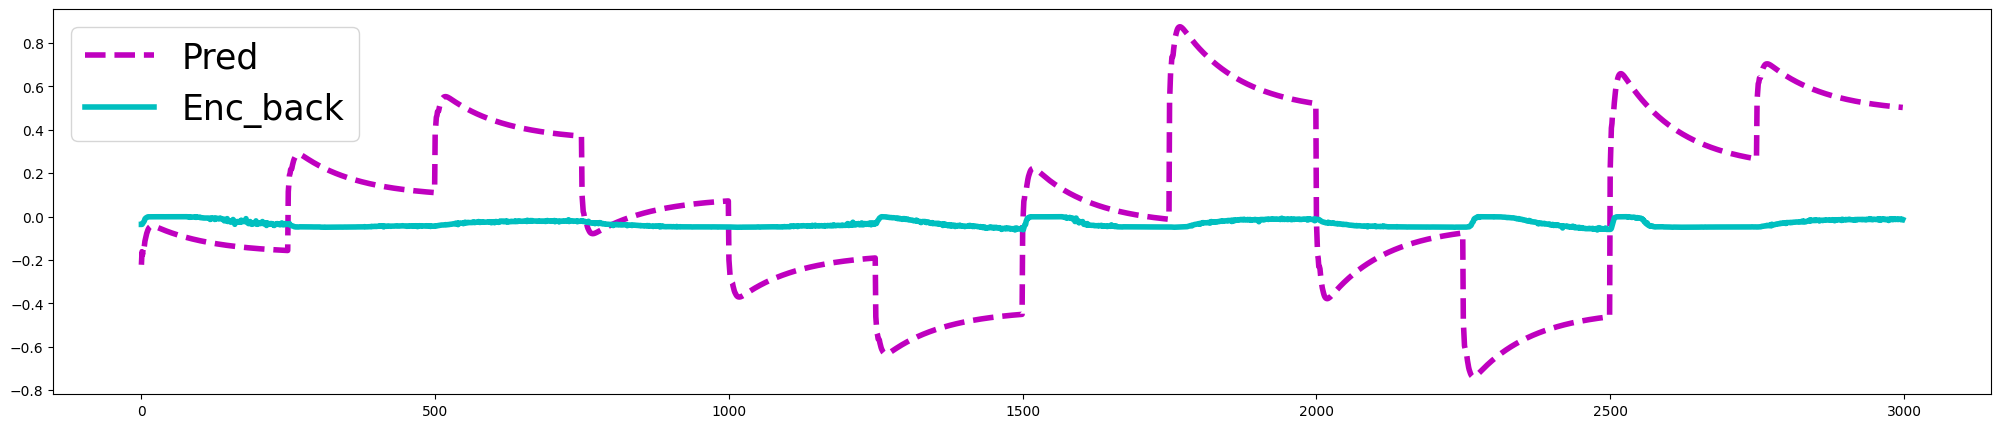

In [ ]:
error = 0
for i in range(nx_koopman):
    # plot lifted space traj, pred_x and x_enc for comparison
    plt.figure(figsize=(25, 5))
    plt.plot(pred_x[i, :part], 'm--', linewidth=4.0, label='Pred')
    plt.plot(x_enc['x'][0].detach().numpy()[:, i][:part], 'c', linewidth=4.0, label='Enc_back')
    plt.legend(fontsize=figsize)
    error = error + np.mean((pred_x[i, :part] - x_enc['x'][0].detach().numpy()[:, i][:part]) ** 2)
# print total mse
print(error/nx_koopman)     
# mse = 0.1854 for latent 1, pred 80
# mse = 0.1633 for latent 10, pred 80
# mse = 0.1653 for latent 10, pred 200
print(x_enc['x'][0].detach().numpy()[:, :][0])
print(pred_x[:,0])


In [ ]:
def controllability_test(A, B):
    """
    Test the controllability of a system given state-space matrices A and B.

    Parameters:
    A (ndarray): State matrix of size (n, n)
    B (ndarray): Input matrix of size (n, m)

    Returns:
    bool: True if the system is controllable, False otherwise.
    """
    n = A.shape[0]  # Number of states
    controllability_matrix = B
    
    # Compute [B, AB, A^2B, ..., A^(n-1)B]
    for i in range(1, n):
        controllability_matrix = np.hstack((controllability_matrix, np.linalg.matrix_power(A, i) @ B))
    
    # Check rank of the controllability matrix
    rank = np.linalg.matrix_rank(controllability_matrix)
    return rank == n

is_controllable = controllability_test(A, B)
print(f"System is controllable: {is_controllable}")

def analyze_controllability(A, B):
    n = A.shape[0]
    controllability_matrix = B
    for i in range(1, n):
        controllability_matrix = np.hstack((controllability_matrix, np.linalg.matrix_power(A, i) @ B))
    
    rank = np.linalg.matrix_rank(controllability_matrix)
    return controllability_matrix, rank

C_matrix, rank = analyze_controllability(A, B)
print("Controllability Matrix:")
print(C_matrix)
print(f"Rank: {rank}/{A.shape[0]}")



System is controllable: True
Controllability Matrix:
[[0.016525]]
Rank: 1/1


In [ ]:
# compute Koopman eigenvalues and eigenvectors
if stable:
    eig, eig_vec = torch.linalg.eig(K.effective_W())
else:
    eig, eig_vec = torch.linalg.eig(K.weight)
# Koopman eigenvalues real and imaginary parts
eReal = eig.real.detach().numpy()
eImag = eig.imag.detach().numpy()
# unit circle
t = np.linspace(0.0, 2 * np.pi, 1000)
x_circ = np.cos(t)
y_circ = np.sin(t)

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(A)

# Find the index of the dominant eigenvalue (largest magnitude)
dominant_index = np.argmax(np.abs(eigenvalues))

# Extract the dominant eigenvalue and corresponding eigenvector
dominant_eigenvalue = eigenvalues[dominant_index]
dominant_eigenvector = eigenvectors[:, dominant_index]

print("dominant eigenvalue is at index", dominant_index)
print("\nDominant Eigenvalue:", dominant_eigenvalue)
print("Corresponding Dominant Eigenvector:")
print(dominant_eigenvector)

dominant eigenvalue is at index 0

Dominant Eigenvalue: -0.014705882352941176
Corresponding Dominant Eigenvector:
[1.]


In [ ]:
A[:,0]

array([-0.01470588])

Text(0.5, 0.98, 'Koopman operator eigenvalues')

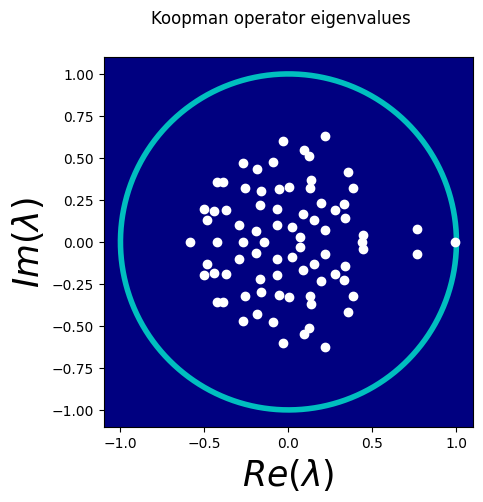

In [ ]:
# plot Koopman eigenvalues
fig1, ax1 = plt.subplots()
ax1.plot(x_circ, y_circ, 'c', linewidth=4)
ax1.plot(eReal, eImag, 'wo')
ax1.set_aspect('equal', 'box')
ax1.set_facecolor("navy")
ax1.set_xlabel("$Re(\lambda)$", fontsize=figsize)
ax1.set_ylabel("$Im(\lambda)$", fontsize=figsize)
fig1.suptitle('Koopman operator eigenvalues')


In [ ]:
print("features.shape:", features.shape)
print("f_y in_features:", f_y.linear[0].in_features)
print("f_y out_features:", f_y.linear[0].out_features)

NameError: name 'features' is not defined

In [ ]:
# compute Koopman state eigenvectors
y_min = 1.1*test_data['Y'].min()
y_max = 1.1*test_data['Y'].max()
y1 = torch.linspace(y_min, y_max, 1000)
y2 = torch.linspace(y_min, y_max, 1000)
yy1, yy2 = torch.meshgrid(y1, y1)
plot_yy1 = yy1.detach().numpy()
plot_yy2 = yy2.detach().numpy()

# eigenvectors – použijeme len jednu súradnicu, aby mal vstup rozmer 1
features = yy1.reshape(-1, 1)          # [1_000_000, 1] zodpovedá in_features=1
latent = f_y(features)                 # [1_000_000, nx_koopman]
latent = latent.view(1000, 1000, -1)   # späť na mriežku [1000, 1000, nx_koopman]

phi = torch.matmul(latent, abs(eig_vec))
# select first 6 eigenvectors
phi_1 = phi.detach().numpy()[:,:,0]
phi_2 = phi.detach().numpy()[:,:,1]
phi_3 = phi.detach().numpy()[:,:,2]
phi_4 = phi.detach().numpy()[:,:,3]
phi_5 = phi.detach().numpy()[:,:,4]
phi_6 = phi.detach().numpy()[:,:,6]

Text(0.5, 0.98, 'first six eigenfunctions')

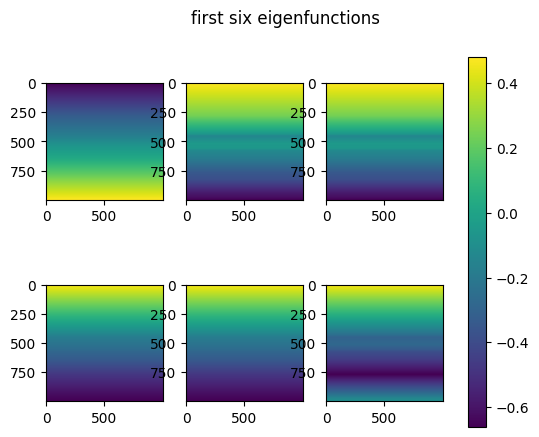

In [ ]:
# plot eigenvectors
fig2, axs = plt.subplots(2, 3)
im1 = axs[0,0].imshow(phi_1)
im2 = axs[0,1].imshow(phi_2)
im3 = axs[0,2].imshow(phi_3)
im4 = axs[1,0].imshow(phi_4)
im5 = axs[1,1].imshow(phi_5)
im6 = axs[1,2].imshow(phi_6)
fig2.colorbar(im1, ax=axs)
fig2.suptitle('first six eigenfunctions')

# Optimal Control


In [ ]:
import sys
sys.path.append('../functions')

import numpy as np
from scipy.linalg import expm
import dense
import cvxpy as cp
import matplotlib.pyplot as plt

In [ ]:
def get_x(y):
    x = problem.nodes[0]({"Y0": torch.from_numpy(y).float()})
    return x["x"].detach().numpy().reshape(1,-1).T

def get_y(x):
    y = problem.nodes[4]({"x": torch.from_numpy(x.T).float()})
    return y["yhat"][0].detach().numpy().reshape(1,-1).T

def get_vector_y(x):
    y = problem.nodes[4]({"x": torch.from_numpy(x.T).float()})
    return y["yhat"].detach().numpy().reshape(1,-1).T

In [ ]:
x0 = get_x(np.array(([[1.0]])))
x_ = x0
for i in range(100):
    y = get_y(x_)
    x_ = get_x(y)

print(sum(x0-x_)**2)

# 1 --> 6.1389
# 10 --> 1.4665
# 100 ---> 0.00010013s

[0.06221709]


In [ ]:
#Qx[1,1] = 1
Qx = np.eye(nx_koopman)
Qu = np.eye(nu)*0.000001

sim_len = 400
N = 40

umax = scalerU.transform(np.array([[100]]))
umin = scalerU.transform(np.array([[20]]))

x = np.zeros((nx_koopman, sim_len+1))
u = np.zeros((nu, sim_len+1))
y = np.zeros((ny, sim_len))
#x0 = get_x(np.array([[1]]))
x_in_0 = get_x(np.array([[0]]))
# x_ = x0
# for i in range(1000):
#     x_ = A@x_ + B@scalerU.transform(np.array([[50]]))
# x_in_0 = x_
# x_ = x0[:,0]
# print(sum(x_))
# for i in range(5000):
#     x_ = A@x_ + B@scalerU.transform(np.array([[50]]))[:,0]
# print(sum(x_))

# x0 = x_.reshape(-1,1)

x0 = get_x(np.array([[1.0]]))

x[:,0] = x0[:,0]
#x0 = x0 - x_in_0

In [ ]:
x0.shape

(20, 1)

In [ ]:
import functions.dense as dense

print("A:", A.shape, "B:", B.shape)
print("Qx:", Qx.shape, "Qu:", Qu.shape, "N:", N)

Psi_u = dense.create_Psi_u(A, B, N)
Wx = dense.create_weighting(Qx, N+1)
Wu = dense.create_weighting(Qu, N)

print("Psi_u:", Psi_u.shape)
print("Wx:", Wx.shape)
print("Wu:", Wu.shape)

ModuleNotFoundError: No module named 'dense'

In [ ]:
start = tim.time()

for i in range(sim_len):
    Q = dense.quad_form_sr(A, B, Qx, Qu, N)
    c = dense.lin_form_sr(A, B, Qx, N, x0)

    F = dense.constraint_matrix_sr_nox(N)
    g = dense.upper_bound_sr_nox(N, umax, umin)

    U = cp.Variable((N, nu))

    objective = cp.Minimize(cp.quad_form(U, Q) + c @ U)
    constraints = [F @ U <= g]

    problem_mpc = cp.Problem(objective, constraints)
    problem_mpc.solve()

    u[:, i] = U.value[0, :].reshape(-1, 1)

    # latent propagation
    x[:, i+1] = A @ x[:, i] + B @ u[:, i]

    # decode latent state to scaled output
    y[:, i] = get_y(x[:, i+1])[:, 0]

    # re-encode decoded output
    x0 = get_x(y[:, i].reshape(1, -1))[:, 0]

end = tim.time()
print(f"Elapsed time MPC: {end-start:.2f} sec")

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 410 is different from 41)

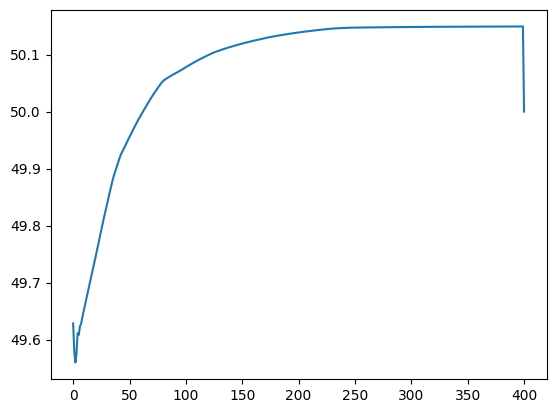

In [ ]:
u_desc = scalerU.inverse_transform(u[:, :sim_len].T)
plt.figure()
plt.plot(u_desc)
plt.title("Input in physical units")
plt.grid()
plt.show()

y_desc = scaler.inverse_transform(y.T)
plt.figure()
plt.plot(y_desc)
plt.title("Output in physical units")
plt.grid()
plt.show()

In [ ]:
y = get_vector_y(x)


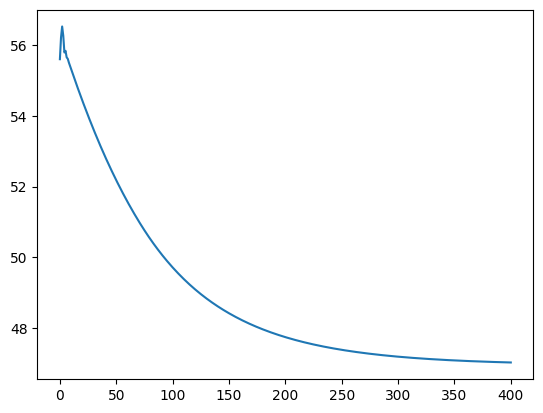

In [ ]:
y_desc = scaler.inverse_transform(y)
plt.plot(y_desc)

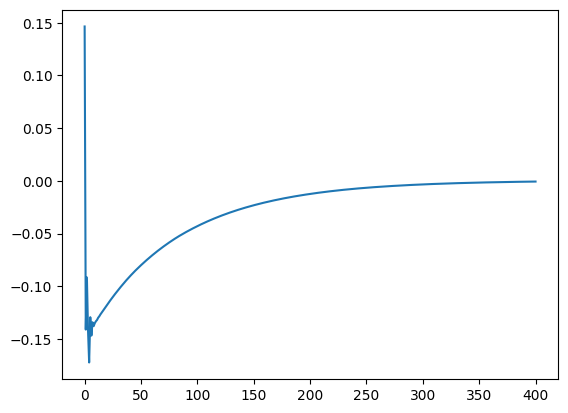

In [ ]:
plt.plot(x[0,:])

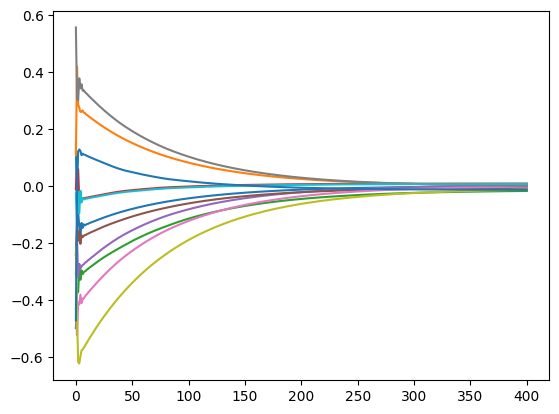

In [ ]:
for i in range(nx_koopman):
    plt.plot(x[i,:])

In [ ]:
x[0,0]-x_in_0[0]

array([0.14550793], dtype=float32)

# To reference

In [ ]:
u = scalerU.transform(np.array([[30]]))[:,0]
x = get_x(scaler.transform(np.array([[36.56215]])))[:,0]
print(x)
for i in range(1000):
    x = A@x + B@u
print(x)
print(scaler.inverse_transform(get_y(x)))
print(get_x(get_y(x))[:,0])
x_store = x

[-0.16118781 -0.0840294   0.4370221  -0.22413442  0.3997547   0.36496225
  0.49624982 -0.64546484  0.11036161  0.12251185  0.56564724]
[-0.06932876 -0.06710585  1.90409051 -1.21752271 -0.49757508  0.57557333
 -0.1632056   0.24821646  1.03307008 -1.00964686  1.84887348]
[[35.14972]]
[-0.17990905 -0.10089081  0.48805577 -0.26355195  0.45397258  0.4146208
  0.56912816 -0.73439306  0.12955707  0.14614281  0.64357615]


In [ ]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

# Find the indices of the dominant eigenvalues
dominant_indices = np.argsort(-np.abs(eigenvalues))  # Sort by absolute value in descending order
dominant_eigenvalues = eigenvalues[dominant_indices]

# Output results
print("Eigenvalues:", eigenvalues)
print("Dominant Eigenvalues:", dominant_eigenvalues)
print("Indices of Dominant Eigenvalues:", dominant_indices)


Eigenvalues: [ 0.9882058 +0.j         -0.4954663 +0.24588355j -0.4954663 -0.24588355j
  0.23539482+0.34724897j  0.23539482-0.34724897j  0.2938968 +0.10638515j
  0.2938968 -0.10638515j  0.0046915 +0.28640994j  0.0046915 -0.28640994j
 -0.33488926+0.j         -0.17142197+0.j        ]
Dominant Eigenvalues: [ 0.9882058 +0.j         -0.4954663 +0.24588355j -0.4954663 -0.24588355j
  0.23539482+0.34724897j  0.23539482-0.34724897j -0.33488926+0.j
  0.2938968 +0.10638515j  0.2938968 -0.10638515j  0.0046915 +0.28640994j
  0.0046915 -0.28640994j -0.17142197+0.j        ]
Indices of Dominant Eigenvalues: [ 0  1  2  3  4  9  5  6  7  8 10]


In [ ]:
Qx = np.zeros((nx_koopman,nx_koopman))
for i in range(nx_koopman):
    if dominant_indices[i] <= 5:
        Qx[i,i] = 10
    else:
        Qx[i,i] = 1
x_for = get_x(np.array([[0]]))
#Qx = np.diag( 1/(x_for[:,0]**2) )
#Qx = np.eye(nx_koopman)
Qu = np.eye(nu)*0.1

sim_len = 400
N = 40

umax = scalerU.transform(np.array([[100]]))
umin = scalerU.transform(np.array([[20]]))

x = np.zeros((nx_koopman, sim_len+1))
u = np.zeros((nu, sim_len+1))
y = np.zeros((ny, sim_len))

x_in_0 = get_x(np.array([[0]]))


x0 = get_x(scaler.transform(np.array([[60]])))
x_ref = np.array([x_store]).T #get_x(scaler.transform(np.array([[30]])))
u_prev = scalerU.transform(np.array([[20]]))

x[:,0] = x0[:,0]

In [ ]:
start = tim.time()
for i in range(sim_len):
    Q = dense.quad_form_cr(A, B, Qx, Qu, N)
    c = dense.lin_form_cr(A, B, Qx, Qu, N, x0, x_ref, u_prev)
    F = dense.constraint_matrix_sr_nox(N)
    g = dense.upper_bound_sr_nox(N,umax, umin)
    
    U = cp.Variable((N, nu))
    
    objective = cp.Minimize(cp.quad_form(U, Q) + c @ U)
    constraints = [F @ U <= g]
    
    problem_mpc = cp.Problem(objective, constraints)
    problem_mpc.solve()
    
    print(problem_mpc.objective.value)
    #print(U.value)
    u[:, i] = U.value[0, :].reshape(-1, 1) #scalerU.transform(np.array([[75]]))#U.value[0, :].reshape(-1, 1)
    
    # propagation in time
    x[:, i+1] = A @ x[:, i] + B @ u[:, i]
    y[:, i] = get_y(x[:, i+1])
    
        
    x0 = get_x(y[:,i])[:,0] #x[:, i+1] #- x_in_0[:,0] #get_x(y[:,i])[:,0]
    u_prev = u[:,i]
    #print(sum(x0))
    print(i)
end = tim.time()
print(f"Elapsed time MPC: {end-start:.2f} sec")

-2061.220000570399
0
-2068.9066404897485
1
-2064.066337867492
2
-2065.689213171346
3
-2070.242823310708
4
-2072.654051229699
5
-2073.725197191481
6
-2075.1794494350042
7
-2076.4273725203234
8
-2077.8577071055443
9
-2079.226722510133
10
-2080.512631116947
11
-2081.798752834863
12
-2083.107107478137
13
-2084.348902762308
14
-2085.5550824929487
15
-2086.809734978313
16
-2088.053401372563
17
-2089.2935926755645
18
-2090.5287922098123
19
-2091.7950708641592
20
-2093.0732873548113
21
-2094.342751868471
22
-2095.609507213776
23
-2096.870424158513
24
-2098.1248497944575
25
-2099.335978678864
26
-2100.459212474325
27
-2101.577903964717
28
-2102.588415461354
29
-2103.5228265163023
30
-2104.527041814334
31
-2105.520731014199
32
-2106.5021741839328
33
-2107.4676242030055
34
-2108.4226844059754
35
-2109.367777091135
36
-2110.3090598662156
37
-2111.2422267050943
38
-2112.1505758359062
39
-2113.0689091615445
40
-2113.97673253676
41
-2114.8731414070553
42
-2115.7582546228814
43
-2116.632196474323
44
-

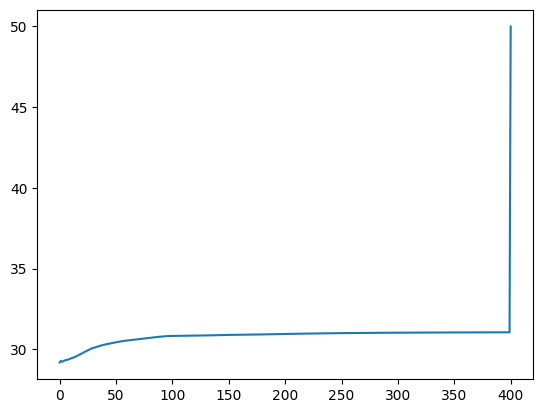

In [ ]:
plt.plot(scalerU.inverse_transform(u.T))

In [ ]:
y = get_vector_y(x)


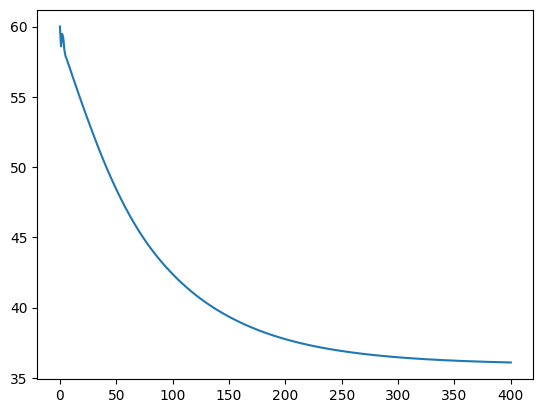

In [ ]:
y_desc = scaler.inverse_transform(y)
plt.plot(y_desc)

In [ ]:
y_desc[-1]

array([36.100193], dtype=float32)

In [ ]:
scaler.inverse_transform(get_y(x_ref))

array([[35.14972]], dtype=float32)

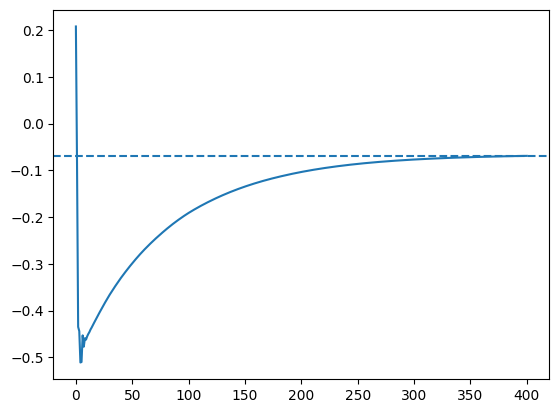

In [ ]:
plt.plot(x[0,:])
plt.axhline(y = x_ref[0], linestyle = '--') 

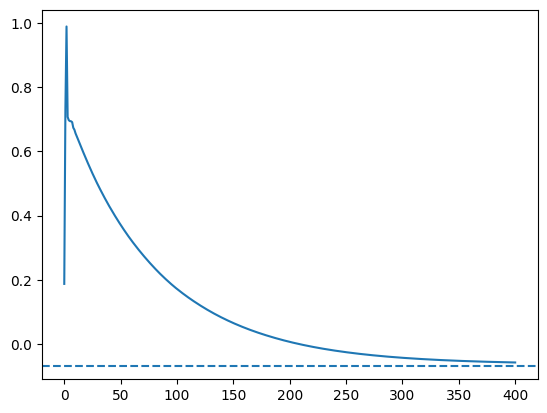

In [ ]:
plt.plot(x[1,:])
plt.axhline(y = x_ref[1], linestyle = '--') 

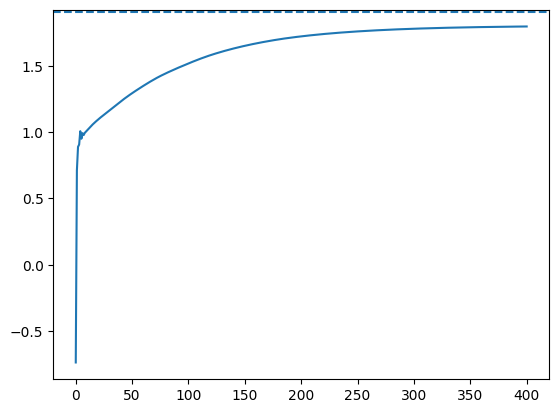

In [ ]:
plt.plot(x[2,:])
plt.axhline(y = x_ref[2], linestyle = '--') 

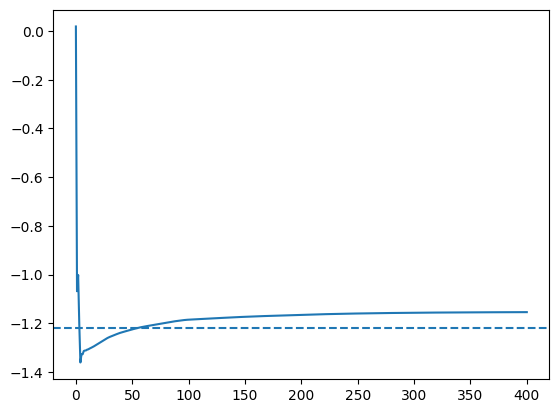

In [ ]:
plt.plot(x[3,:])
plt.axhline(y = x_ref[3], linestyle = '--') 

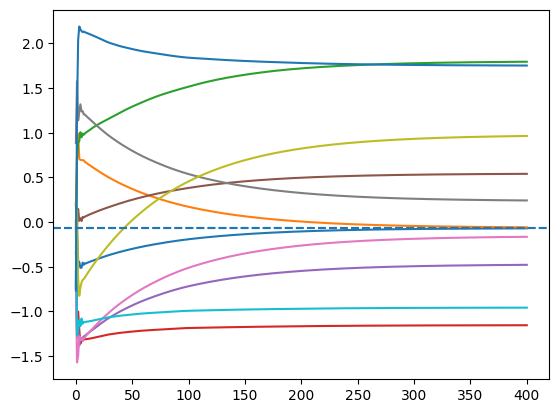

In [ ]:
for i in range(nx_koopman):
    plt.plot(x[i,:])
    
plt.axhline(y = x_ref[1], linestyle = '--') 
plt.axhline(y = x_ref[0], linestyle = '--') 
    